In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import Counter
import collections
import random
from tqdm import tqdm
from scipy.special import expit

## Utils


In [2]:
# --- 1. PRE-COMPUTATION HELPERS ---
def get_valid_formations():
    """
    Pre-calculates all valid formations (sum to 10 + 1 GK)
    so we don't recalculate them inside the loop.
    """
    valid = []
    def_sizes = [i for i in range(3,6)]
    mid_sizes = [i for i in range(2,5)]
    fwd_sizes = [i for i in range(1,4)]

    for d in def_sizes:
        for m in mid_sizes:
            for f in fwd_sizes:
                if d + m + f == 10:
                    valid.append(np.array([d, m, f]))
    return valid

def calibrate_p_vectors(p_vectors, costs, budget, formation_avg=[1, 4, 4, 2]):
    """
    Adjusts probabilities so the Expected Cost of a team matches the Budget range.
    Handles both Over-Budget (too expensive) and Under-Budget (too cheap) scenarios.
    """
    positions = ['GK', 'DEF', 'MID', 'FWD']
    # formation_avg = formation_avg.tolist()
    # formation_avg = formation_avg.insert(0,1)
    formation_avg = np.insert(formation_avg, 0,1)

    # NEW: Hard limit on the exponent to prevent numerical instability and over-skewing
    MAX_ABS_EXPONENT = 6.0

    # Helper to calculate the current expected cost of a team
    def get_expected_cost(current_p_vectors):
        total_expected_cost = 0
        for i, pos in enumerate(positions):
            # Expected cost = Sum(Probability * Cost) * Number of players in that pos
            pos_expected_val = np.sum(current_p_vectors[pos] * costs[i])
            total_expected_cost += pos_expected_val * formation_avg[i]
        return total_expected_cost

    current_cost = get_expected_cost(p_vectors)
    print(f"📊 Initial Expected Team Cost: {current_cost:.2f} (Budget: {budget})")

    # Define the "Sweet Spot" for acceptance
    # Teams must be > budget_lower_bound (usually 0.9) and < budget (1.0)
    # We target the middle of this range to maximize acceptance.
    TARGET_MIN = budget * 0.94
    TARGET_MAX = budget * 1.01

    if TARGET_MIN <= current_cost <= TARGET_MAX:
        print("✅ Probabilities are already well-calibrated.")
        return p_vectors

    print(f"⚠️ Cost {current_cost} out of optimal range ({TARGET_MIN:.1f}-{TARGET_MAX:.1f}). Calibrating...")

    exponent = 0.0
    # Direction:
    # If cost is too high (e.g. 105), we need positive exponent to punish expensive (1/cost^x)
    # If cost is too low (e.g. 73), we need negative exponent to reward expensive (cost^x)
    direction = 1.0 if current_cost > TARGET_MAX else -1.0
    step_size = 0.1 * direction

    # # --- ADAPTIVE STEP IMPROVEMENT ---
    # TARGET_MID = (TARGET_MIN + TARGET_MAX) / 2.0

    # # Calculate initial step based on relative error from the midpoint
    # relative_error = (current_cost - TARGET_MID) / TARGET_MID

    # # Use a large initial step, clamped between 0.05 and MAX_ABS_EXPONENT
    # initial_step = np.clip(abs(relative_error) * 0.5, 0.05, MAX_ABS_EXPONENT)

    # # Determine direction: 1.0 if too expensive, -1.0 if too cheap
    # direction = 1.0 if current_cost > TARGET_MID else -1.0

    # # Start the exponent at the initial calculated step, moving in the correct direction
    # exponent = initial_step * direction

    # # Use a smaller step size for fine-tuning after the first guess
    # fine_tune_step = 0.05 * direction

    for attempt in range(50):
        exponent += step_size

        # if attempt > 0:
        #     exponent += fine_tune_step

        #  # Check against the new maximum exponent limit
        # if abs(exponent) > MAX_ABS_EXPONENT + abs(fine_tune_step):
        #     print(f"❌ Aborted! Reached max stable exponent of {MAX_ABS_EXPONENT:.2f}. Using last stable distribution.")
        #     break

        new_p_vectors = {}

        for i, pos in enumerate(positions):
            # Safety clamp for costs to prevent math errors
            safe_costs = np.maximum(costs[i], 0.5)

            # Calibration Formula:
            # New_Weight = Old_Weight * (Cost ^ -exponent)
            # Exponent > 0: (1 / Cost^x) -> Reduces weight of expensive players
            # Exponent < 0: (Cost^x)     -> Increases weight of expensive players
            weights = p_vectors[pos] * np.power(safe_costs, -exponent)

            # Normalize
            w_sum = np.sum(weights)
            if w_sum > 0:
                weights /= w_sum
            else:
                weights = np.ones_like(weights) / len(weights)

            new_p_vectors[pos] = weights

        new_cost = get_expected_cost(new_p_vectors)

        # Check if we landed in the zone
        if TARGET_MIN <= new_cost <= TARGET_MAX:
            print(f"✅ Calibrated! Factor: {exponent:.2f} | New Expected Cost: {new_cost:.2f}")
            return new_p_vectors

        # Check if we overshot the target (crossed from low to high or high to low)
        if direction > 0 and new_cost < TARGET_MIN:
             print(f"⚠️ Calibration settling (overshot slightly). Cost: {new_cost:.2f}")
             return new_p_vectors
        if direction < 0 and new_cost > TARGET_MAX:
             print(f"⚠️ Calibration settling (overshot slightly). Cost: {new_cost:.2f}")
             return new_p_vectors

    print(f"⚠️ Max calibration attempts reached. Final Cost: {new_cost:.2f}")
    return new_p_vectors

def calculate_p_vectors(feature_matrices, beta_estimates):
    """
    Calculates p_vectors using the Mean-Field approximation for Alphas.
    """
    print("📊 Calculating raw p_vectors from Beta estimates...")
    p_vectors = {}
    positions = ['GK', 'DEF', 'MID', 'FWD']

    is_dict = isinstance(feature_matrices, dict)

    for i, pos in enumerate(positions):
        if is_dict:
            X = feature_matrices[pos]
        else:
            X = feature_matrices[i]

        beta = beta_estimates[pos]

        # 1. Calculate Alphas: Mean of the exponentiated predictions
        alpha = np.exp(X @ beta.T).mean(axis=1)

        # 2. Sample Dirichlet once to get the base distribution
        try:
            p_vectors[pos] = np.random.dirichlet(alpha)
        except ValueError:
            # Fallback if alphas are too huge/small causing numerical issues
            p_vectors[pos] = alpha / alpha.sum()

    return p_vectors

def is_feasible_fast(portfolio_indices, flat_costs, flat_team_ints, budget, budget_lb):
    """
    Optimized constraint checker.
    """
    # 1. Budget Check (Vectorized sum)
    total_cost = np.sum(flat_costs[portfolio_indices])
    # print(portfolio_indices)
    print('costs: ', flat_costs[portfolio_indices], 'total_cost: ', total_cost)

    if total_cost > budget or total_cost < budget_lb:
        return False

    # 2. Team Count Check (Max 3 players per team)
    selected_teams = flat_team_ints[portfolio_indices]
    team_counts = np.bincount(selected_teams, minlength=50)

    if np.any(team_counts > 3):
        return False

    return True

def generate_batch_optimized(
    n_samples,
    flat_costs,
    flat_team_ints,
    pos_offsets,
    pos_counts,
    xp_preds_dict,
    pos_teams_dict,
    q,
    budget,
    budget_lb,
    xp_threshold ,
    beta_estimates, feature_matrices, costs,
    p_vectors=None,
):

    # Inside generate_batch_optimized, at the very top
    if np.random.rand() < 0.001: # Print only occasionally
        print(f"DEBUG WORKER: Budget={budget}, LB={budget_lb}, Cost_Sample={flat_costs[0]}")

    """
    Generates a BATCH of teams locally.
    """

    # Helper for numerical stability check before np.random.choice
    def safe_normalize_p_vector(p_vec):
        # 1. Ensure all values are non-negative
        p_vec = np.maximum(p_vec, 0)
        # 2. Check sum and normalize
        p_sum = np.sum(p_vec)
        if p_sum == 0:
            # Fallback to uniform distribution if sum is zero
            return np.ones_like(p_vec) / len(p_vec)
        return p_vec / p_sum

    for _ in range(n_samples):
        # --- Formation ---
        VALID_FORMATIONS = get_valid_formations()
        valid_batch_indices = []
        form_idx = np.random.randint(len(VALID_FORMATIONS))
        formation = VALID_FORMATIONS[form_idx]


        # --- 1. PROBABILITY CALCULATION & CALIBRATION ---
        if p_vectors is None:
            print('Starting to Calibrate: ............ probs')
            # 1. Calculate Base Probabilities (Statistical Model)
            p_vectors = calculate_p_vectors(feature_matrices, beta_estimates)

            # 2. Calibrate for Budget (Feasibility Optimization)
            # We pass the cost arrays for each position [cost_gk, cost_def, cost_mid, cost_fwd]
            p_vectors = calibrate_p_vectors(p_vectors, costs, budget, formation)


            # print(p_vectors)

        # --- SELECTION ---
        # sel_gk = np.random.choice(pos_counts['GK'], 1, replace=False, p=p_vectors['GK'])
        # sel_def = np.random.choice(pos_counts['DEF'], formation[0], replace=False, p=p_vectors['DEF'])
        # sel_mid = np.random.choice(pos_counts['MID'], formation[1], replace=False, p=p_vectors['MID'])
        # sel_fwd = np.random.choice(pos_counts['FWD'], formation[2], replace=False, p=p_vectors['FWD'])

         # --- Random Player Selection using Calibrated Probabilities (with stability guard) ---
        try:
            p_gk = safe_normalize_p_vector(p_vectors['GK'])
            sel_gk = np.random.choice(pos_counts['GK'], 1, replace=False, p=p_gk)

            p_def = safe_normalize_p_vector(p_vectors['DEF'])
            sel_def = np.random.choice(pos_counts['DEF'], formation[0], replace=False, p=p_def)

            # p_mid = safe_normalize_p_vector(p_vectors['MID'])
            # sel_mid = np.random.choice(pos_counts['MID'], formation[1], replace=False, p=p_mid)

            # p_fwd = safe_normalize_p_vector(p_vectors['FWD'])
            # sel_fwd = np.random.choice(pos_counts['FWD'], formation[2], replace=False, p=p_fwd)

            # --- FWD STAR PLAYER HEURISTIC ---
            p_fwd = safe_normalize_p_vector(p_vectors['FWD'])
            fwd_slots = formation[2]

            # print('[[[[[[[[[[[[[[[[[[[[[[[',prices,  flat_costs)
            print(formation)

            costs_fwd = prices[3]
            # Identify high-cost FWD players (Top 10% cost)
            fwd_cost_threshold = np.percentile(costs_fwd, 90)

            # Filter for star players who also have high probability (value)
            star_fwd_indices = np.where(
                (p_fwd > p_fwd.mean()) & (costs_fwd >= fwd_cost_threshold)
            )[0]

            star_fwd = np.array([], dtype=int)
            remaining_fwd_slots = fwd_slots

            if fwd_slots > 0 and len(star_fwd_indices) > 0:
                # Force selection of one FWD star player
                star_fwd = np.random.choice(star_fwd_indices, 1, replace=False)
                remaining_fwd_slots -= 1

                # Exclude the selected star from the remaining pool
                remaining_pool = np.setdiff1d(np.arange(pos_counts['FWD']), star_fwd)
            else:
                remaining_pool = np.arange(pos_counts['FWD'])

            # Sample remaining FWDs from the non-star pool using calibrated probs
            if remaining_fwd_slots > 0 and len(remaining_pool) > 0:
                remaining_p_fwd = safe_normalize_p_vector(p_vectors['FWD'][remaining_pool])
                sel_fwd_rem = np.random.choice(
                    remaining_pool,
                    remaining_fwd_slots,
                    replace=False,
                    p=remaining_p_fwd
                )
                sel_fwd = np.concatenate([star_fwd, sel_fwd_rem])
            else:
                sel_fwd = star_fwd

            # --- MID STAR PLAYER HEURISTIC ---
            p_mid = safe_normalize_p_vector(p_vectors['MID'])
            mid_slots = formation[1]
            costs_mid = prices[2]
            mid_cost_threshold = np.percentile(costs_mid, 90)
            star_mid_indices = np.where(
                (p_mid > p_mid.mean()) & (costs_mid >= mid_cost_threshold)
            )[0]

            star_mid = np.array([], dtype=int)
            remaining_mid_slots = mid_slots

            if mid_slots > 0 and len(star_mid_indices) > 0:
                # Force selection of one MID star player
                star_mid = np.random.choice(star_mid_indices, 1, replace=False)
                remaining_mid_slots -= 1

                # Exclude the selected star from the remaining pool
                remaining_pool = np.setdiff1d(np.arange(pos_counts['MID']), star_mid)
            else:
                remaining_pool = np.arange(pos_counts['MID'])

            # Sample remaining MIDs from the non-star pool using calibrated probs
            if remaining_mid_slots > 0 and len(remaining_pool) > 0:
                remaining_p_mid = safe_normalize_p_vector(p_vectors['MID'][remaining_pool])
                sel_mid_rem = np.random.choice(
                    remaining_pool,
                    remaining_mid_slots,
                    replace=False,
                    p=remaining_p_mid
                )
                sel_mid = np.concatenate([star_mid, sel_mid_rem])
            else:
                sel_mid = star_mid

            # Check if selection sizes match formation slots (important if star selection failed, or player pools are too small)
            if len(sel_mid) != mid_slots or len(sel_fwd) != fwd_slots:
                # Fallback to pure probabilistic if heuristic resulted in incorrect counts
                p_mid = safe_normalize_p_vector(p_vectors['MID'])
                sel_mid = np.random.choice(pos_counts['MID'], formation[1], replace=False, p=p_mid)
                p_fwd = safe_normalize_p_vector(p_vectors['FWD'])
                sel_fwd = np.random.choice(pos_counts['FWD'], formation[2], replace=False, p=p_fwd)
        except ValueError as e:
            # If the safe normalization fails (e.g., player count too low for formation slot)
            print(f"Sampling Error: {e}. Skipping sample.")
            continue

        # --- STACKING LOGIC ---
        is_stacker = np.random.binomial(1, q) == 1


        if is_stacker:
            # FWD-MID Stack
            if len(sel_fwd) > 0 and len(sel_mid) > 0:
                fwd_vals = xp_preds_dict['FWD'][sel_fwd]
                best_fwd_local_idx = sel_fwd[np.argmax(fwd_vals)]

                if xp_preds_dict['FWD'][best_fwd_local_idx] >= xp_threshold:
                    anchor_team = pos_teams_dict['FWD'][best_fwd_local_idx]

                    all_mids = np.arange(pos_counts['MID'])
                    team_mask = (pos_teams_dict['MID'] == anchor_team)
                    selected_mask = np.zeros(pos_counts['MID'], dtype=bool)
                    selected_mask[sel_mid] = True

                    avail_mask = team_mask & (~selected_mask)
                    available_indices = all_mids[avail_mask]

                    if len(available_indices) > 0:
                        teammate_probs = p_vectors['MID'][available_indices]
                        prob_sum = np.sum(teammate_probs)
                        if prob_sum > 0:
                            norm_probs = teammate_probs / prob_sum
                            chosen_teammate = np.random.choice(available_indices, size=1, p=norm_probs)[0]
                            mid_vals = xp_preds_dict['MID'][sel_mid]
                            worst_idx_rel = np.argmin(mid_vals)
                            sel_mid[worst_idx_rel] = chosen_teammate

            # DEF-GK Stack
            if len(sel_def) > 0:
                def_vals = xp_preds_dict['DEF'][sel_def]
                best_def_local_idx = sel_def[np.argmax(def_vals)]

                if xp_preds_dict['DEF'][best_def_local_idx] >= xp_threshold:
                    anchor_team = pos_teams_dict['DEF'][best_def_local_idx]

                    all_gks = np.arange(pos_counts['GK'])
                    team_mask = (pos_teams_dict['GK'] == anchor_team)
                    if pos_teams_dict['GK'][sel_gk[0]] != anchor_team:
                         avail_mask = team_mask
                    else:
                         avail_mask = np.zeros(pos_counts['GK'], dtype=bool)

                    available_indices = all_gks[avail_mask]

                    if len(available_indices) > 0:
                        teammate_probs = p_vectors['GK'][available_indices]
                        prob_sum = np.sum(teammate_probs)
                        if prob_sum > 0:
                            norm_probs = teammate_probs / prob_sum
                            chosen_gk = np.random.choice(available_indices, size=1, p=norm_probs)[0]
                            sel_gk[0] = chosen_gk


        # --- GLOBAL INDEX MAPPING ---
        global_gk = sel_gk + pos_offsets['GK']
        global_def = sel_def + pos_offsets['DEF']
        global_mid = sel_mid + pos_offsets['MID']
        global_fwd = sel_fwd + pos_offsets['FWD']

        candidate_indices = np.concatenate([global_gk, global_def, global_mid, global_fwd])
        # print(candidate_indices)
        # --- FEASIBILITY CHECK ---
        if is_feasible_fast(candidate_indices, flat_costs, flat_team_ints, budget, budget_lb):
            print('is_feasible')
            # We store indices directly in the list
            candidate_indices.sort() # Sort for easier uniqueness checking later
            valid_batch_indices.append(candidate_indices)

    return valid_batch_indices

def sample_opponent_portfolios_optimized(
    O, batch_size, beta_estimates, feature_matrices, ids, costs, budget, teams, xp_preds,
    p_vectors=None,
    q=0.35, Blb_ratio=0.9
):
    print(f"\n🚀 Preparing Optimized Data Structures (Batch Mode)...")

    # --- 2. DATA FLATTENING ---
    flat_costs = players_preds['value'].values # np.concatenate(costs)

    total_num_players = len(flat_costs)

    flat_teams_str = np.concatenate(teams)
    unique_teams, flat_team_ints = np.unique(flat_teams_str, return_inverse=True)

    lengths = [len(sub) for sub in ids]
    offsets_arr = np.cumsum([0] + lengths[:-1])

    pos_offsets = {
        'GK': offsets_arr[0], 'DEF': offsets_arr[1],
        'MID': offsets_arr[2], 'FWD': offsets_arr[3]
    }
    pos_counts = {
        'GK': lengths[0], 'DEF': lengths[1],
        'MID': lengths[2], 'FWD': lengths[3]
    }
    xp_preds_dict = {
        'GK': np.array(xp_preds[0]), 'DEF': np.array(xp_preds[1]),
        'MID': np.array(xp_preds[2]), 'FWD': np.array(xp_preds[3])
    }
    pos_teams_dict = {
        'GK': np.array(teams[0]), 'DEF': np.array(teams[1]),
        'MID': np.array(teams[2]), 'FWD': np.array(teams[3])
    }

    all_xp = np.concatenate([x for x in xp_preds_dict.values()])
    xp_threshold = np.percentile(all_xp, 75)
    budget_lower_bound = budget * Blb_ratio

    n_cores = mp.cpu_count()
    print(f"⚙️ Using {n_cores} cores. Target: {O} unique portfolios.")

    teams_per_core_call = max(50, batch_size // n_cores)

    # --- 3. GENERATION LOOP ---
    portfolios = set()
    attempts = 0

    while len(portfolios) < O:
        needed = O - len(portfolios)
        # Since calibration is now active, rejection should be low.
        # We can request closer to the actual number needed.
        target_attempts = int(needed * 1.5) + 50

        n_tasks = max(n_cores, target_attempts // teams_per_core_call)
        n_tasks = min(n_tasks, n_cores * 4)

        samples_per_task = max(50, target_attempts // n_tasks)

        results_batches  = generate_batch_optimized(
                samples_per_task,
                flat_costs,
                flat_team_ints,
                pos_offsets,
                pos_counts,
                # p_vectors,
                xp_preds_dict,
                pos_teams_dict,
                q,
                budget,
                budget_lower_bound,
                xp_threshold,
                beta_estimates, feature_matrices, costs
            )

        print('==============', results_batches)

        # results_batches = Parallel(n_jobs=-1)(
        #     delayed(generate_batch_optimized)(
        #         samples_per_task,
        #         flat_costs,
        #         flat_team_ints,
        #         pos_offsets,
        #         pos_counts,
        #         # p_vectors,
        #         xp_preds_dict,
        #         pos_teams_dict,
        #         q,
        #         budget,
        #         budget_lower_bound,
        #         xp_threshold,
        #         beta_estimates, feature_matrices, costs
        #     )
        #     for _ in range(n_tasks)
        # )



        # for batch in results_batches:
        #     print(batch)
        for team_indices in results_batches: #batch:
            print(team_indices)
            tup = tuple(team_indices)
            if tup not in portfolios:
                portfolios.add(tup)
                if len(portfolios) >= O:
                    break
            if len(portfolios) >= O:
                break

        attempts += (n_tasks * samples_per_task)
        print('New attempt')

        # Progress bar
        if len(portfolios) > 0:
             print(f"   ...Valid teams: {len(portfolios)}/{O} (Rejection Rate: {1.0 - (len(portfolios)/attempts):.1%})")

    print(f"✅ Done! Generated {len(portfolios)} unique portfolios.")

    # --- 4. OUTPUT ---
    final_output = []
    for indices_tuple in portfolios:
        arr = np.zeros(total_num_players, dtype=int)
        arr[list(indices_tuple)] = 1
        final_output.append(arr)

    return final_output

In [3]:
def clean_data(players_preds, valid_player_ids):
    print('starting to clean data...')
    players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)

    # Adding new features
    players_preds['gw'] = players_preds['event']
    players_preds['team'] = players_preds['player_team']
    players_preds['opponent_team'] = players_preds.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
    players_preds[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'event']]

    gk_data = players_preds[players_preds['position'] == 'GK'][feats_cols_gk] #[data_cols_gk]
    def_data = players_preds[players_preds['position'] == 'DEF'][feats_cols_def]#[data_cols]
    mid_data = players_preds[players_preds['position'] == 'MID'][feats_cols_mid].dropna()#[data_cols]
    fwd_data = players_preds[players_preds['position'] == 'FWD'][feats_cols_fwd].dropna()#[data_cols]


    data = [gk_data, def_data, mid_data, fwd_data]

    gk_data = gk_data.dropna()
    def_data = def_data.dropna()
    mid_data = mid_data.dropna()
    fwd_data = fwd_data.dropna()

    gk_names = gk_data['fpl_name']
    def_names = def_data['fpl_name']
    mid_names = mid_data['fpl_name']
    fwd_names = fwd_data['fpl_name']

    gk_data.drop(columns=['fpl_name'], inplace=True)
    def_data.drop(columns=['fpl_name'], inplace=True)
    mid_data.drop(columns=['fpl_name'], inplace=True)
    fwd_data.drop(columns=['fpl_name'], inplace=True)

    names = [gk_names, def_names, mid_names, fwd_names]


    # GK
    gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))
    gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    gk_data['saves_times_transfers'] = gk_data['saves_5_ewm'] * gk_data['transfers_in_log']
    # points1_times_transfers = 'pts_bps_1 * transfers_in
    gk_data['points1_times_transfers'] = gk_data['pts_bps_5_ewm'] * gk_data['transfers_in_log']
    gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # DEF data
    def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))
    def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xA_5 * transfers_in
    def_data['xa_times_transfers'] = def_data['xA_5_ewm'] * def_data['transfers_in_log']
    # points1_times_transfers = 'pts_bps_1 * transfers_in
    def_data['points1_times_transfers'] = def_data['pts_bps_5_ewm'] * def_data['transfers_in_log']
    def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # MID data
    mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))
    mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    mid_data['npxg_times_transfers'] = mid_data['npxG_5_ewm'] * mid_data['transfers_in_log']
    # points1_times_transfers = pts_bps_5_ewm * transfers_in
    mid_data['points1_times_transfers'] = mid_data['pts_bps_5_ewm'] * mid_data['transfers_in_log']
    mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # FWD data
    fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))
    fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    fwd_data['npxg_times_transfers'] = fwd_data['npxG_5_ewm'] * fwd_data['transfers_in_log']
    # points1_times_transfers = pts_bps_5_ewm * transfers_in
    fwd_data['points1_times_transfers'] = fwd_data['pts_bps_5_ewm'] * fwd_data['transfers_in_log']
    fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)



    # Get attributes
    g_prices = gk_data['value'].tolist() #*10
    d_prices = def_data['value'].tolist() #*10
    m_prices = mid_data['value'].tolist() #*10
    f_prices = fwd_data['value'].tolist() #*10
    prices = [g_prices, d_prices, m_prices, f_prices]
    # print(g_prices, len(d_prices), len(m_prices), len(f_prices))
    # print(len(g_prices), len(d_prices), len(m_prices), len(f_prices))

    g_xPts = players_preds[players_preds['position'] == 'GK']['xP_pred'].tolist()
    d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_pred'].tolist()
    m_xPts = players_preds[players_preds['position'] == 'MID']['xP_pred'].tolist()
    f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_pred'].tolist()
    xPts = [g_xPts, d_xPts, m_xPts, f_xPts]

    g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
    d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
    m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
    f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()
    teams = [g_teams, d_teams, m_teams, f_teams]

    g_positions = players_preds[players_preds['position'] == 'GK']['position'].tolist()
    d_positions = players_preds[players_preds['position'] == 'DEF']['position'].tolist()
    m_positions = players_preds[players_preds['position'] == 'MID']['position'].tolist()
    f_positions = players_preds[players_preds['position'] == 'FWD']['position'].tolist()
    positions = [g_positions, d_positions, m_positions, f_positions]

    # g_ids = players_preds[players_preds['position'] == 'GK']['FPL_ID'].tolist()
    # d_ids = players_preds[players_preds['position'] == 'DEF']['FPL_ID'].tolist()
    # m_ids = players_preds[players_preds['position'] == 'MID']['FPL_ID'].tolist()
    # f_ids = players_preds[players_preds['position'] == 'FWD']['FPL_ID'].tolist()

    g_ids = players_preds.index[players_preds['position']=='GK'].tolist()
    d_ids = players_preds.index[players_preds['position']=='DEF'].tolist()
    m_ids = players_preds.index[players_preds['position']=='MID'].tolist()
    f_ids = players_preds.index[players_preds['position']=='FWD'].tolist()

    ids = [g_ids, d_ids, m_ids, f_ids]

    gk_data = gk_data.select_dtypes(include=[np.number])
    gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

    def_data = def_data.select_dtypes(include=[np.number])
    def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

    mid_data = mid_data.select_dtypes(include=[np.number])
    mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

    fwd_data = fwd_data.select_dtypes(include=[np.number])
    fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

    # Selection percentages
    gk_select_by = gk_data['selected_by_percent']
    def_select_by = def_data['selected_by_percent']
    mid_select_by = mid_data['selected_by_percent']
    fwd_select_by = fwd_data['selected_by_percent']

    gk_data = gk_data.drop(columns='selected_by_percent')
    def_data = def_data.drop(columns='selected_by_percent')
    mid_data = mid_data.drop(columns='selected_by_percent')
    fwd_data = fwd_data.drop(columns='selected_by_percent')



    # Normalise the select_percts to get the working probs
    gk_probs = gk_select_by/np.sum(gk_select_by)
    def_probs = def_select_by/np.sum(def_select_by)
    mid_probs = mid_select_by/np.sum(mid_select_by)
    fwd_probs = fwd_select_by/np.sum(fwd_select_by)



    # 1. Define a small constant (epsilon) to replace the zeros
    epsilon = 1e-9 # A very small number

    # 2. Replace all zeros with this small number
    gk_probs[gk_probs == 0] = epsilon
    def_probs[def_probs == 0] = epsilon
    mid_probs[mid_probs == 0] = epsilon
    fwd_probs[fwd_probs == 0] = epsilon

    probs = [gk_probs, def_probs, mid_probs, fwd_probs]


    # print(gk_data.shape)

    X_gk = pd.DataFrame(scaler_gk.transform(gk_data.values), columns=gk_data.columns)
    X_def = pd.DataFrame(scaler_def.transform(def_data.values), columns=def_data.columns)
    X_mid = pd.DataFrame(scaler_mid.transform(mid_data.values), columns=mid_data.columns)
    X_fwd = pd.DataFrame(scaler_fwd.transform(fwd_data.values), columns=fwd_data.columns)

    # print(X_mid.columns)

    # # 3. Fit PCA and transform
    # X_gk_pca = pd.DataFrame(pca_gk.transform(X_gk))
    # X_def_pca = pd.DataFrame(pca_def.transform(X_def))
    # X_mid_pca = pd.DataFrame(pca_mid.transform(X_mid))
    # X_fwd_pca = pd.DataFrame(pca_fwd.transform(X_fwd))

    X = [X_gk, X_def, X_mid, X_fwd]

    print('data successfully cleaned...')

    return data, prices, xPts, positions ,teams, ids, X, names, probs

def generate_probs(X_pca, betas):
    print('starting to generate selction probabilities')
    def safe_alpha(X_pca, beta):
        raw_scores = pm.math.dot(X_pca, beta.T)
        raw_scores -= pm.math.max(raw_scores)
        alpha = pm.math.exp(raw_scores) + 1e-3
        alpha = pm.math.clip(alpha, 1e-3, 1e3)
        return alpha


    alpha_g = safe_alpha(X_pca[0], betas[0].T)
    alpha_d = safe_alpha(X_pca[1], betas[1].T)
    alpha_m = safe_alpha(X_pca[2], betas[2].T)
    alpha_f = safe_alpha(X_pca[3], betas[3].T)

    with pm.Model():
        pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
        pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
        pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
        pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

        trace = pm.sample()

    # Extract posterior means
    pgk, pdef, pmid, pfwd = (
        trace.posterior["pg"].mean(dim=("chain", "draw")).values,
        trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
        trace.posterior["pm"].mean(dim=("chain", "draw")).values,
        trace.posterior["pf"].mean(dim=("chain", "draw")).values)

    return pgk, pdef, pmid, pfwd

def is_feasible(portfolio, budget, budget_lower_bound, costs, teams):
    """
    Placeholder function to check if a portfolio is feasible.
    [span_6](start_span)[span_7](start_span)This checks the budget constraint and other linear constraints represented by W[span_6](end_span)[span_7](end_span).
    In a real scenario, this would include checks for positional limits (e.g., exactly 1 QB).
    """
    # costs_ = []
    # for sublist in costs:
    #     costs_.extend(sublist)

    # costs = costs_
    # print(portfolio, costs)
    total_cost = np.dot(portfolio, costs)

    # teams = pd.concat(teams).values
    # print(teams)
    if total_cost > budget or total_cost < budget_lower_bound:
        return False
    # Add other positional/diversity constraint checks here
    # --- Max 3 players per team ---
    team_counts = {}
    teams_ = []
    for sublist in teams:
        teams_.extend(sublist)

    teams = teams_

    team_idx = [idx for idx, _ in enumerate(portfolio) if portfolio[idx] == 1]
    selected_teams = [teams[i] for i in team_idx]

    if any(team >3 for team in Counter(selected_teams).values()):
        return False

    return True

def get_random_fpl_formation():
    """
    Generates all valid 11-player FPL formations and returns one at random.
    """
    def_sizes = [3, 4, 5]
    mid_sizes = [2, 3, 4, 5]
    fwd_sizes = [1, 2, 3]

    valid_formations = []

    # Iterate through all combinations to find those that sum to 10 (plus 1 GK)
    for def_ in def_sizes:
        for mid in mid_sizes:
            for fwd in fwd_sizes:
                if def_ + mid + fwd == 10:
                    valid_formations.append([def_, mid, fwd])

    # Return a single random choice from the list
    return random.choice(valid_formations)

def generate_one_team(ids, beta_estimates, num_dirichlet_samples, p_vectors, positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players, teams, temperature=0.3):
    """
    Generates a single FPL team using Bayesian sampled p_vectors and
    FPL-specific formation and stacking rules.

    Args:
        ids (list of lists): Global player indices from the DataFrame,
                             grouped as [gk_ids, def_ids, mid_ids, fwd_ids].
        beta_estimates (dict): MCMC traces for each position.
        p_vectors (dict): Dirichlet sampled probability vectors for each position.
        positional_teams (dict): Team IDs for players in each position group.
        q (float): Probability that this opponent is a 'stacker'.
        xp_pred (dict): Expected points for players in each position group.
        costs (np.ndarray): Array of costs for all players in the global pool.
        budget (float): Maximum allowed budget.
        Blb_ratio (float): Budget Lower Bound ratio (e.g., 0.85).
        total_num_players (int): Total count of players in the full pool.
        teams (np.ndarray): Team IDs for all players in the global pool.
    """
    budget_lower_bound = budget * Blb_ratio
    # 1. Select a valid FPL Formation
    # get_random_fpl_formation should return (n_def, n_mid, n_fwd)
    random_formation = get_random_fpl_formation()

    # 2. Probabilistic Player Selection (Base Team)
    selected_pos_indices = {}
    positions = ['GK', 'DEF', 'MID', 'FWD']
    # Formation counts: GK is always 1, followed by DEF, MID, FWD counts
    counts = [1] + list(random_formation)

    for pos, count in zip(positions, counts):
        p = p_vectors[pos]
        # Safety check: normalize p-vector if it was corrupted or zeroed
        if np.sum(p) <= 0:
            p = np.ones(len(p)) / len(p)
        else:
            p = p / np.sum(p)

        # Select player indices relative to the positional group
        selected_pos_indices[pos] = np.random.choice(
            np.arange(len(p)),
            size=count,
            replace=False,
            p=p
        )

    # 3. Implement Stacking Logic (The "Correlated" Opponent)
    is_stacker = np.random.random() < q
    if is_stacker:
        all_xp = np.concatenate(list(xp_pred.values()))
        XP_THRESHOLD = np.percentile(all_xp, 75)

        # A. MID-FWD Stack (Attacking Correlation)
        if len(selected_pos_indices['FWD']) > 0:
            best_fwd_idx = max(selected_pos_indices['FWD'], key=lambda i: xp_pred['FWD'][i])
            if xp_pred['FWD'][best_fwd_idx] >= XP_THRESHOLD:
                anchor_team = positional_teams['FWD'][best_fwd_idx]
                teammates = [i for i, t in enumerate(positional_teams['MID'])
                             if t == anchor_team and i not in selected_pos_indices['MID']]
                if teammates:
                    worst_mid = min(selected_pos_indices['MID'], key=lambda i: xp_pred['MID'][i])
                    probs = p_vectors['MID'][teammates]
                    # chosen_teammate = np.random.choice(teammates, p=probs/probs.sum())
                    chosen_teammate = max(teammates, key=lambda i: xp_pred['MID'][i])
                    mid_list = list(selected_pos_indices['MID'])
                    if xp_pred['MID'][chosen_teammate] > xp_pred['MID'][worst_mid]:
                        mid_list.remove(worst_mid)
                        mid_list.append(chosen_teammate)
                        selected_pos_indices['MID'] = np.array(mid_list)

        # B. GK-DEF Stack (Clean Sheet Correlation)
        best_def_idx = max(selected_pos_indices['DEF'], key=lambda i: xp_pred['DEF'][i])
        if xp_pred['DEF'][best_def_idx] >= XP_THRESHOLD:
            anchor_team = positional_teams['DEF'][best_def_idx]
            gk_teammates = [i for i, t in enumerate(positional_teams['GK']) if t == anchor_team]
            if gk_teammates:
                # Replace the current GK with a teammate GK)
                chosen_gk = max(gk_teammates, key=lambda i: xp_pred['GK'][i])
                selected_pos_indices['GK'] = np.array([chosen_gk])
                current_gk = selected_pos_indices['GK'][0]
                if xp_pred['GK'][chosen_gk] > xp_pred['GK'][current_gk]:
                    selected_pos_indices['GK'] = np.array([chosen_gk])

    # 4. Map Positional Selections back to Global DataFrame Indices
    candidate_portfolio = np.zeros(total_num_players, dtype=int)
    squad_df_indices = []

    for i, pos in enumerate(positions):
        # ids[i] contains the global DF indices for this position
        pos_global_ids = np.array(ids[i])
        selected_global_ids = pos_global_ids[selected_pos_indices[pos]]
        squad_df_indices.extend(selected_global_ids.tolist())

    # Update binary portfolio mask using global indices
    candidate_portfolio[squad_df_indices] = 1

    # 5. Constraints Check (Budget, 3-per-team, etc.)
    # is_feasible must check:
    # - sum(costs * portfolio) within [budget_lower, budget]
    # - sum(portfolio for each team) <= 3
    if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, teams):
        return squad_df_indices

    return None # Rejected due to constraint violation

def sample_opponent_portfolios(O, batch_size, beta_estimates, feature_matrices, ids, costs, budget, teams, xp_preds, p_vectors, q=0.5, Blb_ratio=1):
    """
    Args:
        O (int): Number of opponent portfolios to generate.
        beta_estimates (dict): A dictionary mapping position ('QB', 'RB', etc.) to its estimated beta coefficients.
        feature_matrices (dict): A dictionary mapping position to its feature matrix X.
        costs (np.ndarray): An array of costs for all players.
        budget (float): The total salary cap.
        q (float): The probability of a "stacker" contestant.
        Blb_ratio (float): The minimum budget usage ratio.

    Returns:
        list: A list of O feasible opponent portfolios (as numpy arrays).
    """
    print(f"\nGenerating {O} opponent portfolios...")
    xp_pred = {
        'GK': xp_preds[0],
        'DEF': xp_preds[1],
        'MID': xp_preds[2],
        'FWD': xp_preds[3],
    }

    positional_teams = {
        'GK': teams[0],
        'DEF': teams[1],
        'MID': teams[2],
        'FWD': teams[3],
    }

    opponent_portfolios = set()
    attempts = 0
    max_attempts = O * 1  # prevents infinite loop

    # pre-sample a few hundred per position and reuse them
    num_dirichlet_samples = O  # try 200–1000 depending on O
    # precomputed_p_vectors = {
    #     pos: [np.random.dirichlet(np.exp(X_feat @ beta) * 0.4 + 1e-6)
    #         for beta in beta_estimates[pos][np.random.randint(0, len(beta_estimates[pos]), num_dirichlet_samples)]]
    #     for pos, X_feat in zip(['GK', 'DEF', 'MID', 'FWD'], feature_matrices)
    # }

    total_num_players = len((costs))
    num_to_generate = O * 1
    num_cores = mp.cpu_count()
    print(f"⚙️ Using {num_cores} cores to generate {num_to_generate} teams...")

    portfolios = set()
    attempts = 0

    while len(portfolios) < O:
        batch = Parallel(n_jobs=num_cores)(
            delayed(generate_one_team)(
                ids, beta_estimates, num_dirichlet_samples, p_vectors,
                positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players, teams, temperature=0.3
            )
            for _ in range(batch_size)
        )

        # Filter out None
        batch_valid = [r for r in batch if r is not None]
        unique_results = []
        seen = set()

        for r in batch_valid:
            fs = frozenset(r)

            # Add only new portfolios
            if fs not in portfolios:

                portfolios.add(fs)
                if len(portfolios) >= O:
                    break  # stop early when enough


        attempts += batch_size
        print(f"✅ Collected {len(seen)} valid teams after {attempts} attempts...: {len(portfolios)}")

    print(f"🎯 Done! Generated {len(portfolios)} unique portfolios.")
    return portfolios

def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter

def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        # approx = pm.fit(method='advi', n=20000)

        # trace = approx.sample(1000)
        trace = pm.sample(
            drwas = 2000,
            tune = 3000,
            cores=4,
            chains=4,
            target_accept=0.95,
            random_seed=42
        )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace

def generate_cov_mat(players_preds, data):
    print('Starting to optimize team selection...')
    print(players_preds.shape)

    available_ids = players_preds['fpl_id'].unique().tolist()
    players_data = data[data['element'].isin(available_ids)]

    print(players_data.shape)
    # Group by 'event', sort the events in ascending order, and pivot the data
    pivoted_data = players_data.pivot_table(index='event', columns='element', values='xP')
    pivoted_data = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
    pivoted_data_filled = pivoted_data.fillna(0)

    # print(pivoted_data_with_extras.shape)
    cov_mat = pivoted_data_filled.cov()

    mu_delta_series = pivoted_data_filled.mean()
    sigma_delta_series = pivoted_data_filled.std()

    # Removes the NaNs resulting from empty columns
    valid_mu = mu_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]
    valid_sigma = sigma_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]

    # Optional: Ensure no zero or near-zero sigmas (as a sanity check)
    # If a sigma is zero, the Half-Normal is degenerate and may cause issues.
    valid_sigma = valid_sigma.replace(0.0, 1e-6)

    valid_player_ids = valid_mu.index # Get the column names (player IDs/elements)
    print(valid_mu.shape, valid_sigma.shape, cov_mat.shape)
    return valid_mu, valid_sigma, cov_mat, valid_player_ids

def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    num_player = len(W_o[0])
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        # print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        # print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

def generate_cov_delta(delta_samples, G_r_samples):
    # Estimate μδ (mean vector of δ)
    mu_delta     = np.mean(delta_samples, axis=0)  # Shape: [P]

    # Estimate Σδ (covariance matrix of δ)
    cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

    # Estimate μG(r') (mean of G^{(r')})
    mu_G = np.mean(G_r_samples)

    # Estimate σ²G(r') (variance of G^{(r')})
    var_G = np.var(G_r_samples, ddof=1)

    sigma_G = np.std(G_r_samples)

    print(delta_samples.shape, G_r_samples.shape)
    # Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
    cov_delta_G = np.array([
        np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
        for i in range(delta_samples.shape[1])
    ])  # Shape: [P]

    return mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G

def optimize_portfolio(add_fantasy_constraints, ids, prices, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_samples, players_preds, budget=80, shuffle_strength=0.05):
    n_assets = len(mu_delta)
    best_lambda = None
    best_prob = -1
    best_w = None

    # --- SETUP MODEL (Once) ---
    # We create the environment and model once to save overhead
    env = Env(empty=True)
    env.setParam("OutputFlag", 0)
    env.start()
    m = Model("FPL_Portfolio", env=env)

    # Step 1: Check feasibility (exists w s.t. mu_Y >= 0)
    # m = Model("Feasibility_Check")
    w = m.addMVar(shape=n_assets, vtype=GRB.BINARY, name="w")


    # Add W constraints here
    add_fantasy_constraints(m, w, budget, ids, players_preds, prices)

    muY = mu_delta @ w - mu_G
    sigmaY_sq = (w @ cov_delta @ w) + var_G - (2 * (w @ cov_delta_G))


    m.setObjective(muY, GRB.MAXIMIZE)
    m.optimize()

    # --- STEP 1: CHECK FEASIBILITY ---
    print("Checking feasibility...")
    m.setObjective(muY, GRB.MAXIMIZE)
    m.optimize()

    flat_teams = players_preds['team'].values.tolist()
    print([flat_teams[i] for i in range(len(w.X)) if w.X[i] > 0.5])

    if m.Status != GRB.OPTIMAL:
        print(f"Feasibility check failed. Status Code: {m.Status}")

        # --- DEBUGGING INFEASIBILITY ---
        if m.Status == GRB.INFEASIBLE:
            print("Model is INFEASIBLE. Computing conflicting constraints (IIS)...")
            m.computeIIS()
            print("\nThe following constraints are conflicting:")
            for c in m.getConstrs():
                if c.IISConstr:
                    print(f" - {c.ConstrName}")
            print("--------------------------------------------------")

        return None, None, 0.0

    max_expected_return = m.objVal
    feasible_positive = max_expected_return >= 0

    # Step 2: Loop over λ ∈ Λ
    for lam in lambdas:

        if feasible_positive:
            objective = muY - lam * sigmaY_sq
            m.addConstr(muY >= 0)
        else:
            objective = muY + lam * sigmaY_sq
            m.addConstr(muY <= 0)

        # m.setObjective(objective, GRB.MAXIMIZE)
        # m.optimize()

        # DIVERSITY TRICK:
        # Add a tiny bit of noise to the player means for THIS specific lambda run.
        # This pushes the solver to explore 'Alternative' elite players.
        noise = np.random.normal(0, shuffle_strength * np.abs(mu_delta), size=n_assets)
        mu_shuffled = (mu_delta + noise) @ w - mu_G

        # Step 1: Check feasibility for this shuffled return
        m.setObjective(mu_shuffled, GRB.MAXIMIZE)
        m.optimize()

        if m.Status == GRB.OPTIMAL:
            w_opt = w.X

            # Step 3: Empirical probability using Monte Carlo samples
            portfolio_return_samples = np.dot(delta_samples, w_opt)
            Y_samples = portfolio_return_samples - G_r_samples

            prob_positive = np.mean(Y_samples > 0)

        if prob_positive > best_prob:
            best_prob = prob_positive
            best_lambda = lam
            best_w = w_opt

    return best_lambda, best_w, best_prob

def add_fantasy_constraints(m, w, budget, ids, players_preds, prices):
    g_ids = ids[0]
    d_ids = ids[1]
    m_ids = ids[2]
    f_ids = ids[3]
    all_ids = g_ids + d_ids + m_ids + f_ids

    g_costs = prices[0]
    d_costs = prices[1]
    m_costs = prices[2]
    f_costs = prices[3]

    # DEBUG PRINT
    print(f"DEBUG: Found players - GK: {len(g_ids)}, DEF: {len(d_ids)}, MID: {len(m_ids)}, FWD: {len(f_ids)}")


    # 1. Squad Size
    m.addConstr(w.sum() == 11, "squad_11")
    # print(w)

    m.addConstr(quicksum(w[i] for i in g_ids) == 1, "gk_limit")

    m.addConstr(quicksum(w[i] for i in d_ids) >= 3, "def_min")
    m.addConstr(quicksum(w[i] for i in d_ids) <= 5, "def_max")

    m.addConstr(quicksum(w[i] for i in m_ids) >= 2, "mid_min")
    m.addConstr(quicksum(w[i] for i in m_ids) <= 5, "mid_max")

    m.addConstr(quicksum(w[i] for i in f_ids) >= 1, "fwd_min")
    m.addConstr(quicksum(w[i] for i in f_ids) <= 3, "fwd_max")

    # 3. Team Limit (Max 3 per team)
    teams = players_preds['team'].tolist()
    for team in teams:
        team_idx = [i for i, t in enumerate(teams) if t == team]
        m.addConstr(quicksum(w[i] for i in team_idx) <= 3, f"max_3_{team}")


    # 4. Budget Constraint
    # Using Matrix multiplication for efficiency (w @ costs)

    budget_min = 0.97*budget
    budget_max = budget
    costs = np.array(g_costs + d_costs + m_costs + f_costs)

    v = np.array(players_preds['value'])

    m.addConstr(w @ v <= budget_max, "budget_upper")
    m.addConstr(w @ v >= budget_min, "budget_lower")

def selected_info(selected, fpl_teams_ids,  players_preds, fg_managers):
    selected_mask = np.array(selected) == 1
    players_selected = players_preds[selected_mask]
    players_selected[['fpl_id', 'fpl_name', 'xP_pred', 'total_points', 'value', 'position', 'player_team', 'position']]

    # Filter valid_player_ids using selected_
    selected = players_selected['fpl_id'].tolist()

    # Get player name if id matches FPL_ID
    player_names = players_selected['fpl_name'].tolist()

    team_cost  = players_selected['value'].sum()
    print('Team cost:', team_cost, ' : ', players_selected['value'].values)
    team_count = players_selected[['position']].value_counts()
    g_count     = team_count['GK']
    d_count     = team_count['DEF']
    m_count     = team_count['MID']
    f_count     = team_count['FWD']

    formation = [g_count, d_count, m_count, f_count]

    # Get total points
    selected_players = players_selected.copy()
    # 1. Create the rank column based on 'xp_preds'
    # method='dense' ensures ties get the same rank, and the next rank is sequential
    selected_players['xp_rank'] = selected_players['xP_pred'].rank(method='dense', ascending=False).astype(int)

    # 2. Define the conditions and their corresponding multipliers
    conditions = [
        selected_players['xp_rank'] == 1,  # Highest xp_preds
        selected_players['xp_rank'] == 2   # Second highest xp_preds
    ]
    multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

    # 3. Use np.select() to apply the multiplier
    # The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
    selected_players['total_points'] = selected_players['total_points'] * np.select(conditions, multipliers, default=1.0)
    total_points = sum(selected_players['total_points'].values)
    print(selected_players['total_points'].values, '--------->', selected_players['xP_pred'].values)

    # Rank position (how many have >= your score)
    position = (fg_managers['points'] > total_points).sum() + 1
    # 4. Display result
    total_managers = len(fg_managers)
    percentile = 100 * (1-(position / total_managers))

    print(f"Your predicted player’s total of {total_points} points would rank:")
    print(f"→ Position: {position} out of {total_managers} managers")
    print(f"→ Percentile: Top {percentile:.2f}%")

    # Optional: show nearby ranks for context
    nearby = fg_managers.iloc[max(position-3,0):position+2][['points','prize']].reset_index(drop=True)
    print("\nClosest scores around you:")
    print(nearby)


    return  selected, player_names, total_points, team_cost, formation

def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta, num_samples=2000):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)
    L = np.linalg.cholesky(make_positive_definite(cov_mat))

    with pm.Model() as model:
        pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # We use ADVI to fit the model
        print("⚙️ Running ADVI optimization...")
        approx = pm.fit(n=20000, method='advi', callbacks=[pm.callbacks.CheckParametersConvergence()])

        # Sample from the converged variational posterior
        print(f"🎲 Drawing {num_samples} samples from the posterior approximation...")
        trace = approx.sample(draws=num_samples)

    return trace

### Imports


In [4]:
scaler_gk = joblib.load('./scaler_gk.pkl')
scaler_def = joblib.load('./scaler_def.pkl')
scaler_mid = joblib.load('./scaler_mid.pkl')
scaler_fwd = joblib.load('./scaler_fwd.pkl')

pca_gk = joblib.load('./pca_gk.pkl')
pca_def = joblib.load('./pca_def.pkl')
pca_mid = joblib.load('./pca_mid.pkl')
pca_fwd = joblib.load('./pca_fwd.pkl')

trace_gk = joblib.load('./betas/trace_gk')
trace_def = joblib.load('./betas/trace_def')
trace_mid = joblib.load('./betas/trace_mid')
trace_fwd = joblib.load('./betas/trace_fwd')

# Get the 'betas' DataArray, shape (chains, draws, features)
beta_data_gk = trace_gk.posterior['betas']
beta_data_def = trace_def.posterior['betas']
beta_data_mid = trace_mid.posterior['betas']
beta_data_fwd = trace_fwd.posterior['betas']
# Stack chains and draws into one 'samples' dimension
# The shape becomes (features, samples)
beta_stacked_gk = beta_data_gk.stack(samples=("chain", "draw"))
beta_stacked_def = beta_data_def.stack(samples=("chain", "draw"))
beta_stacked_mid = beta_data_mid.stack(samples=("chain", "draw"))
beta_stacked_fwd = beta_data_fwd.stack(samples=("chain", "draw"))

# Transpose (.T) to get the shape (samples, features)
beta_gk = beta_stacked_gk.values.T
beta_def = beta_stacked_def.values.T
beta_mid = beta_stacked_mid.values.T
beta_fwd = beta_stacked_fwd.values.T

# alpha_sample =

all_beta_estimates = {'GK':beta_gk, 'DEF': beta_def, 'MID': beta_mid, 'FWD': beta_fwd }

data_cols = joblib.load('./data_cols')

### Fetches


In [5]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]

feats_cols_gk = [ 'fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
        'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'saves_1_ewm', 'saves_5_ewm',
]
feats_cols_def = ['fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
        'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
feats_cols_mid = ['fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
feats_cols_fwd = ['fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]


gk_beta_feats = ['transfers_in_log', 'transfers_out_log']
def_beta_feats = ['value', 'percentage_net_transfers', 'selected_by_percent_1_ewm', 'transfers_in_log']
mid_beta_feats = ['value', 'xP_1_ewm', 'selected_by_percent_1_ewm', 'transfers_out_log', 'points1_times_transfers']
fwd_beta_feats = ['percentage_net_transfers', 'transfers_in_log', 'transfers_out_log']

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [6]:
fg = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_preds_31_38.csv')
fg['points'] = fg.apply(lambda row: row['total_points'] if row['total_points'] > row['score'] else row['score'], axis=1)

fg = fg.dropna(subset=['points'])
fg['total_points'] = fg['points']

In [7]:
# data_23_24_fg = pd.read_csv('../FPL predictors/Fantasy Go/fgo_managers.csv')
fg_managers = pd.read_csv('../FPL predictors/Fantasy Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')

data_23_24 = pd.read_csv('./data_preds_23_24.csv')
data_23_24 = data_23_24[
    (data_23_24['round'] > 5)  &
    (data_23_24['minutes_rolling_3'] > 15) &
    (data_23_24['minutes'] > 15)
    ].reset_index()

data_23_24 = data_23_24.rename(columns={'round': 'event'})


fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_23_24.csv', index_col=0)

In [8]:
data_23_24_33 = data_23_24[data_23_24['event'] < 33]
players_preds_33 =  data_23_24[data_23_24['event'] == 33]
players_preds_33 = players_preds_33[players_preds_33['player_team'].isin(FPL_teams_23_24)]
players_preds_33['xP_cost'] = round(players_preds_33['xP']/players_preds_33['value'], 2)

# # Add fpl_id to player_preds
players_preds_33 = players_preds_33.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

# Cater for transfers
players_preds_33['player_team'] = players_preds_33['team']

thresholds = {'GK':3 , 'DEF': 2, 'MID': 2, 'FWD': 3}

filtered = players_preds_33[
    players_preds_33['xP_pred'] > players_preds_33['position'].map(thresholds)
]

players_preds_33 = filtered

# GW 31


## Generate Cov_Mat


In [9]:
fg_managers_31  = fg_managers[fg_managers['gameweek'] == 31]
data_23_24_31 = data_23_24[data_23_24['event'] < 31]
players_preds_31 =  data_23_24[data_23_24['event'] == 31]

mu_delta_31, sigma_delta_31, cov_mat_31, valid_player_ids_31 = generate_cov_mat(players_preds_31, data_23_24_31)


Starting to optimize team selection...
(213, 343)
(3258, 343)
(208,) (208,) (208, 208)


## Data Preparations


In [10]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_31 = data_23_24_31[data_23_24_31['fpl_id'].isin(valid_player_ids_31)].reset_index(drop=True)
players_preds_31 = players_preds_31[players_preds_31['fpl_id'].isin(valid_player_ids_31)].reset_index(drop=True)
data_31, prices_31, xPts_31, positions_31, teams_31, ids_31, X_31, names_31, probs_31 = clean_data(players_preds_31, valid_player_ids_31)

starting to clean data...
data successfully cleaned...


In [11]:
X_gk_31 = X_31[0][gk_beta_feats]
X_def_31 = X_31[1][def_beta_feats]
X_mid_31 = X_31[2][mid_beta_feats]
X_fwd_31 = X_31[3][fwd_beta_feats]

alphas_31 = {
        'GK': np.exp(X_gk_31 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_31 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_31 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_31 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_31 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_31.items()}
p_vectors_31

{'GK': array([0.14218423, 0.01157398, 0.00954232, 0.02034687, 0.0290327 ,
        0.20393657, 0.06830775, 0.10853575, 0.00530052, 0.08517097,
        0.09017414, 0.02144574, 0.13021245, 0.02101778, 0.04226348,
        0.00462345, 0.0063313 ]),
 'DEF': array([0.05444025, 0.06493158, 0.0029208 , 0.08329571, 0.00042587,
        0.00432042, 0.02392156, 0.01326044, 0.01689638, 0.02032595,
        0.00404141, 0.00281913, 0.00537375, 0.00604479, 0.00983617,
        0.02641462, 0.0069638 , 0.0050299 , 0.00834791, 0.00378056,
        0.00526183, 0.02693176, 0.01911033, 0.01384026, 0.003014  ,
        0.01286882, 0.00621448, 0.00070486, 0.01528587, 0.00638537,
        0.02371654, 0.00497072, 0.01664306, 0.04754459, 0.00771084,
        0.02657163, 0.01424394, 0.00404762, 0.00605429, 0.00267698,
        0.0059446 , 0.00885117, 0.01558827, 0.01650482, 0.00422739,
        0.00261945, 0.001548  , 0.02918382, 0.02506346, 0.01978524,
        0.00738271, 0.00458846, 0.03735987, 0.02646996, 0.01573839,
 

## Plots


In [12]:
gk_names_31 = names_31[0]
def_names_31 = names_31[1]
mid_names_31 = names_31[2]
fwd_names_31 = names_31[3]

gk_probs_obs_31 = probs_31[0]
def_probs_obs_31 = probs_31[1]
mid_probs_obs_31 = probs_31[2]
fwd_probs_obs_31 = probs_31[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/1976411395.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


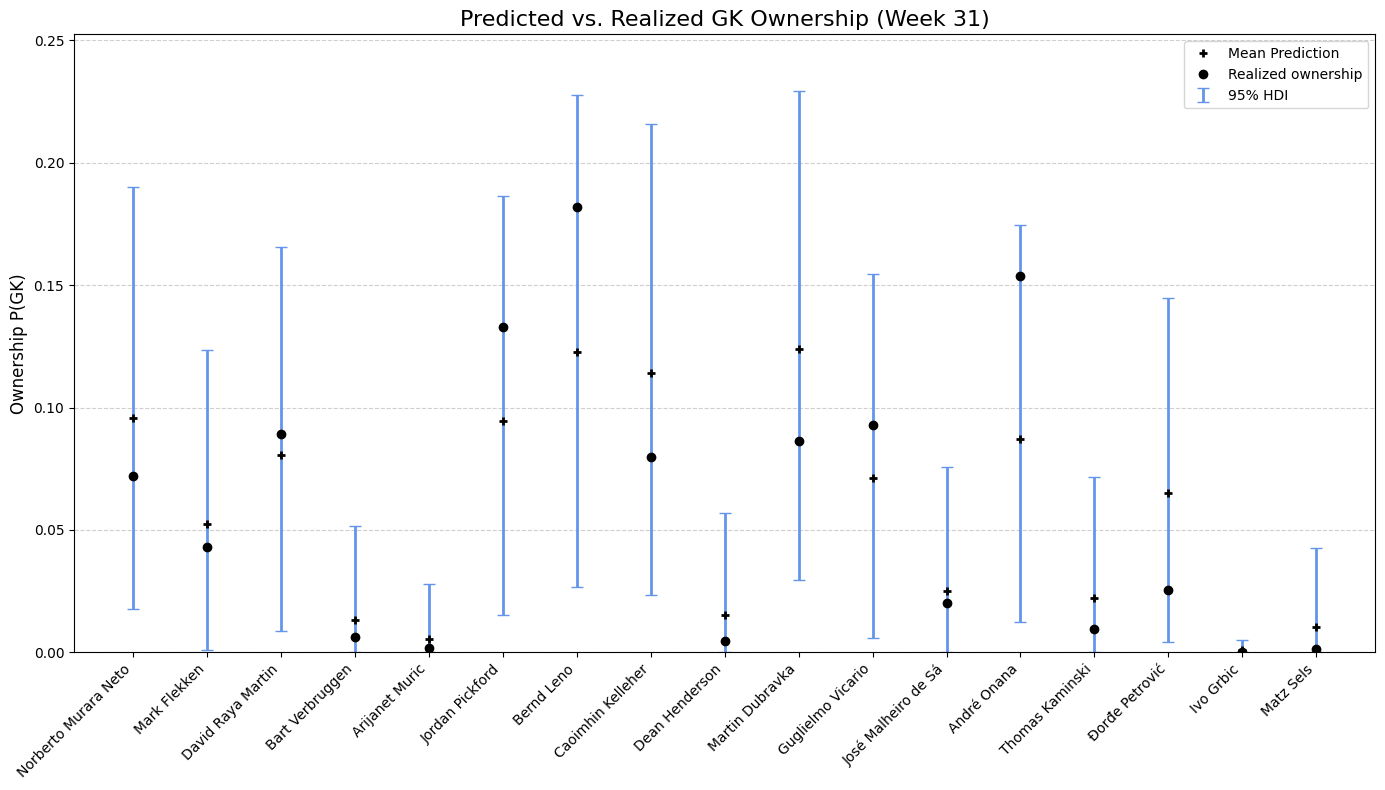

In [13]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_31.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_31,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_31,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_31,
    gk_probs_obs_31,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 31)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_31)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/2574176071.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


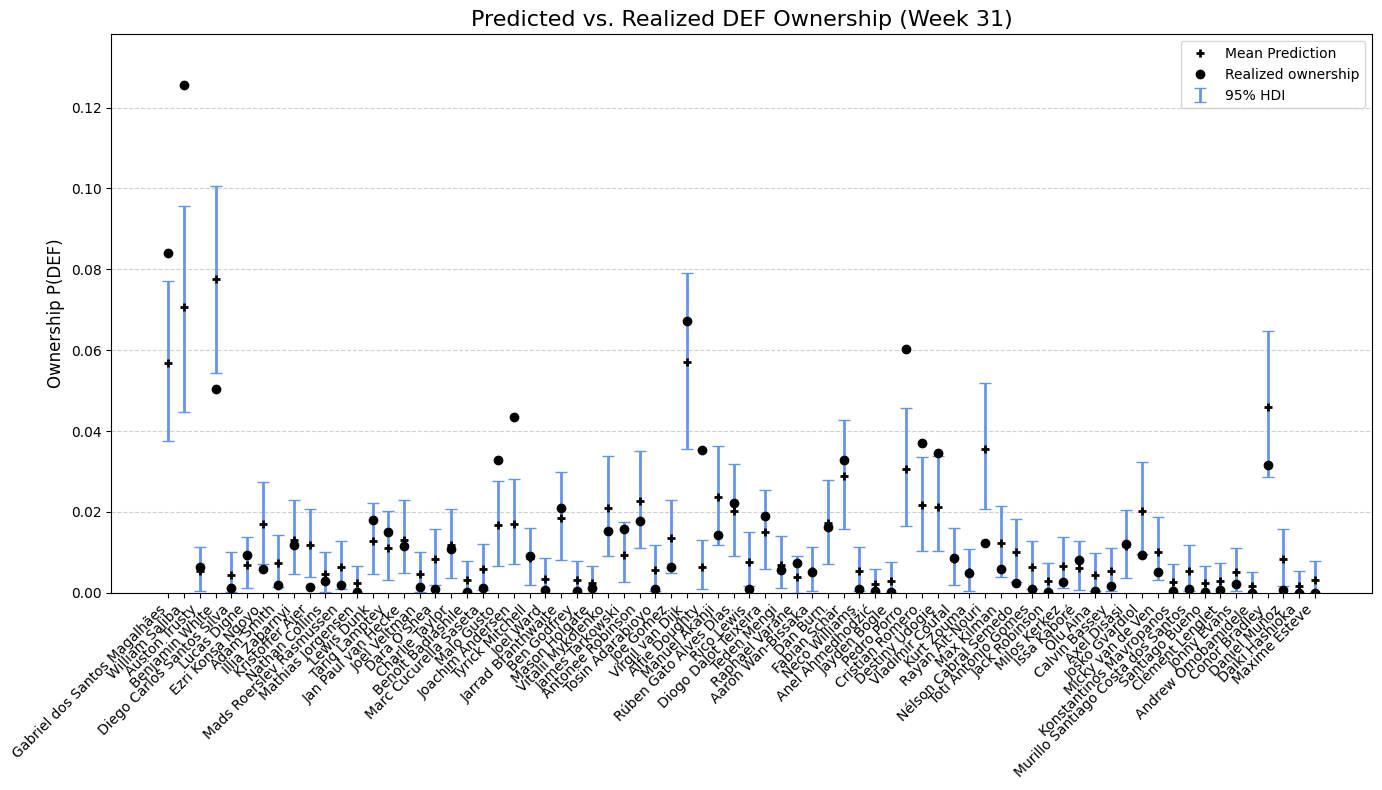

In [14]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_31.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_31,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_31,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_31,
    def_probs_obs_31,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 31)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_31)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/3525863778.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


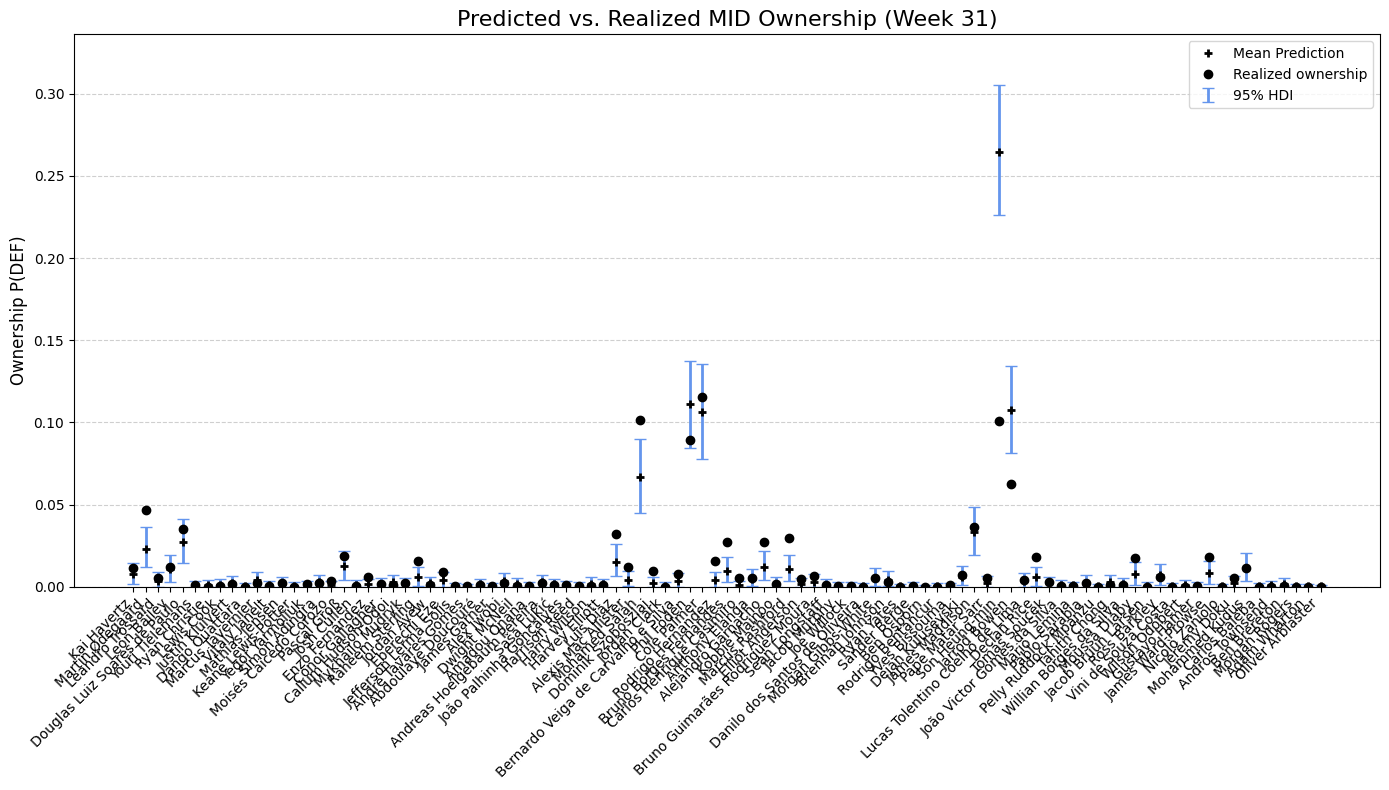

In [15]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_31.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_31,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_31,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_31,
    mid_probs_obs_31,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 31)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_31)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/1246936242.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


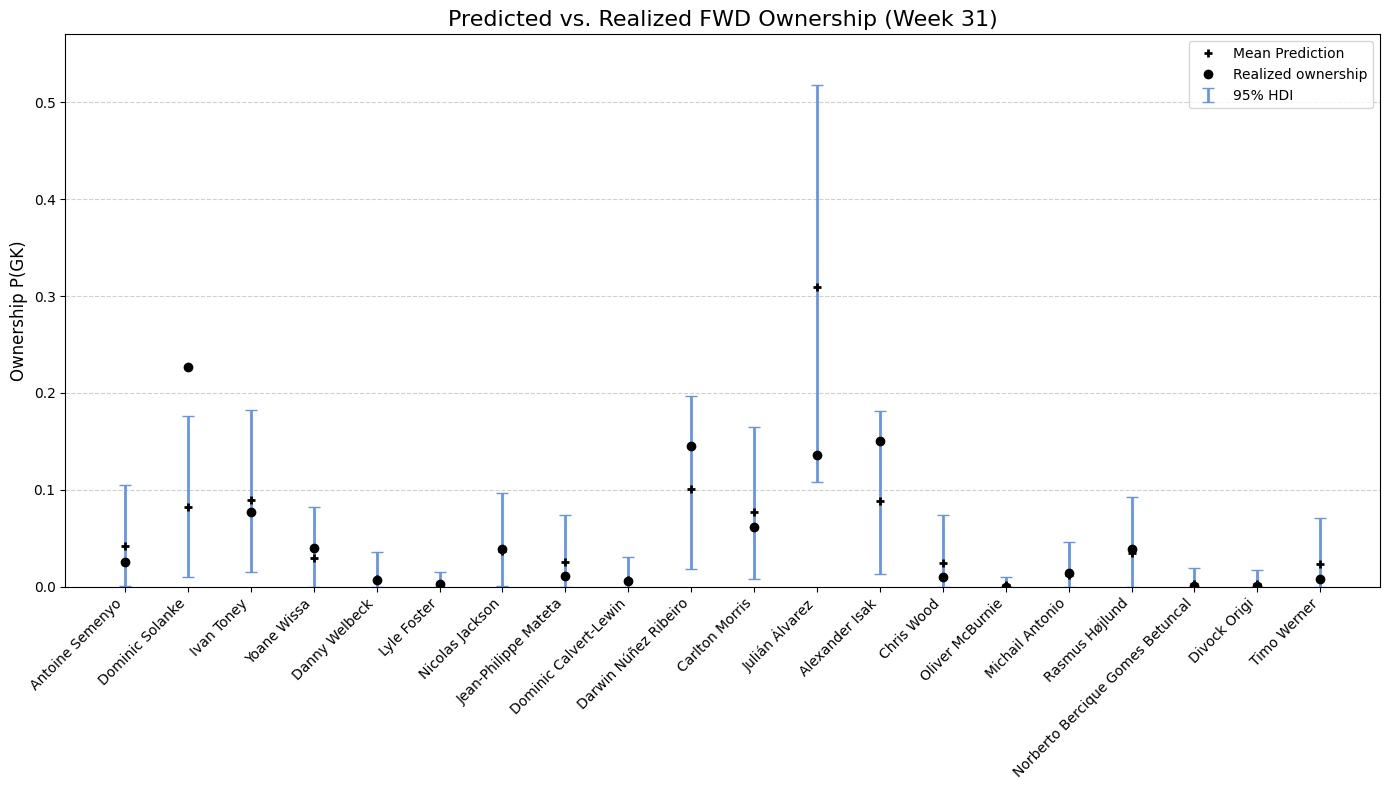

In [16]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_31.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_31,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_31,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_31,
    fwd_probs_obs_31,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 31)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_31)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [17]:
generated_portfolios_31 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_31, X_def_31, X_mid_31, X_fwd_31],
    ids = ids_31,
    costs=players_preds_31['value'].tolist(),
    budget=84,
    teams=teams_31,
    xp_preds=xPts_31,
    p_vectors=p_vectors_31
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 0
✅ Collected 0 valid teams after 20000 attempts...: 0
✅ Collected 0 valid teams after 30000 attempts...: 0
✅ Collected 0 valid teams after 40000 attempts...: 0
✅ Collected 0 valid teams after 50000 attempts...: 0
✅ Collected 0 valid teams after 60000 attempts...: 0
✅ Collected 0 valid teams after 70000 attempts...: 0
✅ Collected 0 valid teams after 80000 attempts...: 0
✅ Collected 0 valid teams after 90000 attempts...: 0
✅ Collected 0 valid teams after 100000 attempts...: 0
✅ Collected 0 valid teams after 110000 attempts...: 0
✅ Collected 0 valid teams after 120000 attempts...: 0
✅ Collected 0 valid teams after 130000 attempts...: 1
✅ Collected 0 valid teams after 140000 attempts...: 1
✅ Collected 0 valid teams after 150000 attempts...: 1
✅ Collected 0 valid teams after 160000 attempts...: 1
✅ Collected 0 valid teams after 170000 attempts...: 1
✅ Collecte

KeyboardInterrupt: 

In [ ]:
Wo_31 = []
for i in generated_portfolios_31:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_31['fpl_id'].index.tolist()])
    Wo_31.append(squad)

len(Wo_31)


500

In [ ]:

delta_sample_trace_31 = monte_carlo_simulation(Wo_31, mu_delta_31, cov_mat_31, sigma_delta_31)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_31 = az.summary(delta_sample_trace_31, var_names=["delta"], round_to=2)
summary_31


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_31 = delta_sample_trace_31.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_31, n_draws_31, n_players_31 = delta_raw_31.shape
delta_flattened_31 = delta_raw_31.reshape(n_chains_31 * n_draws_31, n_players_31)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_31 = np.dot(Wo_31, delta_flattened_31.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_31 = np.percentile(opponent_performances_31, 90, axis=0)

delta_samples_31 = delta_sample_trace_31.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_31 = np.percentile(Gr_samples_31, 90)  # shape (N_samples,)

mu_delta_31, cov_delta_31, mu_G_31, var_G_31, cov_delta_G_31, sigma_G_31 = generate_cov_delta(delta_flattened_31, Gr_samples_31)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_31, best_w_31, best_prob_31 = optimize_portfolio(add_fantasy_constraints, ids_31, prices_31, mu_delta_31, cov_delta_31, mu_G_31, var_G_31, cov_delta_G_31, lambdas, delta_samples_31, Gr_scalar_31, players_preds_31, 84)
print(f"Best λ: {best_lambda_31}, Best Probability of Outperforming: {best_prob_31}")

selected_31, player_names_31, total_points_31, team_cost_31, formation_31 = selected_info(best_w_31, fpl_teams_ids, players_preds_31, fg_managers_31)
print('fpl_ids: ', selected_31, '\nfpl_names: ', player_names_31, '\ntotal_points: ', total_points_31, '\nteam_cost: ', team_cost_31, '\nformation: ', formation_31)

players_preds_31[players_preds_31['fpl_id'].isin(selected_31)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_31[players_preds_31['fpl_id'].isin(selected_31)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_31 = players_preds_31[players_preds_31['fpl_id'].isin(selected_31)].copy()
# players_selected_31 = players_selected_31.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_31['xp_rank'] = players_selected_31['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_31['xp_rank'] == 1,  # Highest xp_preds
    players_selected_31['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_31['score'] = players_selected_31['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_31 = sum(players_selected_31['score'].values)
print(total_points_31, players_selected_31['xP'].values, '--------->', players_selected_31['xP_pred'].values)

players_selected_31[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_31 = fg_managers[fg_managers['gameweek'] == 31]
fg_managers_31[['points']]

position_31 = (fg_managers_31['points'] > total_points_31).sum() + 1

# 4. Display result
total_managers_31 = len(fg_managers_31)
percentile_31 = percentile_34 = 100 * (1 - (position_31 - 1) / total_managers_31)

print(total_points_31, total_managers_31)

print(f"Your predicted player’s total of {total_points_31} points would rank:")
print(f"→ Position: {position_31} out of {total_managers_31} managers")
print(f"→ Percentile: Top {percentile_31:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_31 = fg_managers_31.sort_values('points', ascending=False).reset_index(drop=True)

nearby_31 = fg_sorted_31.iloc[max(position_31-15, 0):position_31+2][['points','prize']]

player_prize_31 = fg_sorted_31.iloc[position_31 - 1]['prize']
if pd.isna(player_prize_31):
    player_prize_31 = "No prize"

print(f"→ Prize at position {position_31}: {player_prize_31}")
print("\nClosest scores around you:")
print(nearby_31)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# GW 32


## Generate Cov_Mat


In [18]:
fg_managers_32  = fg_managers[fg_managers['gameweek'] == 32]
data_23_24_32 = data_23_24[data_23_24['event'] < 32]
players_preds_32 =  data_23_24[data_23_24['event'] == 32]

mu_delta_32, sigma_delta_32, cov_mat_32, valid_player_ids_32 = generate_cov_mat(players_preds_32, data_23_24_32)


Starting to optimize team selection...
(227, 343)
(3587, 343)
(224,) (224,) (224, 224)


## Data Preparations


In [19]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_32 = data_23_24_32[data_23_24_32['fpl_id'].isin(valid_player_ids_32)].reset_index(drop=True)
players_preds_32 = players_preds_32[players_preds_32['fpl_id'].isin(valid_player_ids_32)].reset_index(drop=True)
data_32, prices_32, xPts_32, positions_32, teams_32, ids_32, X_32, names_32, probs_32 = clean_data(players_preds_32, valid_player_ids_32)

starting to clean data...
data successfully cleaned...


In [20]:
X_gk_32 = X_32[0][gk_beta_feats]
X_def_32 = X_32[1][def_beta_feats]
X_mid_32 = X_32[2][mid_beta_feats]
X_fwd_32 = X_32[3][fwd_beta_feats]

alphas_32 = {
        'GK': np.exp(X_gk_32 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_32 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_32 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_32 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_32 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_32.items()}
p_vectors_32

{'GK': array([7.94335646e-02, 5.77536267e-02, 4.55669763e-02, 4.59656099e-02,
        1.51323803e-02, 2.36379264e-02, 3.23592626e-02, 5.87025272e-02,
        1.31361256e-01, 8.33475140e-04, 1.20114055e-02, 9.46631633e-02,
        2.82576890e-02, 1.32469758e-02, 3.12033531e-02, 2.76412557e-01,
        1.83281643e-03, 8.27287899e-03, 2.67839891e-16, 4.33525560e-02]),
 'DEF': array([1.06411935e-01, 6.60467503e-01, 7.64316083e-05, 3.05416000e-02,
        2.26928020e-03, 9.79191886e-08, 4.77544796e-04, 1.41955900e-04,
        1.31244134e-03, 1.17576621e-06, 2.52646844e-03, 1.96235490e-03,
        3.36709210e-05, 5.05995375e-05, 6.85773076e-04, 2.66688711e-03,
        1.82194741e-02, 5.07375694e-04, 2.73782828e-03, 4.02925779e-04,
        8.45938480e-04, 3.57599781e-04, 4.96078896e-03, 7.52874520e-04,
        5.44665876e-04, 3.53192706e-03, 4.93957146e-06, 3.66698900e-05,
        9.71260090e-04, 4.49541258e-04, 2.43813755e-03, 1.86205027e-04,
        1.38915970e-03, 5.10038712e-02, 1.6393669

## Plots


In [21]:
gk_names_32 = names_32[0]
def_names_32 = names_32[1]
mid_names_32 = names_32[2]
fwd_names_32 = names_32[3]

gk_probs_obs_32 = probs_32[0]
def_probs_obs_32 = probs_32[1]
mid_probs_obs_32 = probs_32[2]
fwd_probs_obs_32 = probs_32[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/3878404109.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


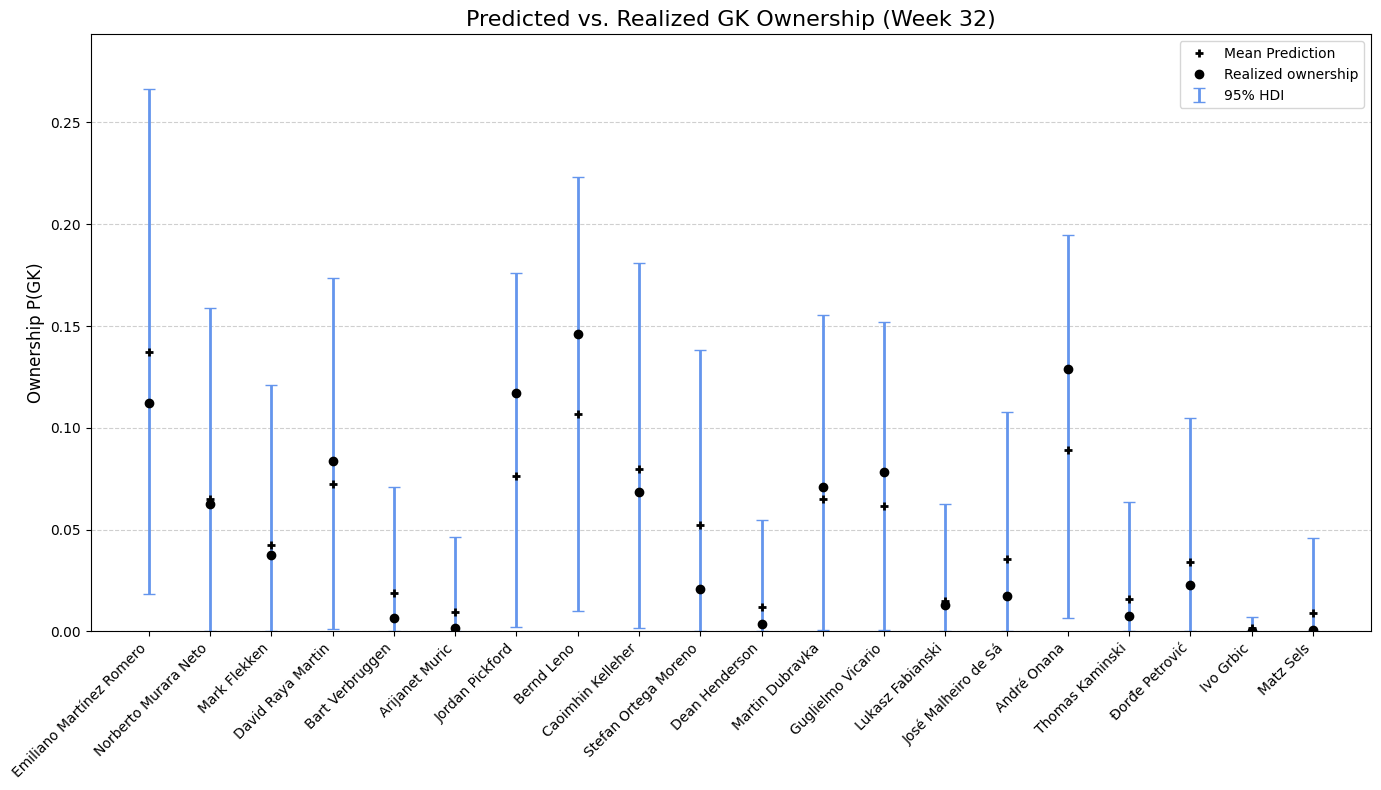

In [22]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_32.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_32,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_32,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_32,
    gk_probs_obs_32,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 32)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_32)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/1639338934.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


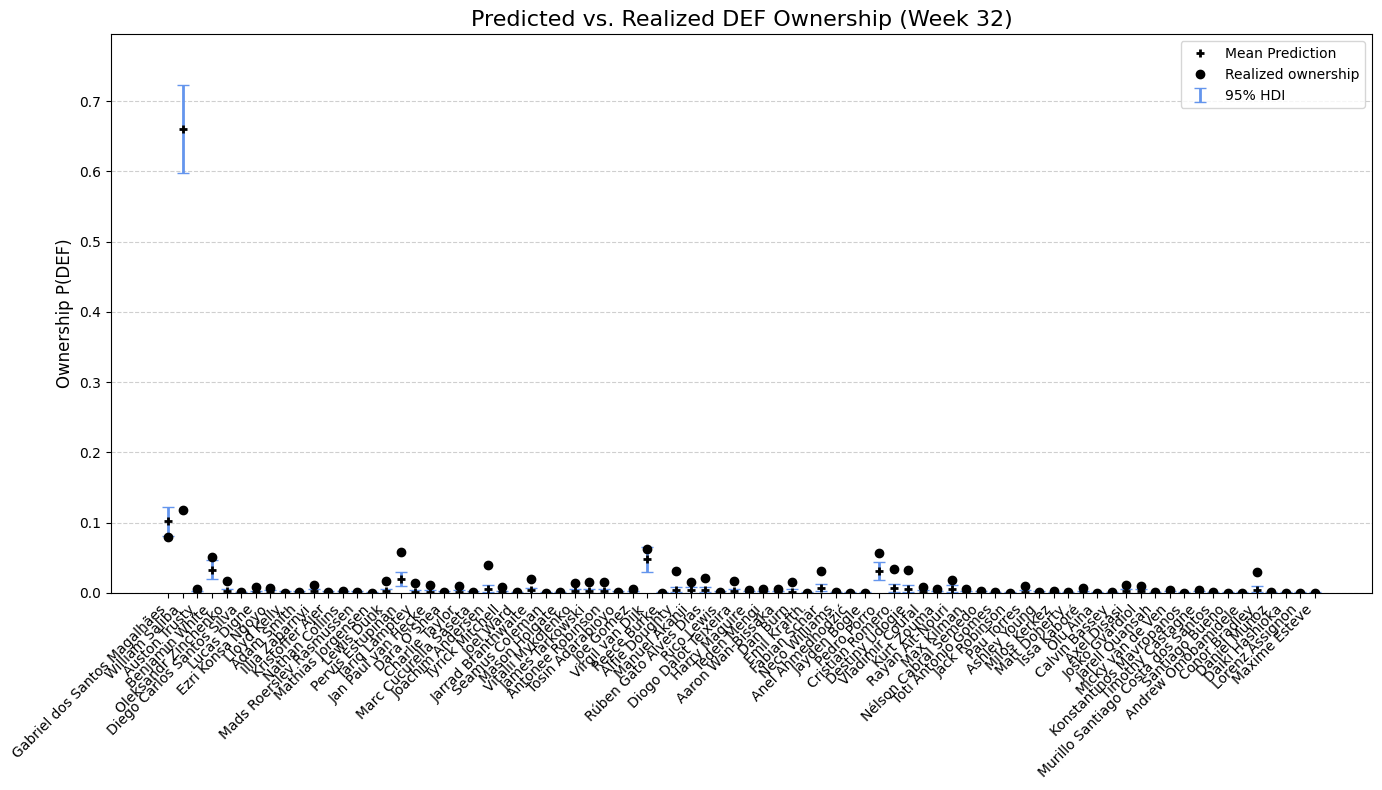

In [23]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_32.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_32,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_32,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_32,
    def_probs_obs_32,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 32)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_32)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/631165108.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


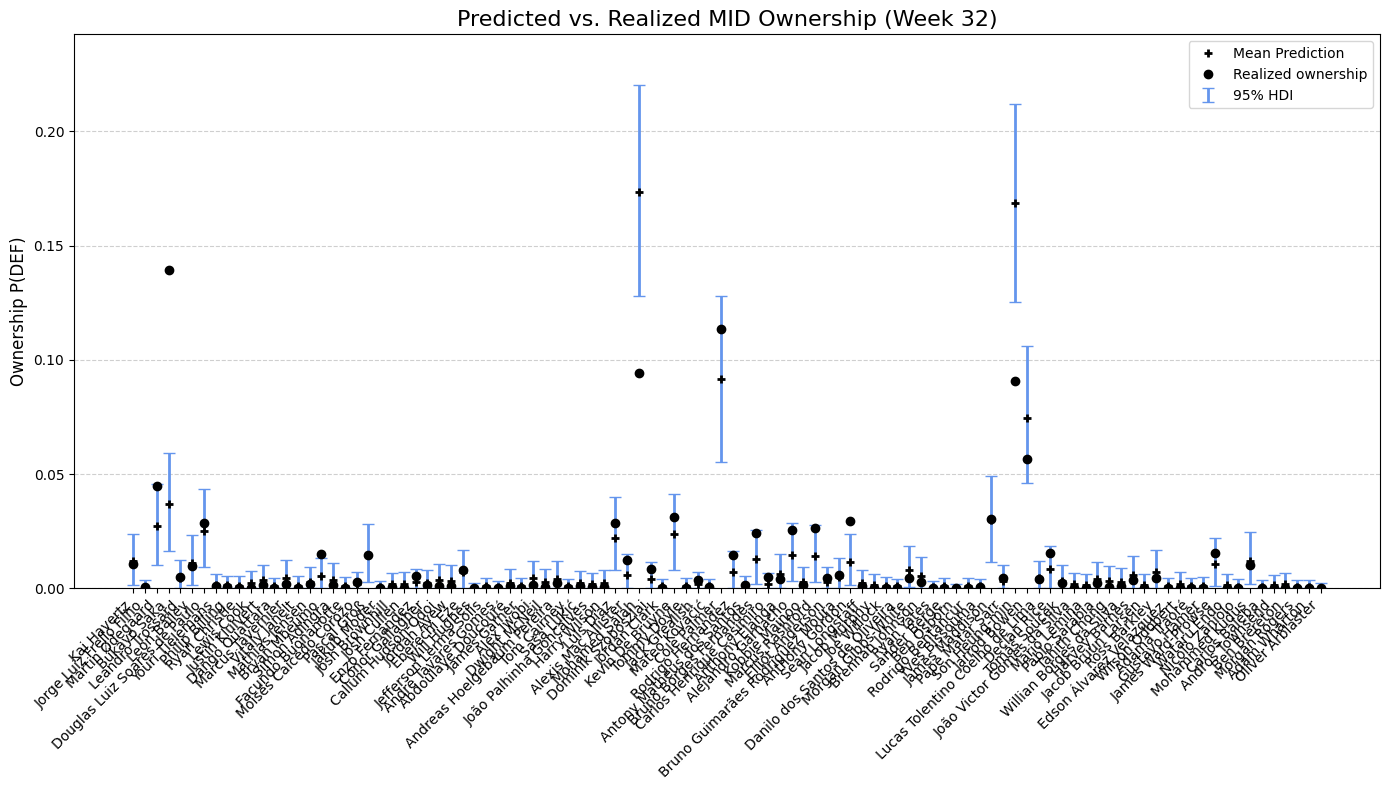

In [24]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_32.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_32,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_32,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_32,
    mid_probs_obs_32,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 32)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_32)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/1179943370.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


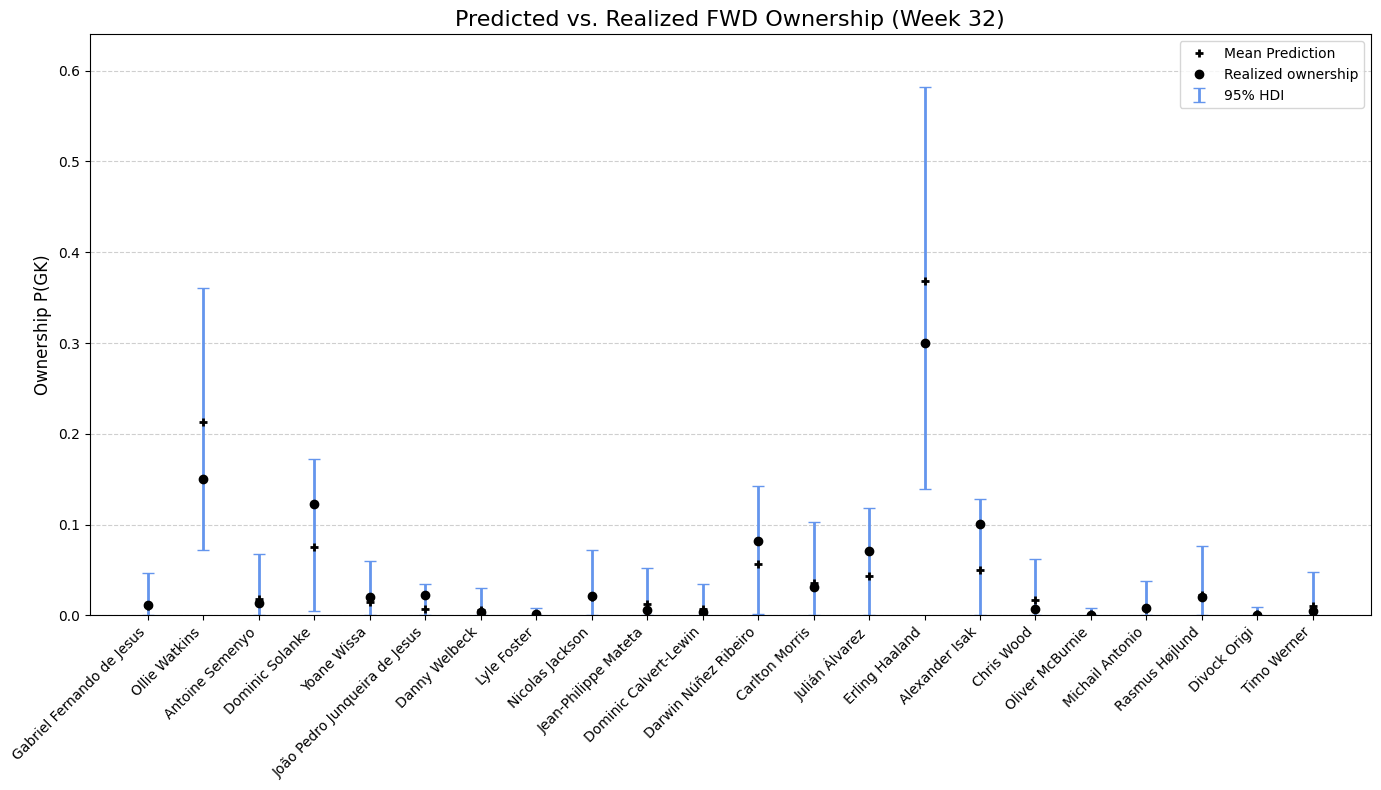

In [25]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_32.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_32,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_32,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_32,
    fwd_probs_obs_32,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 32)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_32)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [26]:
generated_portfolios_32 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_32, X_def_32, X_mid_32, X_fwd_32],
    ids = ids_32,
    costs=players_preds_32['value'].tolist(),
    budget=84,
    teams=teams_32,
    xp_preds=xPts_32,
    p_vectors=p_vectors_32
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 32
✅ Collected 0 valid teams after 20000 attempts...: 75
✅ Collected 0 valid teams after 30000 attempts...: 110
✅ Collected 0 valid teams after 40000 attempts...: 152
✅ Collected 0 valid teams after 50000 attempts...: 182
✅ Collected 0 valid teams after 60000 attempts...: 215
✅ Collected 0 valid teams after 70000 attempts...: 238
✅ Collected 0 valid teams after 80000 attempts...: 263
✅ Collected 0 valid teams after 90000 attempts...: 285
✅ Collected 0 valid teams after 100000 attempts...: 321
✅ Collected 0 valid teams after 110000 attempts...: 360
✅ Collected 0 valid teams after 120000 attempts...: 389
✅ Collected 0 valid teams after 130000 attempts...: 421
✅ Collected 0 valid teams after 140000 attempts...: 457
✅ Collected 0 valid teams after 150000 attempts...: 493
✅ Collected 0 valid teams after 160000 attempts...: 500
🎯 Done! Generated 500 unique portf

In [27]:
Wo_32 = []
for i in generated_portfolios_32:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_32['fpl_id'].index.tolist()])
    Wo_32.append(squad)

len(Wo_32)


500

In [28]:

delta_sample_trace_32 = monte_carlo_simulation(Wo_32, mu_delta_32, cov_mat_32, sigma_delta_32)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_32 = az.summary(delta_sample_trace_32, var_names=["delta"], round_to=2)
summary_32


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 37,252


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.10,0.02,4.06,4.13,0.0,0.0,2009.70,1775.81,NaN
delta[1],3.49,0.02,3.45,3.52,0.0,0.0,1980.26,2131.63,NaN
delta[2],1.93,0.02,1.89,1.96,0.0,0.0,1880.59,1775.36,NaN
delta[3],0.59,0.02,0.55,0.62,0.0,0.0,1907.89,1850.49,NaN
delta[4],4.23,0.02,4.19,4.26,0.0,0.0,1723.13,1682.46,NaN
...,...,...,...,...,...,...,...,...,...
delta[219],0.09,0.02,0.06,0.13,0.0,0.0,1946.62,1875.50,NaN
delta[220],0.07,0.02,0.04,0.10,0.0,0.0,2057.05,1631.71,NaN
delta[221],0.56,0.02,0.53,0.59,0.0,0.0,1814.84,1819.63,NaN
delta[222],0.65,0.02,0.62,0.69,0.0,0.0,1802.55,1560.74,NaN


In [29]:
delta_raw_32 = delta_sample_trace_32.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_32, n_draws_32, n_players_32 = delta_raw_32.shape
delta_flattened_32 = delta_raw_32.reshape(n_chains_32 * n_draws_32, n_players_32)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_32 = np.dot(Wo_32, delta_flattened_32.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_32 = np.percentile(opponent_performances_32, 90, axis=0)

delta_samples_32 = delta_sample_trace_32.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_32 = np.percentile(Gr_samples_32, 90)  # shape (N_samples,)

mu_delta_32, cov_delta_32, mu_G_32, var_G_32, cov_delta_G_32, sigma_G_32 = generate_cov_delta(delta_flattened_32, Gr_samples_32)

(2000, 224) (2000,)


In [30]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_32, best_w_32, best_prob_32 = optimize_portfolio(add_fantasy_constraints, ids_32, prices_32, mu_delta_32, cov_delta_32, mu_G_32, var_G_32, cov_delta_G_32, lambdas, delta_samples_32, Gr_scalar_32, players_preds_32, 84)
print(f"Best λ: {best_lambda_32}, Best Probability of Outperforming: {best_prob_32}")

selected_32, player_names_32, total_points_32, team_cost_32, formation_32 = selected_info(best_w_32, fpl_teams_ids, players_preds_32, fg_managers_32)
print('fpl_ids: ', selected_32, '\nfpl_names: ', player_names_32, '\ntotal_points: ', total_points_32, '\nteam_cost: ', team_cost_32, '\nformation: ', formation_32)

players_preds_32[players_preds_32['fpl_id'].isin(selected_32)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 20, DEF: 80, MID: 102, FWD: 22
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Liverpool', 'Liverpool', 'Manchester City', 'Manchester City', 'Newcastle United', 'Tottenham Hotspur', 'Manchester United']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 81.7  :  [ 8.9  5.8  5.9  8.8 13.4  6.4  6.   6.   5.5 10.1  4.9]
[10.   5.   7.5 13.   8.   2.  10.   3.   7.   5.   2. ] ---------> [1.99959872 5.31155753 6.77034616 1.89814458 5.44006746 1.93480492
 8.35417875 3.69007846 1.828144   4.46627226 3.01794673]
Your predicted player’s total of 72.5 points would rank:
→ Position: 51 out of 234 managers
→ Percentile: Top 78.21%

Closest scores around you:
   points    prize
0    73.0  R 22.39
1    73.0  R 22.39
2    72.5  R 22.39
3    72.0  R 22.39
4    72.0  R 22.39
fpl_ids:  [19, 20, 29, 60, 308, 343, 362, 412, 427, 516, 597] 
fpl_names:  ['Bukayo Saka', 'William Saliba', 'Benjamin White', 'Ollie Watkins', 'Mohamed Salah', 'J

,Understat_Name,position,team,xP_pred,total_points
5,Bukayo Saka,MID,Arsenal,1.999599,10.0
6,William Saliba,DEF,Arsenal,5.311558,5.0
9,Ben White,DEF,Arsenal,6.770346,5.0
18,Ollie Watkins,FWD,Aston Villa,1.898145,13.0
97,Mohamed Salah,MID,Liverpool,5.440067,8.0
105,Julián Álvarez,FWD,Manchester City,1.934805,2.0
114,Cole Palmer,MID,Manchester City,8.354179,5.0
132,Anthony Gordon,MID,Newcastle United,3.690078,3.0
137,Fabian Schär,DEF,Newcastle United,1.828144,7.0
156,Son Heung-Min,MID,Tottenham Hotspur,4.466272,5.0


In [31]:
players_preds_32[players_preds_32['fpl_id'].isin(selected_32)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
5,Bukayo Saka,MID,8.9,Arsenal,10.0
6,William Saliba,DEF,5.8,Arsenal,5.0
9,Ben White,DEF,5.9,Arsenal,5.0
18,Ollie Watkins,FWD,8.8,Aston Villa,13.0
97,Mohamed Salah,MID,13.4,Liverpool,8.0
105,Julián Álvarez,FWD,6.4,Manchester City,2.0
114,Cole Palmer,MID,6.0,Manchester City,5.0
132,Anthony Gordon,MID,6.0,Newcastle United,3.0
137,Fabian Schär,DEF,5.5,Newcastle United,7.0
156,Son Heung-Min,MID,10.1,Tottenham Hotspur,5.0


In [32]:
# Get total points
players_selected_32 = players_preds_32[players_preds_32['fpl_id'].isin(selected_32)].copy()
# players_selected_32 = players_selected_32.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_32['xp_rank'] = players_selected_32['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_32['xp_rank'] == 1,  # Highest xp_preds
    players_selected_32['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_32['score'] = players_selected_32['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_32 = sum(players_selected_32['score'].values)
print(total_points_32, players_selected_32['xP'].values, '--------->', players_selected_32['xP_pred'].values)

players_selected_32[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

77.0 [ 3.6  6.2  8.   3.1  4.7  2.5 13.7  3.   2.8  7.7  4. ] ---------> [1.99959872 5.31155753 6.77034616 1.89814458 5.44006746 1.93480492
 8.35417875 3.69007846 1.828144   4.46627226 3.01794673]


,team,position,xP_pred,xP,xp_rank,score
5,Arsenal,MID,1.999599,3.6,8,3.6
6,Arsenal,DEF,5.311558,6.2,4,6.2
9,Arsenal,DEF,6.770346,8.0,2,12.0
18,Aston Villa,FWD,1.898145,3.1,10,3.1
97,Liverpool,MID,5.440067,4.7,3,4.7
105,Manchester City,FWD,1.934805,2.5,9,2.5
114,Manchester City,MID,8.354179,13.7,1,27.4
132,Newcastle United,MID,3.690078,3.0,6,3.0
137,Newcastle United,DEF,1.828144,2.8,11,2.8
156,Tottenham Hotspur,MID,4.466272,7.7,5,7.7


In [33]:
fg_managers_32 = fg_managers[fg_managers['gameweek'] == 32]
fg_managers_32[['points']]

position_32 = (fg_managers_32['points'] > total_points_32).sum() + 1

# 4. Display result
total_managers_32 = len(fg_managers_32)
percentile_32 = percentile_34 = 100 * (1 - (position_32 - 1) / total_managers_32)

print(total_points_32, total_managers_32)

print(f"Your predicted player’s total of {total_points_32} points would rank:")
print(f"→ Position: {position_32} out of {total_managers_32} managers")
print(f"→ Percentile: Top {percentile_32:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_32 = fg_managers_32.sort_values('points', ascending=False).reset_index(drop=True)

nearby_32 = fg_sorted_32.iloc[max(position_32-15, 0):position_32+2][['points','prize']]

player_prize_32 = fg_sorted_32.iloc[position_32 - 1]['prize']
if pd.isna(player_prize_32):
    player_prize_32 = "No prize"

print(f"→ Prize at position {position_32}: {player_prize_32}")
print("\nClosest scores around you:")
print(nearby_32)

77.0 234
Your predicted player’s total of 77.0 points would rank:
→ Position: 32 out of 234 managers
→ Percentile: Top 86.75%
→ Prize at position 32: R 22.39

Closest scores around you:
    points    prize
17    83.0  R 22.39
18    83.0  R 22.39
19    82.0  R 22.39
20    82.0  R 22.39
21    82.0  R 22.39
22    81.0  R 22.39
23    81.0  R 22.39
24    80.5  R 22.39
25    79.5  R 22.39
26    79.5  R 22.39
27    79.0  R 22.39
28    78.0  R 22.39
29    78.0  R 22.39
30    77.5  R 22.39
31    77.0  R 22.39
32    77.0  R 22.39
33    76.5  R 22.39


# GW 33


## Generate Cov_Mat


In [34]:
fg_managers_33  = fg_managers[fg_managers['gameweek'] == 33]
data_23_24_33 = data_23_24[data_23_24['event'] < 33]
players_preds_33 =  data_23_24[data_23_24['event'] == 33]

mu_delta_33, sigma_delta_33, cov_mat_33, valid_player_ids_33 = generate_cov_mat(players_preds_33, data_23_24_33)


Starting to optimize team selection...
(223, 343)
(3663, 343)
(221,) (221,) (221, 221)


## Data Preparations


In [35]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_33 = data_23_24_33[data_23_24_33['fpl_id'].isin(valid_player_ids_33)].reset_index(drop=True)
players_preds_33 = players_preds_33[players_preds_33['fpl_id'].isin(valid_player_ids_33)].reset_index(drop=True)
data_33, prices_33, xPts_33, positions_33, teams_33, ids_33, X_33, names_33, probs_33 = clean_data(players_preds_33, valid_player_ids_33)

starting to clean data...
data successfully cleaned...


In [36]:
X_gk_33 = X_33[0][gk_beta_feats]
X_def_33 = X_33[1][def_beta_feats]
X_mid_33 = X_33[2][mid_beta_feats]
X_fwd_33 = X_33[3][fwd_beta_feats]

alphas_33 = {
        'GK': np.exp(X_gk_33 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_33 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_33 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_33 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_33 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_33.items()}
p_vectors_33

{'GK': array([4.40241177e-02, 5.62832957e-02, 5.01256928e-02, 6.22127416e-02,
        3.89489543e-07, 3.40614529e-07, 5.70199491e-02, 4.18745331e-02,
        6.50009914e-03, 2.26265474e-01, 8.42089933e-02, 6.45775037e-02,
        7.69374358e-02, 1.13281704e-01, 3.64959112e-05, 1.16644083e-01,
        7.15047280e-06, 2.59641849e-12]),
 'DEF': array([0.03949047, 0.0732696 , 0.00354   , 0.00839318, 0.04957101,
        0.02710928, 0.00149983, 0.00603502, 0.01190643, 0.00380756,
        0.01058089, 0.00902267, 0.00691343, 0.01437212, 0.00815659,
        0.01676849, 0.01296044, 0.00421178, 0.00758083, 0.00225923,
        0.00732776, 0.0413574 , 0.02141566, 0.01084256, 0.010124  ,
        0.01662279, 0.00455686, 0.0059734 , 0.01603973, 0.01576031,
        0.00683049, 0.00225788, 0.0156363 , 0.03635233, 0.03604362,
        0.00210733, 0.00873139, 0.01606688, 0.0297993 , 0.01323604,
        0.02438082, 0.01314584, 0.01062949, 0.02112774, 0.00103099,
        0.02453244, 0.00087283, 0.00583398, 0

## Plots


In [37]:
gk_names_33 = names_33[0]
def_names_33 = names_33[1]
mid_names_33 = names_33[2]
fwd_names_33 = names_33[3]

gk_probs_obs_33 = probs_33[0]
def_probs_obs_33 = probs_33[1]
mid_probs_obs_33 = probs_33[2]
fwd_probs_obs_33 = probs_33[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/1443614571.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


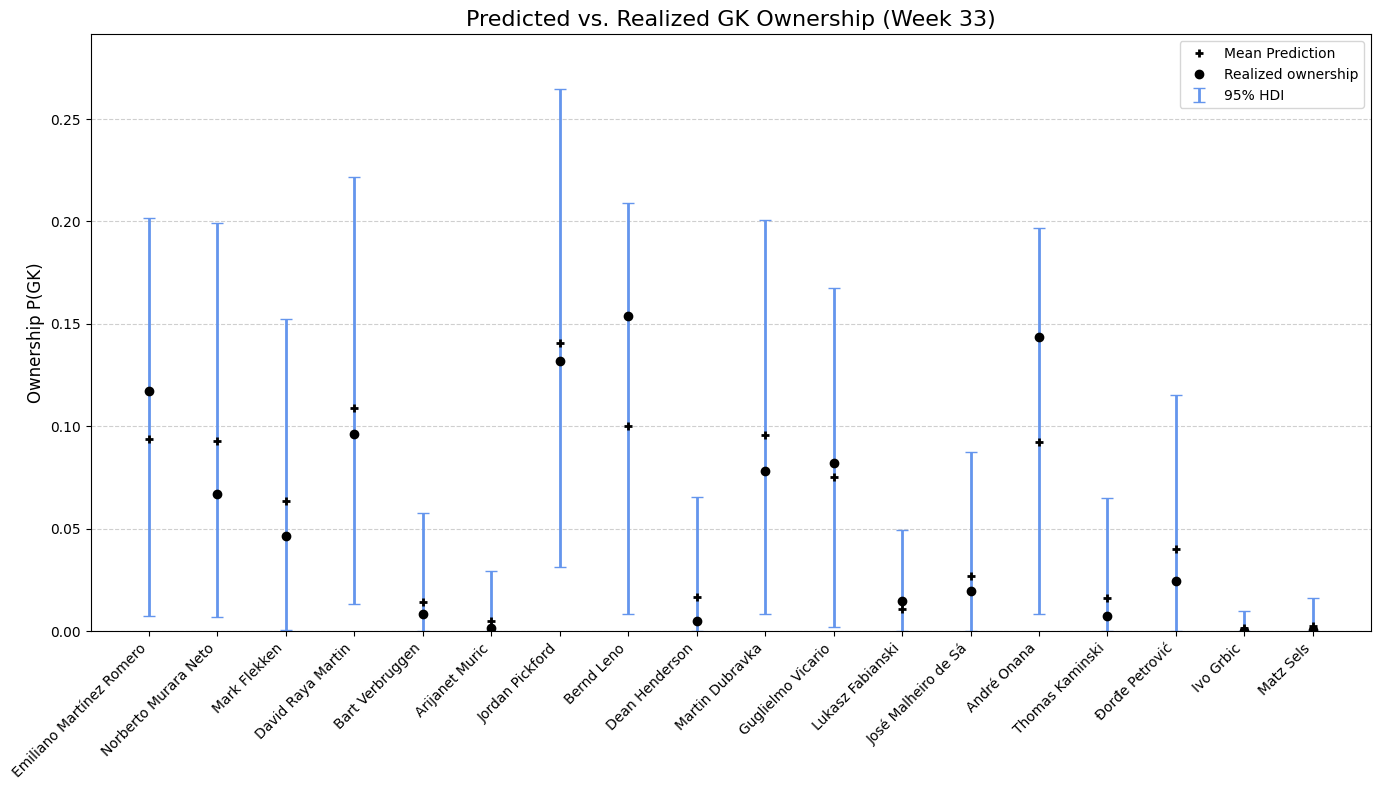

In [38]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_33.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_33,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_33,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_33,
    gk_probs_obs_33,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 33)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_33)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/485254887.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


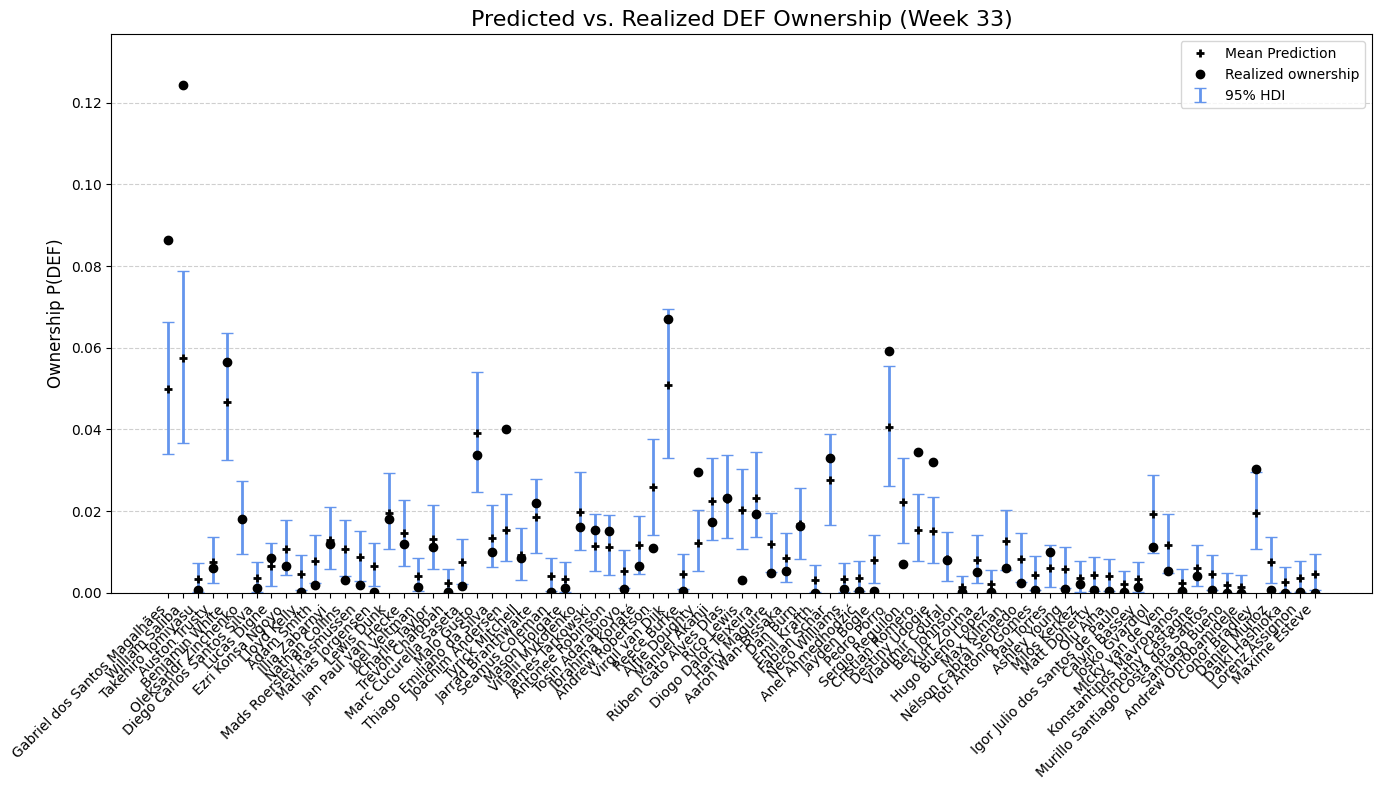

In [39]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_33.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_33,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_33,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_33,
    def_probs_obs_33,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 33)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_33)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/3607672296.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


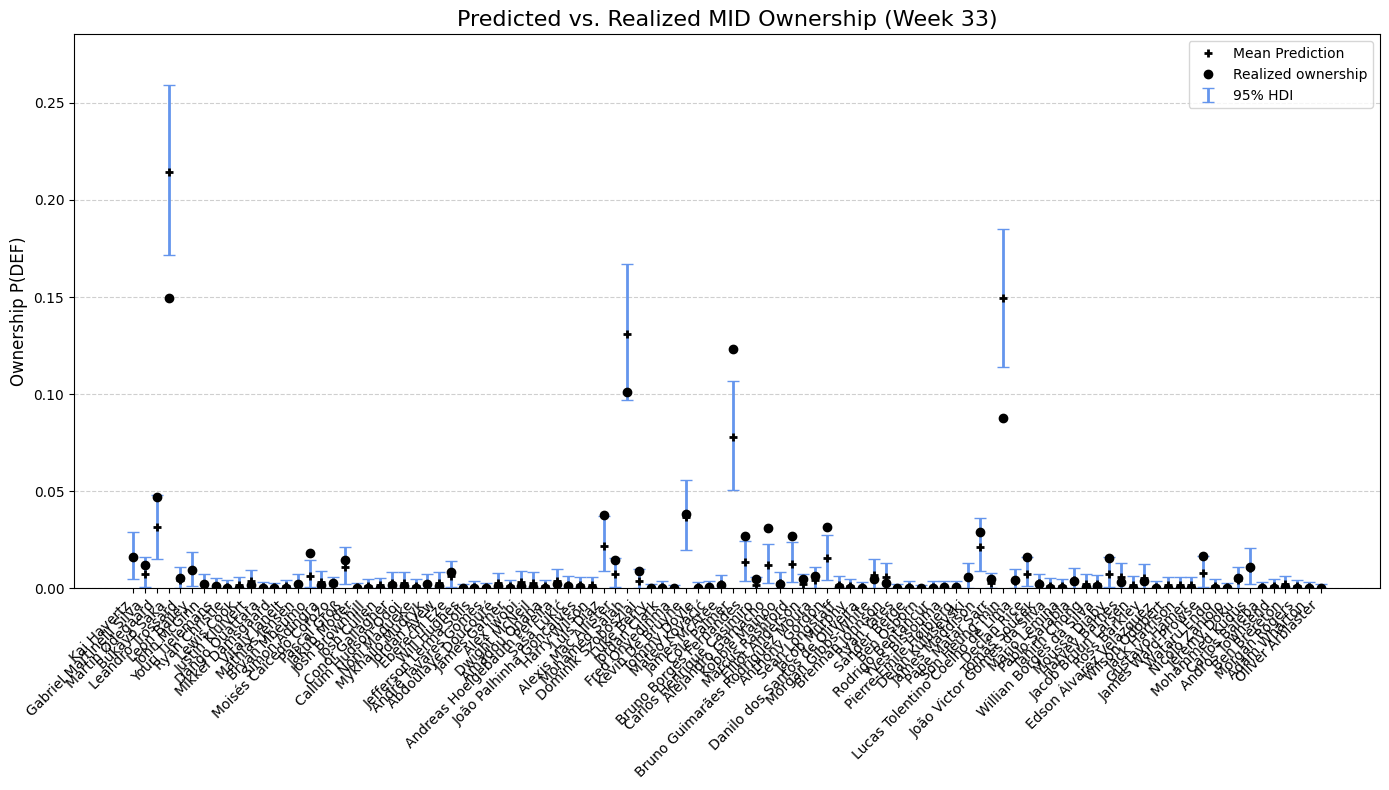

In [40]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_33.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_33,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_33,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_33,
    mid_probs_obs_33,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 33)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_33)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_73333/3810467738.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


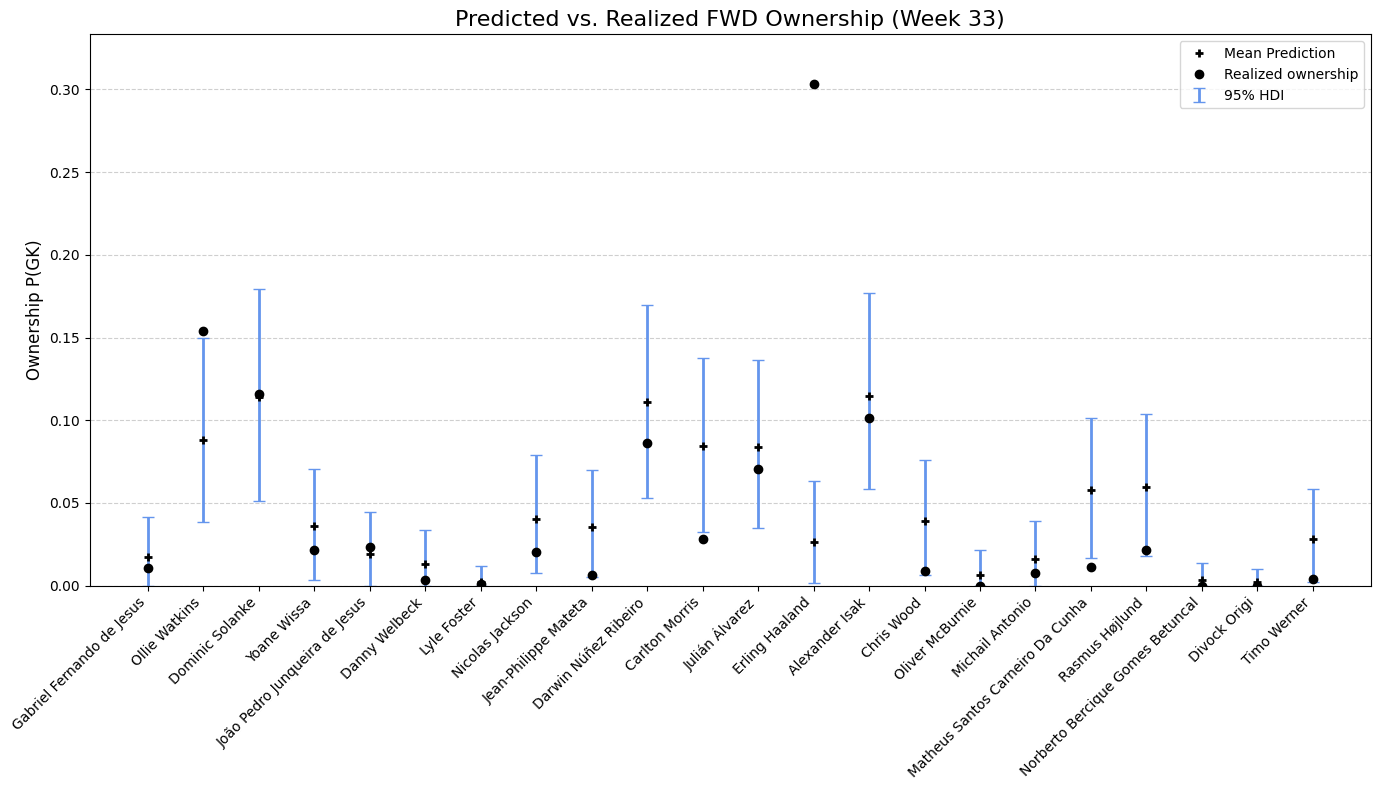

In [41]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_33.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_33,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_33,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_33,
    fwd_probs_obs_33,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 33)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_33)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios_33 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_33, X_def_33, X_mid_33, X_fwd_33],
    ids = ids_33,
    costs=players_preds_33['value'].tolist(),
    budget=84,
    teams=teams_33,
    xp_preds=xPts_33,
    p_vectors=p_vectors_33
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 20000 attempts...: 9
✅ Collected 0 valid teams after 30000 attempts...: 15
✅ Collected 0 valid teams after 40000 attempts...: 18
✅ Collected 0 valid teams after 50000 attempts...: 26
✅ Collected 0 valid teams after 60000 attempts...: 32
✅ Collected 0 valid teams after 70000 attempts...: 40
✅ Collected 0 valid teams after 80000 attempts...: 45
✅ Collected 0 valid teams after 90000 attempts...: 48
✅ Collected 0 valid teams after 100000 attempts...: 55
✅ Collected 0 valid teams after 110000 attempts...: 57
✅ Collected 0 valid teams after 120000 attempts...: 64
✅ Collected 0 valid teams after 130000 attempts...: 68
✅ Collected 0 valid teams after 140000 attempts...: 72
✅ Collected 0 valid teams after 150000 attempts...: 76
✅ Collected 0 valid teams after 160000 attempts...: 81
✅ Collected 0 valid teams after 170000 attempts...

In [ ]:
Wo_33 = []
for i in generated_portfolios_33:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_33['fpl_id'].index.tolist()])
    Wo_33.append(squad)

len(Wo_33)


500

In [ ]:

delta_sample_trace_33 = monte_carlo_simulation(Wo_33, mu_delta_33, cov_mat_33, sigma_delta_33)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_33 = az.summary(delta_sample_trace_33, var_names=["delta"], round_to=2)
summary_33


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_33 = delta_sample_trace_33.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_33, n_draws_33, n_players_33 = delta_raw_33.shape
delta_flattened_33 = delta_raw_33.reshape(n_chains_33 * n_draws_33, n_players_33)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_33 = np.dot(Wo_33, delta_flattened_33.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_33 = np.percentile(opponent_performances_33, 90, axis=0)

delta_samples_33 = delta_sample_trace_33.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_33 = np.percentile(Gr_samples_33, 90)  # shape (N_samples,)

mu_delta_33, cov_delta_33, mu_G_33, var_G_33, cov_delta_G_33, sigma_G_33 = generate_cov_delta(delta_flattened_33, Gr_samples_33)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_33, best_w_33, best_prob_33 = optimize_portfolio(add_fantasy_constraints, ids_33, prices_33, mu_delta_33, cov_delta_33, mu_G_33, var_G_33, cov_delta_G_33, lambdas, delta_samples_33, Gr_scalar_33, players_preds_33, 84)
print(f"Best λ: {best_lambda_33}, Best Probability of Outperforming: {best_prob_33}")

selected_33, player_names_33, total_points_33, team_cost_33, formation_33 = selected_info(best_w_33, fpl_teams_ids, players_preds_33, fg_managers_33)
print('fpl_ids: ', selected_33, '\nfpl_names: ', player_names_33, '\ntotal_points: ', total_points_33, '\nteam_cost: ', team_cost_33, '\nformation: ', formation_33)

players_preds_33[players_preds_33['fpl_id'].isin(selected_33)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_33[players_preds_33['fpl_id'].isin(selected_33)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_33 = players_preds_33[players_preds_33['fpl_id'].isin(selected_33)].copy()
# players_selected_33 = players_selected_33.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_33['xp_rank'] = players_selected_33['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_33['xp_rank'] == 1,  # Highest xp_preds
    players_selected_33['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_33['score'] = players_selected_33['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_33 = sum(players_selected_33['score'].values)
print(total_points_33, players_selected_33['xP'].values, '--------->', players_selected_33['xP_pred'].values)

players_selected_33[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_33 = fg_managers[fg_managers['gameweek'] == 33]
fg_managers_33[['points']]

position_33 = (fg_managers_33['points'] > total_points_33).sum() + 1

# 4. Display result
total_managers_33 = len(fg_managers_33)
percentile_33 = percentile_34 = 100 * (1 - (position_33 - 1) / total_managers_33)

print(total_points_33, total_managers_33)

print(f"Your predicted player’s total of {total_points_33} points would rank:")
print(f"→ Position: {position_33} out of {total_managers_33} managers")
print(f"→ Percentile: Top {percentile_33:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_33 = fg_managers_33.sort_values('points', ascending=False).reset_index(drop=True)

nearby_33 = fg_sorted_33.iloc[max(position_33-15, 0):position_33+2][['points','prize']]

player_prize_33 = fg_sorted_33.iloc[position_33 - 1]['prize']
if pd.isna(player_prize_33):
    player_prize_33 = "No prize"

print(f"→ Prize at position {position_33}: {player_prize_33}")
print("\nClosest scores around you:")
print(nearby_33)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# GW 34


## Generate Cov_Mat


In [ ]:
fg_managers_34  = fg_managers[fg_managers['gameweek'] == 34]
data_23_24_34 = data_23_24[data_23_24['event'] < 34]
players_preds_34 =  data_23_24[data_23_24['event'] == 34]

mu_delta_34, sigma_delta_34, cov_mat_34, valid_player_ids_34 = generate_cov_mat(players_preds_34, data_23_24_34)


Starting to optimize team selection...
(209, 343)
(4213, 343)
(208,) (208,) (208, 208)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_34 = data_23_24_34[data_23_24_34['fpl_id'].isin(valid_player_ids_34)].reset_index(drop=True)
players_preds_34 = players_preds_34[players_preds_34['fpl_id'].isin(valid_player_ids_34)].reset_index(drop=True)
data_34, prices_34, xPts_34, positions_34, teams_34, ids_34, X_34, names_34, probs_34 = clean_data(players_preds_34, valid_player_ids_34)

starting to clean data...
data successfully cleaned...


In [ ]:
X_gk_34 = X_34[0][gk_beta_feats]
X_def_34 = X_34[1][def_beta_feats]
X_mid_34 = X_34[2][mid_beta_feats]
X_fwd_34 = X_34[3][fwd_beta_feats]

alphas_34 = {
        'GK': np.exp(X_gk_34 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_34 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_34 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_34 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_34 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_34.items()}
p_vectors_34

{'GK': array([3.00208814e-02, 1.71939192e-01, 1.47058888e-05, 4.49238970e-01,
        3.26388875e-02, 2.10036576e-02, 1.09154367e-02, 3.01933277e-05,
        4.95578661e-14, 4.47398750e-02, 1.32397065e-01, 2.97637833e-05,
        6.49419689e-02, 1.31584225e-02, 2.83320948e-02, 5.98886065e-04]),
 'DEF': array([6.10437172e-02, 7.64903911e-02, 1.39219511e-02, 3.59394528e-03,
        9.07004761e-02, 8.08537646e-03, 5.91840244e-03, 7.27384624e-03,
        2.84847143e-03, 2.05138433e-03, 9.17303679e-03, 4.31166381e-04,
        7.35357179e-04, 1.12682052e-03, 4.38067750e-03, 3.08336115e-03,
        8.66477430e-03, 8.36724800e-03, 3.24672027e-02, 1.61723217e-02,
        4.08608582e-03, 9.33648567e-03, 2.29900132e-03, 3.35373666e-03,
        1.55686153e-02, 1.24428333e-02, 1.84022654e-03, 1.52225704e-03,
        1.35479286e-02, 1.27234778e-02, 3.35554438e-02, 3.50961609e-02,
        2.10929816e-02, 5.86194001e-03, 2.10834973e-04, 1.04134992e-02,
        9.33073945e-03, 1.25604889e-02, 2.8527235

## Plots


In [ ]:
gk_names_34 = names_34[0]
def_names_34 = names_34[1]
mid_names_34 = names_34[2]
fwd_names_34 = names_34[3]

gk_probs_obs_34 = probs_34[0]
def_probs_obs_34 = probs_34[1]
mid_probs_obs_34 = probs_34[2]
fwd_probs_obs_34 = probs_34[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2517278040.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


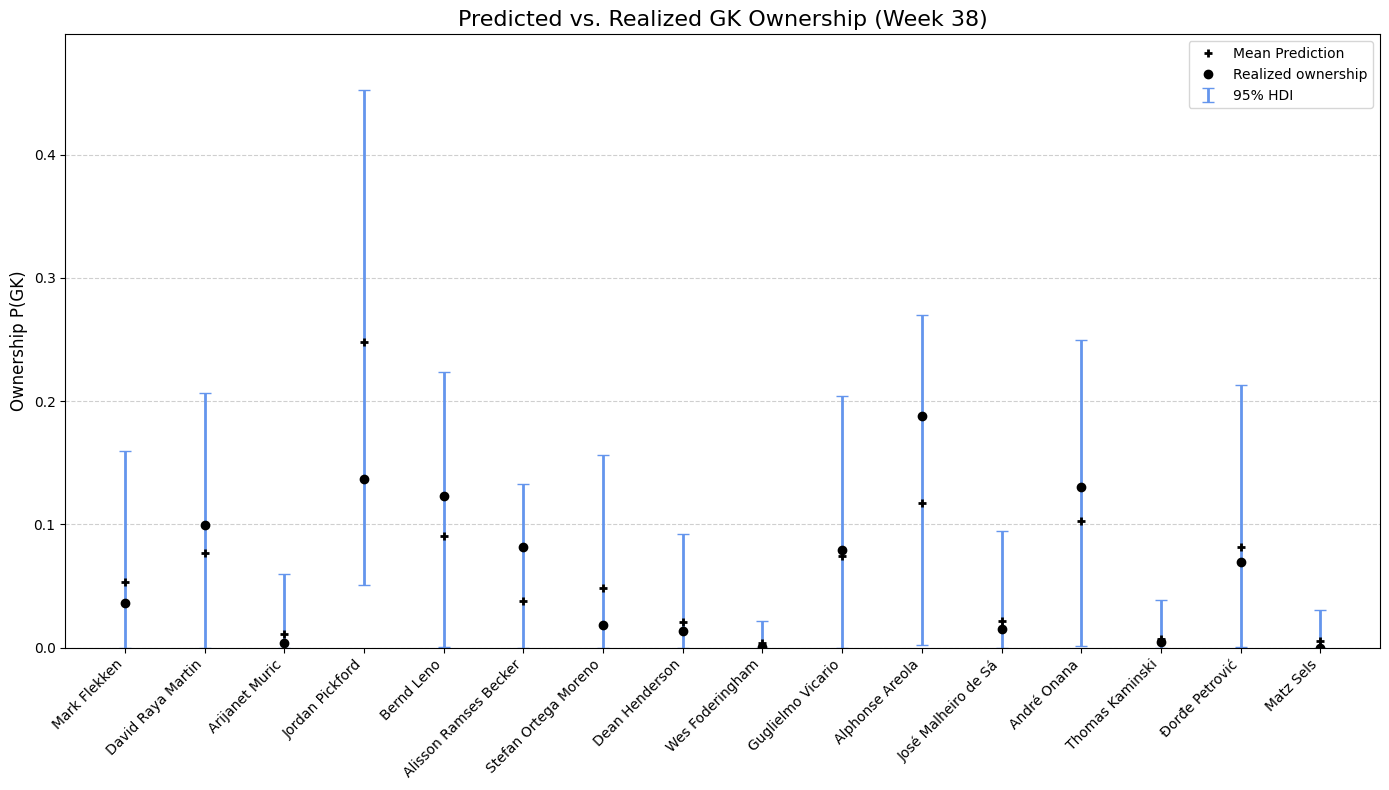

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_34.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_34,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_34,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_34,
    gk_probs_obs_34,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 34)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_34)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/521612348.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


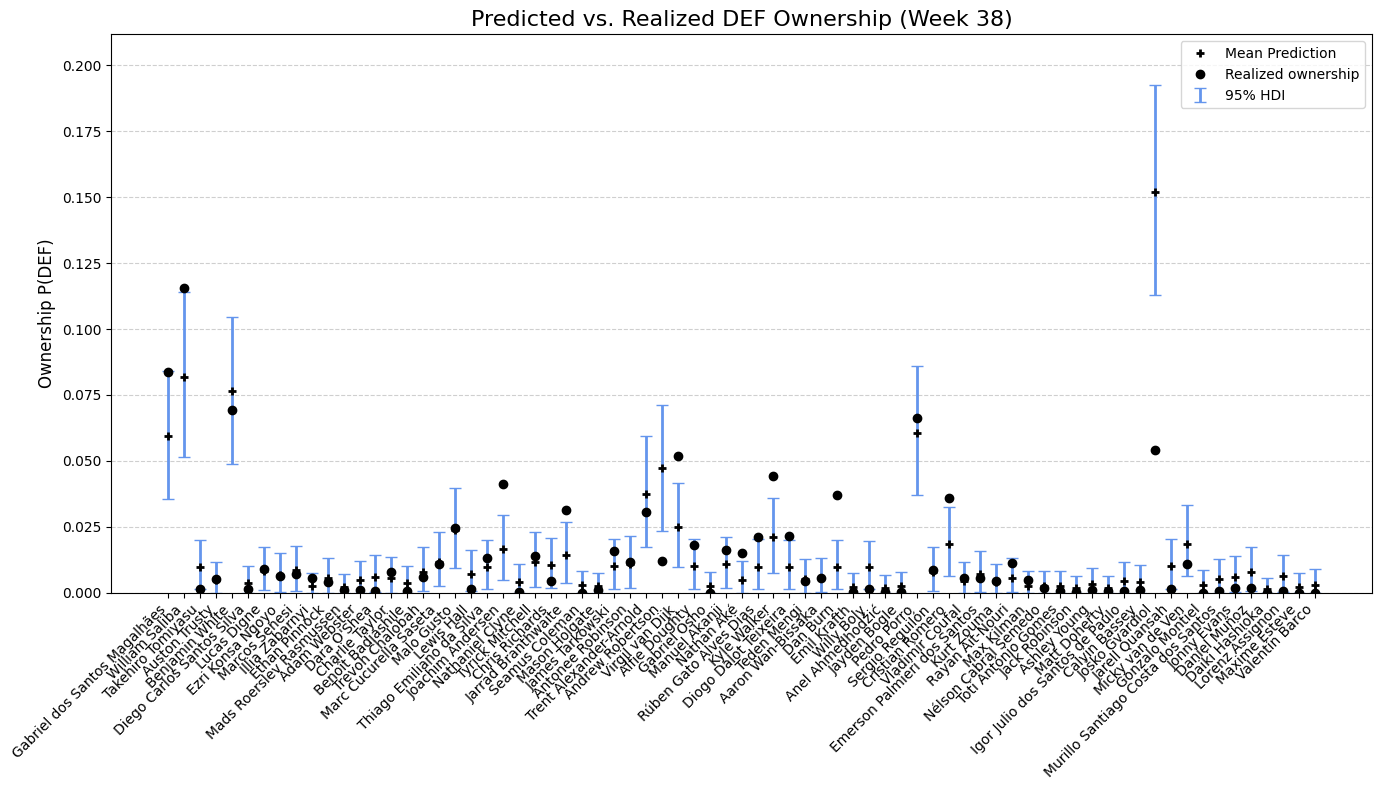

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_34.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_34,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_34,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_34,
    def_probs_obs_34,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 34)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_34)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/3999001716.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


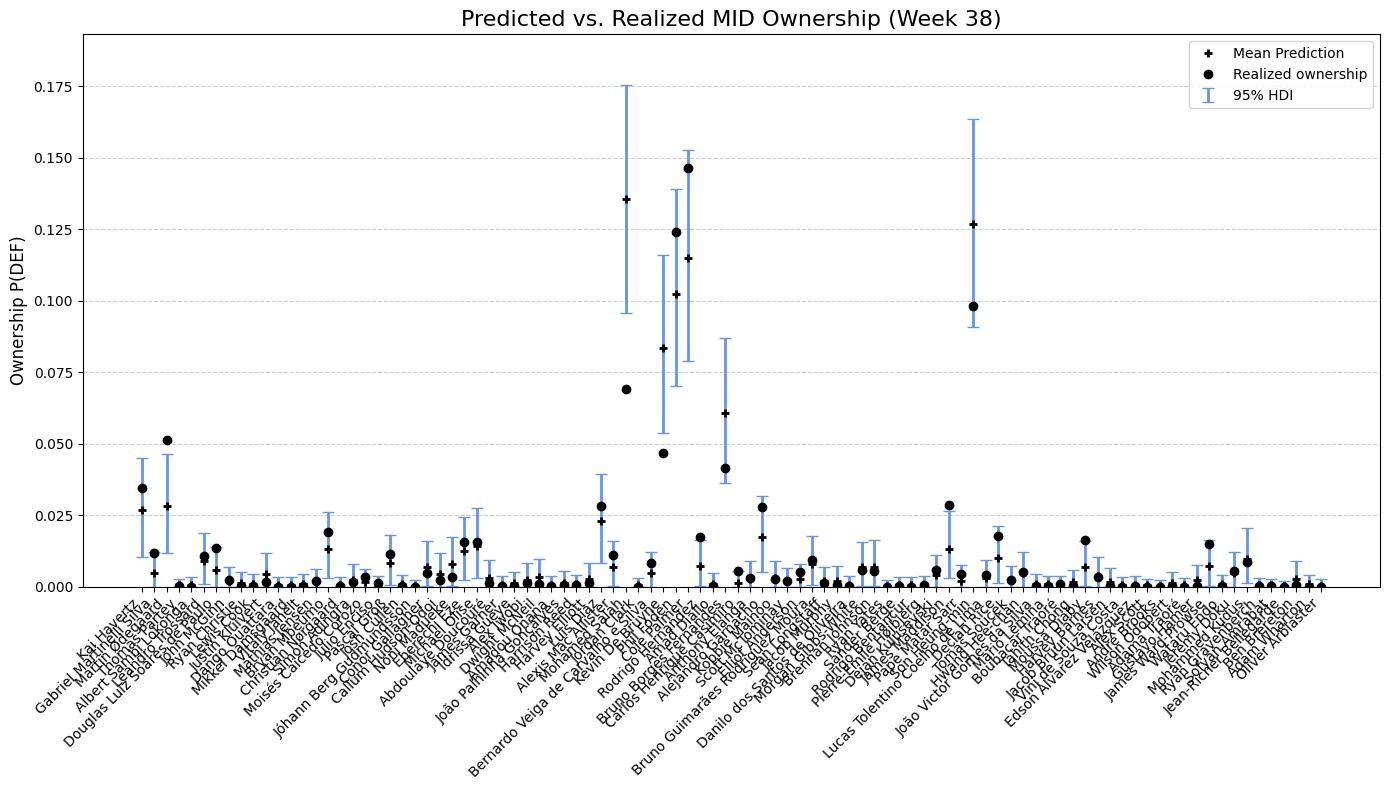

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_34.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_34,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_34,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_34,
    mid_probs_obs_34,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 34)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_34)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2541258746.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


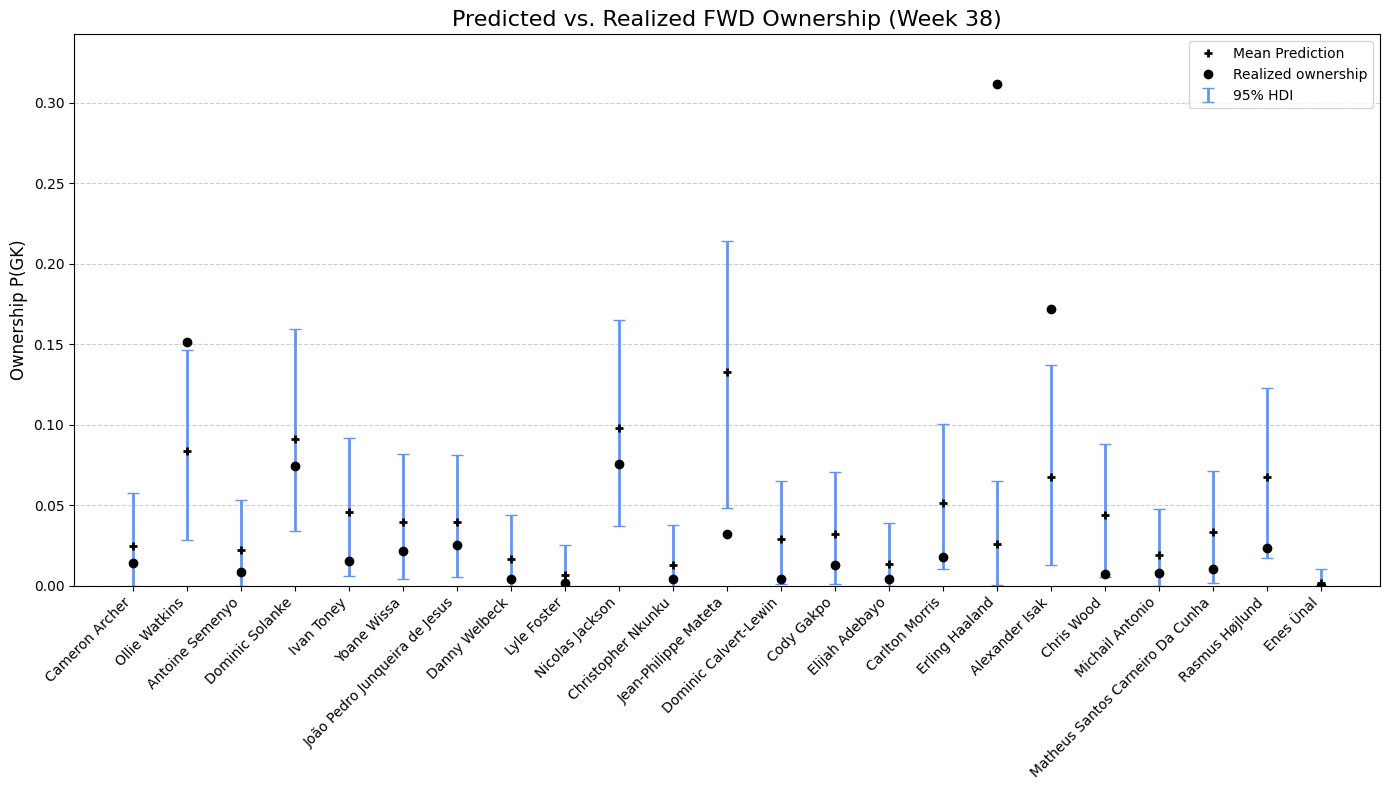

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_34.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_34,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_34,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_34,
    fwd_probs_obs_34,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 34)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_34)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios_34 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_34, X_def_34, X_mid_34, X_fwd_34],
    ids = ids_34,
    costs=players_preds_34['value'].tolist(),
    budget=84,
    teams=teams_34,
    xp_preds=xPts_34,
    p_vectors=p_vectors_34
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 20000 attempts...: 8
✅ Collected 0 valid teams after 30000 attempts...: 20
✅ Collected 0 valid teams after 40000 attempts...: 24
✅ Collected 0 valid teams after 50000 attempts...: 28
✅ Collected 0 valid teams after 60000 attempts...: 36
✅ Collected 0 valid teams after 70000 attempts...: 43
✅ Collected 0 valid teams after 80000 attempts...: 48
✅ Collected 0 valid teams after 90000 attempts...: 52
✅ Collected 0 valid teams after 100000 attempts...: 61
✅ Collected 0 valid teams after 110000 attempts...: 70
✅ Collected 0 valid teams after 120000 attempts...: 75
✅ Collected 0 valid teams after 130000 attempts...: 79
✅ Collected 0 valid teams after 140000 attempts...: 86
✅ Collected 0 valid teams after 150000 attempts...: 92
✅ Collected 0 valid teams after 160000 attempts...: 105
✅ Collected 0 valid teams after 170000 attempts..

In [ ]:
Wo_34 = []
for i in generated_portfolios_34:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_34['fpl_id'].index.tolist()])
    Wo_34.append(squad)

len(Wo_34)


500

In [ ]:

delta_sample_trace_34 = monte_carlo_simulation(Wo_34, mu_delta_34, cov_mat_34, sigma_delta_34)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_34 = az.summary(delta_sample_trace_34, var_names=["delta"], round_to=2)
summary_34


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_34 = delta_sample_trace_34.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_34, n_draws_34, n_players_34 = delta_raw_34.shape
delta_flattened_34 = delta_raw_34.reshape(n_chains_34 * n_draws_34, n_players_34)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_34 = np.dot(Wo_34, delta_flattened_34.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_34 = np.percentile(opponent_performances_34, 90, axis=0)

delta_samples_34 = delta_sample_trace_34.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_34 = np.percentile(Gr_samples_34, 90)  # shape (N_samples,)

mu_delta_34, cov_delta_34, mu_G_34, var_G_34, cov_delta_G_34, sigma_G_34 = generate_cov_delta(delta_flattened_34, Gr_samples_34)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_34, best_w_34, best_prob_34 = optimize_portfolio(add_fantasy_constraints, ids_34, prices_34, mu_delta_34, cov_delta_34, mu_G_34, var_G_34, cov_delta_G_34, lambdas, delta_samples_34, Gr_scalar_34, players_preds_34, 84)
print(f"Best λ: {best_lambda_34}, Best Probability of Outperforming: {best_prob_34}")

selected_34, player_names_34, total_points_34, team_cost_34, formation_34 = selected_info(best_w_34, fpl_teams_ids, players_preds_34, fg_managers_34)
print('fpl_ids: ', selected_34, '\nfpl_names: ', player_names_34, '\ntotal_points: ', total_points_34, '\nteam_cost: ', team_cost_34, '\nformation: ', formation_34)

players_preds_34[players_preds_34['fpl_id'].isin(selected_34)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_34[players_preds_34['fpl_id'].isin(selected_34)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_34 = players_preds_34[players_preds_34['fpl_id'].isin(selected_34)].copy()
# players_selected_34 = players_selected_34.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_34['xp_rank'] = players_selected_34['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_34['xp_rank'] == 1,  # Highest xp_preds
    players_selected_34['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_34['score'] = players_selected_34['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_34 = sum(players_selected_34['score'].values)
print(total_points_34, players_selected_34['xP'].values, '--------->', players_selected_34['xP_pred'].values)

players_selected_34[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_34 = fg_managers[fg_managers['gameweek'] == 34]
fg_managers_34[['points']]

position_34 = (fg_managers_34['points'] > total_points_34).sum() + 1

# 4. Display result
total_managers_34 = len(fg_managers_34)
percentile_34 = percentile_34 = 100 * (1 - (position_34 - 1) / total_managers_34)

print(total_points_34, total_managers_34)

print(f"Your predicted player’s total of {total_points_34} points would rank:")
print(f"→ Position: {position_34} out of {total_managers_34} managers")
print(f"→ Percentile: Top {percentile_34:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_34 = fg_managers_34.sort_values('points', ascending=False).reset_index(drop=True)

nearby_34 = fg_sorted_34.iloc[max(position_34-15, 0):position_34+2][['points','prize']]

player_prize_34 = fg_sorted_34.iloc[position_34 - 1]['prize']
if pd.isna(player_prize_34):
    player_prize_34 = "No prize"

print(f"→ Prize at position {position_34}: {player_prize_34}")
print("\nClosest scores around you:")
print(nearby_34)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# GW 35


## Generate Cov_Mat


In [ ]:
fg_managers_35  = fg_managers[fg_managers['gameweek'] == 35]
data_23_24_35 = data_23_24[data_23_24['event'] < 35]
players_preds_35 =  data_23_24[data_23_24['event'] == 35]

mu_delta_35, sigma_delta_35, cov_mat_35, valid_player_ids_35 = generate_cov_mat(players_preds_35, data_23_24_35)


Starting to optimize team selection...
(209, 343)
(4213, 343)
(208,) (208,) (208, 208)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_35 = data_23_24_35[data_23_24_35['fpl_id'].isin(valid_player_ids_35)].reset_index(drop=True)
players_preds_35 = players_preds_35[players_preds_35['fpl_id'].isin(valid_player_ids_35)].reset_index(drop=True)
data_35, prices_35, xPts_35, positions_35, teams_35, ids_35, X_35, names_35, probs_35 = clean_data(players_preds_35, valid_player_ids_35)

starting to clean data...
data successfully cleaned...


In [ ]:
X_gk_35 = X_35[0][gk_beta_feats]
X_def_35 = X_35[1][def_beta_feats]
X_mid_35 = X_35[2][mid_beta_feats]
X_fwd_35 = X_35[3][fwd_beta_feats]

alphas_35 = {
        'GK': np.exp(X_gk_35 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_35 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_35 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_35 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_35 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_35.items()}
p_vectors_35

{'GK': array([3.00208814e-02, 1.71939192e-01, 1.47058888e-05, 4.49238970e-01,
        3.26388875e-02, 2.10036576e-02, 1.09154367e-02, 3.01933277e-05,
        4.95578661e-14, 4.47398750e-02, 1.32397065e-01, 2.97637833e-05,
        6.49419689e-02, 1.31584225e-02, 2.83320948e-02, 5.98886065e-04]),
 'DEF': array([6.10437172e-02, 7.64903911e-02, 1.39219511e-02, 3.59394528e-03,
        9.07004761e-02, 8.08537646e-03, 5.91840244e-03, 7.27384624e-03,
        2.84847143e-03, 2.05138433e-03, 9.17303679e-03, 4.31166381e-04,
        7.35357179e-04, 1.12682052e-03, 4.38067750e-03, 3.08336115e-03,
        8.66477430e-03, 8.36724800e-03, 3.24672027e-02, 1.61723217e-02,
        4.08608582e-03, 9.33648567e-03, 2.29900132e-03, 3.35373666e-03,
        1.55686153e-02, 1.24428333e-02, 1.84022654e-03, 1.52225704e-03,
        1.35479286e-02, 1.27234778e-02, 3.35554438e-02, 3.50961609e-02,
        2.10929816e-02, 5.86194001e-03, 2.10834973e-04, 1.04134992e-02,
        9.33073945e-03, 1.25604889e-02, 2.8527235

## Plots


In [ ]:
gk_names_35 = names_35[0]
def_names_35 = names_35[1]
mid_names_35 = names_35[2]
fwd_names_35 = names_35[3]

gk_probs_obs_35 = probs_35[0]
def_probs_obs_35 = probs_35[1]
mid_probs_obs_35 = probs_35[2]
fwd_probs_obs_35 = probs_35[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2517278040.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


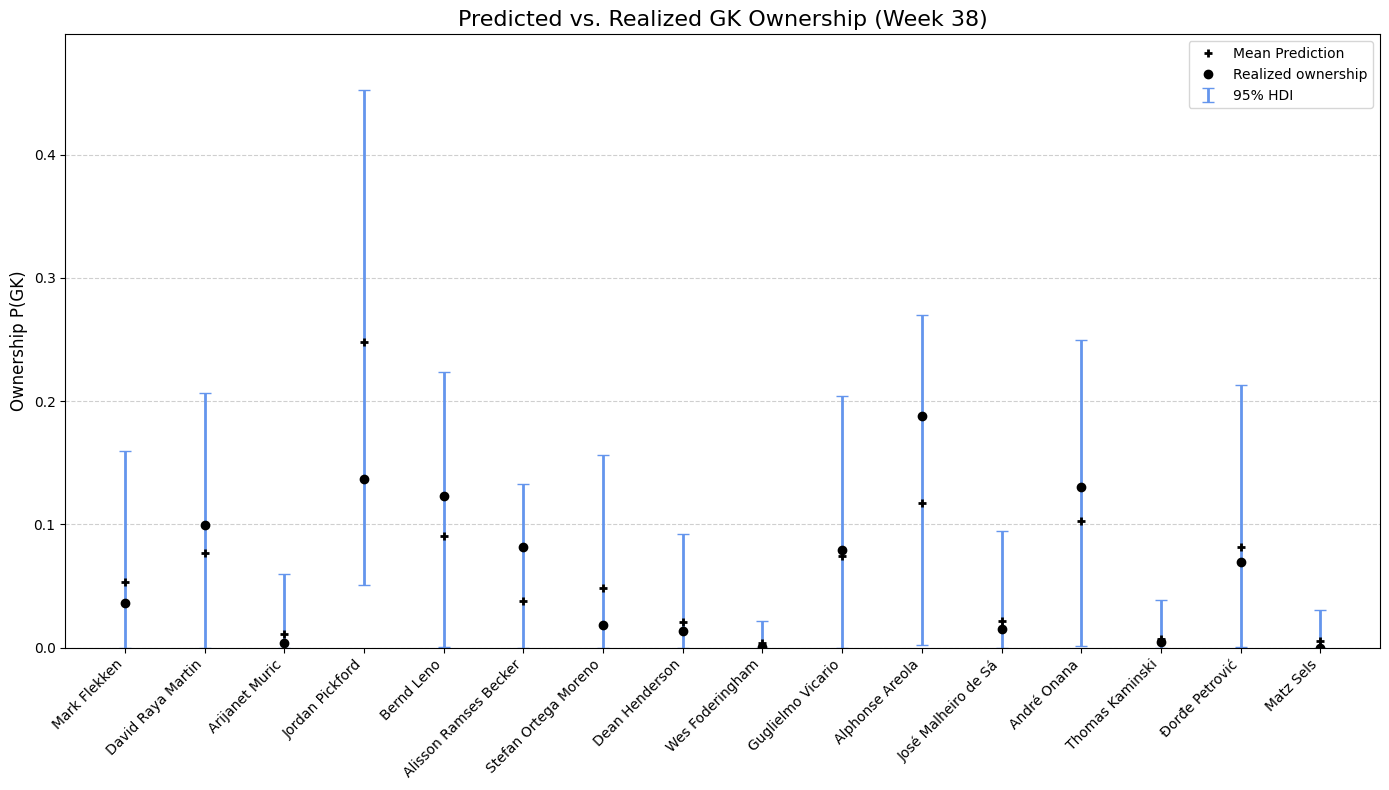

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_35.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_35,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_35,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_35,
    gk_probs_obs_35,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 35)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_35)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/521612348.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


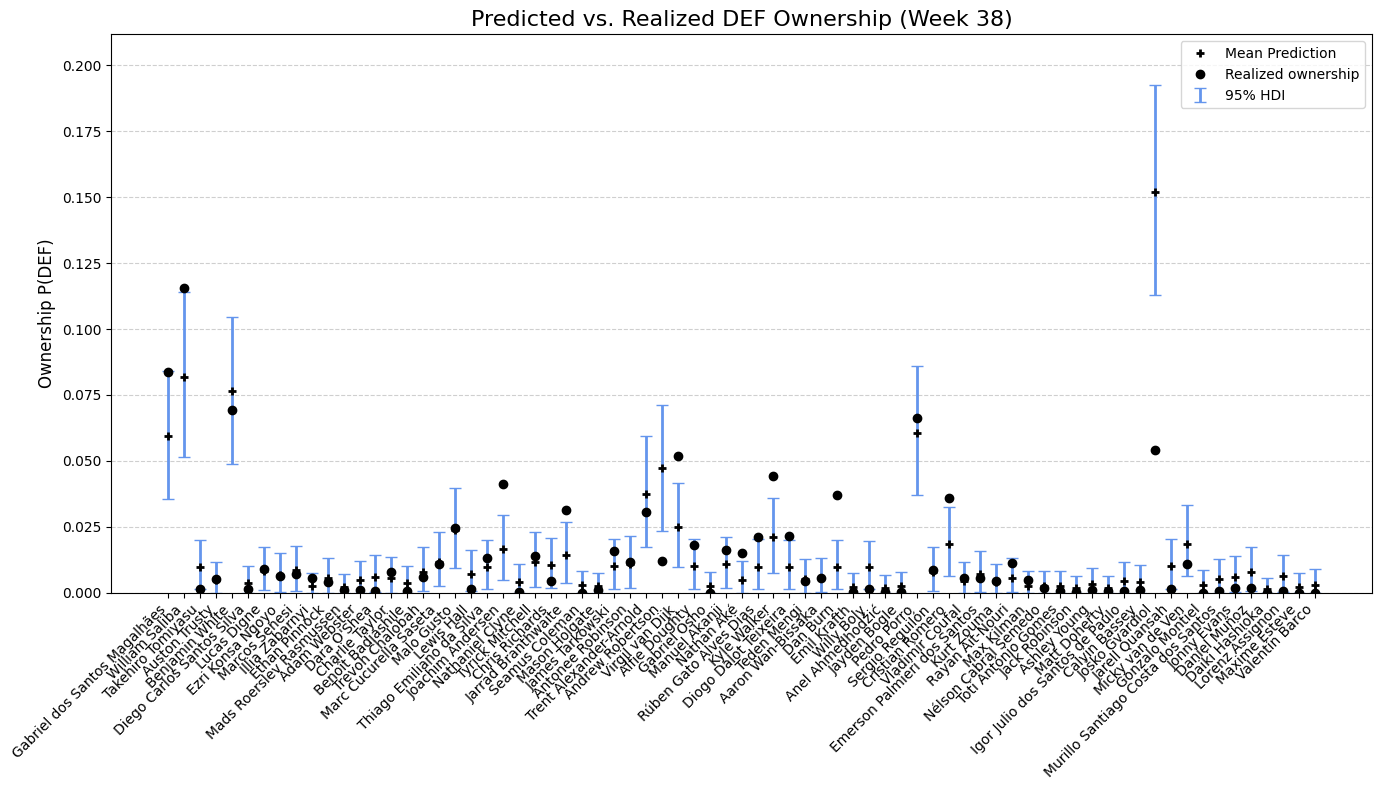

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_35.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_35,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_35,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_35,
    def_probs_obs_35,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 35)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_35)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/3999001716.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


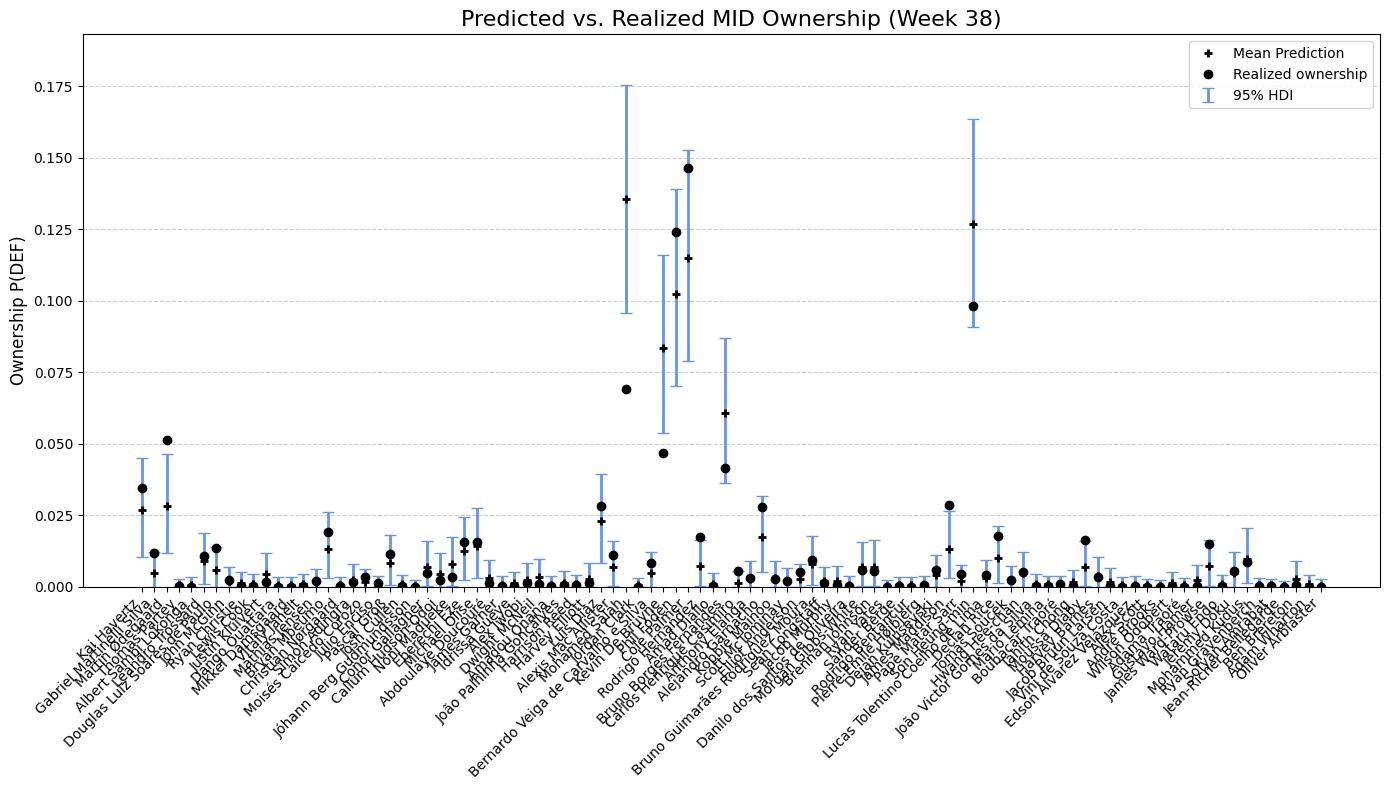

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_35.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_35,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_35,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_35,
    mid_probs_obs_35,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 35)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_35)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2541258746.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


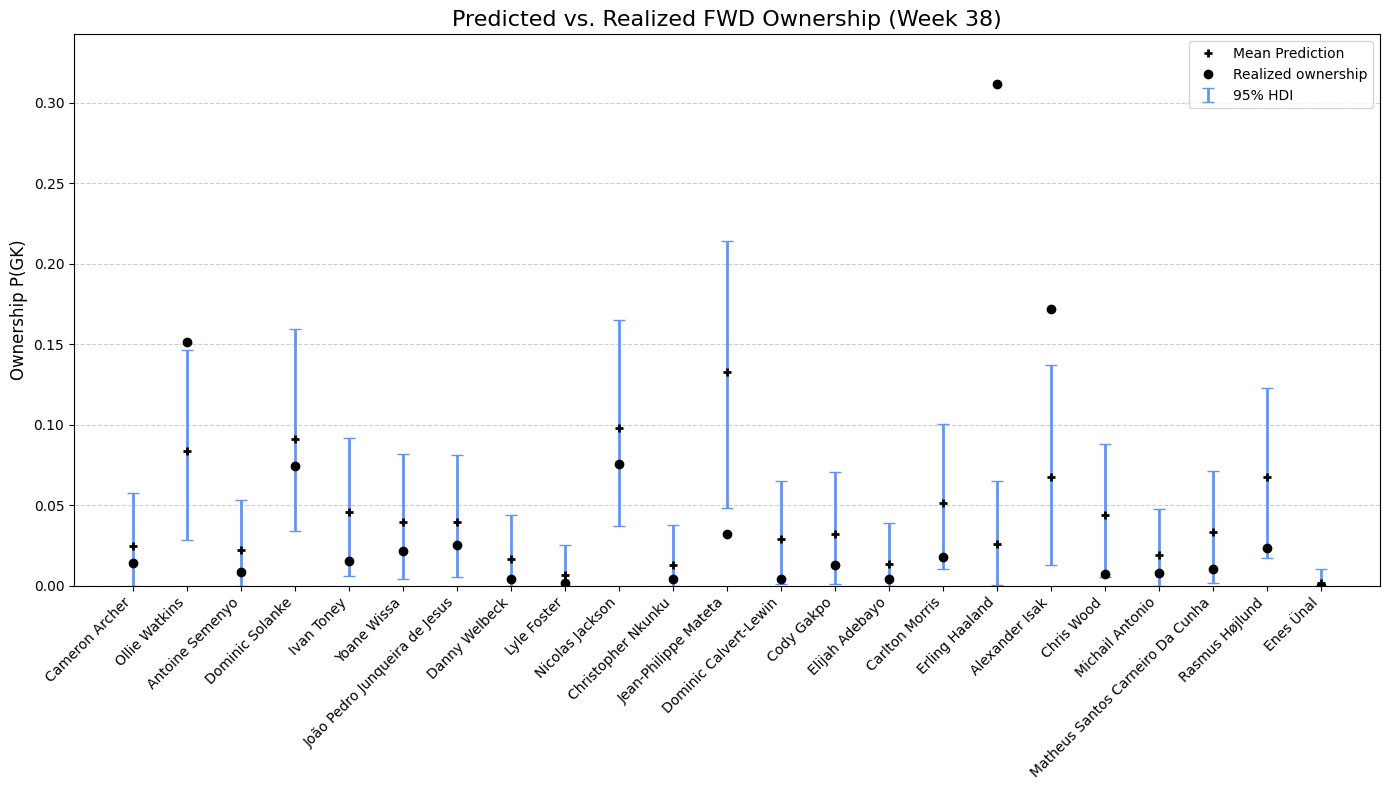

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_35.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_35,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_35,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_35,
    fwd_probs_obs_35,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 35)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_35)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios_35 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_35, X_def_35, X_mid_35, X_fwd_35],
    ids = ids_35,
    costs=players_preds_35['value'].tolist(),
    budget=84,
    teams=teams_35,
    xp_preds=xPts_35,
    p_vectors=p_vectors_35
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 20000 attempts...: 8
✅ Collected 0 valid teams after 30000 attempts...: 20
✅ Collected 0 valid teams after 40000 attempts...: 24
✅ Collected 0 valid teams after 50000 attempts...: 28
✅ Collected 0 valid teams after 60000 attempts...: 36
✅ Collected 0 valid teams after 70000 attempts...: 43
✅ Collected 0 valid teams after 80000 attempts...: 48
✅ Collected 0 valid teams after 90000 attempts...: 52
✅ Collected 0 valid teams after 100000 attempts...: 61
✅ Collected 0 valid teams after 110000 attempts...: 70
✅ Collected 0 valid teams after 120000 attempts...: 75
✅ Collected 0 valid teams after 130000 attempts...: 79
✅ Collected 0 valid teams after 140000 attempts...: 86
✅ Collected 0 valid teams after 150000 attempts...: 92
✅ Collected 0 valid teams after 160000 attempts...: 105
✅ Collected 0 valid teams after 170000 attempts..

In [ ]:
Wo_35 = []
for i in generated_portfolios_35:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_35['fpl_id'].index.tolist()])
    Wo_35.append(squad)

len(Wo_35)


500

In [ ]:

delta_sample_trace_35 = monte_carlo_simulation(Wo_35, mu_delta_35, cov_mat_35, sigma_delta_35)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_35 = az.summary(delta_sample_trace_35, var_names=["delta"], round_to=2)
summary_35


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_35 = delta_sample_trace_35.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_35, n_draws_35, n_players_35 = delta_raw_35.shape
delta_flattened_35 = delta_raw_35.reshape(n_chains_35 * n_draws_35, n_players_35)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_35 = np.dot(Wo_35, delta_flattened_35.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_35 = np.percentile(opponent_performances_35, 90, axis=0)

delta_samples_35 = delta_sample_trace_35.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_35 = np.percentile(Gr_samples_35, 90)  # shape (N_samples,)

mu_delta_35, cov_delta_35, mu_G_35, var_G_35, cov_delta_G_35, sigma_G_35 = generate_cov_delta(delta_flattened_35, Gr_samples_35)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_35, best_w_35, best_prob_35 = optimize_portfolio(add_fantasy_constraints, ids_35, prices_35, mu_delta_35, cov_delta_35, mu_G_35, var_G_35, cov_delta_G_35, lambdas, delta_samples_35, Gr_scalar_35, players_preds_35, 84)
print(f"Best λ: {best_lambda_35}, Best Probability of Outperforming: {best_prob_35}")

selected_35, player_names_35, total_points_35, team_cost_35, formation_35 = selected_info(best_w_35, fpl_teams_ids, players_preds_35, fg_managers_35)
print('fpl_ids: ', selected_35, '\nfpl_names: ', player_names_35, '\ntotal_points: ', total_points_35, '\nteam_cost: ', team_cost_35, '\nformation: ', formation_35)

players_preds_35[players_preds_35['fpl_id'].isin(selected_35)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_35[players_preds_35['fpl_id'].isin(selected_35)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_35 = players_preds_35[players_preds_35['fpl_id'].isin(selected_35)].copy()
# players_selected_35 = players_selected_35.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_35['xp_rank'] = players_selected_35['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_35['xp_rank'] == 1,  # Highest xp_preds
    players_selected_35['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_35['score'] = players_selected_35['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_35 = sum(players_selected_35['score'].values)
print(total_points_35, players_selected_35['xP'].values, '--------->', players_selected_35['xP_pred'].values)

players_selected_35[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_35 = fg_managers[fg_managers['gameweek'] == 35]
fg_managers_35[['points']]

position_35 = (fg_managers_35['points'] > total_points_35).sum() + 1

# 4. Display result
total_managers_35 = len(fg_managers_35)
percentile_35 = percentile_34 = 100 * (1 - (position_35 - 1) / total_managers_35)

print(total_points_35, total_managers_35)

print(f"Your predicted player’s total of {total_points_35} points would rank:")
print(f"→ Position: {position_35} out of {total_managers_35} managers")
print(f"→ Percentile: Top {percentile_35:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_35 = fg_managers_35.sort_values('points', ascending=False).reset_index(drop=True)

nearby_35 = fg_sorted_35.iloc[max(position_35-15, 0):position_35+2][['points','prize']]

player_prize_35 = fg_sorted_35.iloc[position_35 - 1]['prize']
if pd.isna(player_prize_35):
    player_prize_35 = "No prize"

print(f"→ Prize at position {position_35}: {player_prize_35}")
print("\nClosest scores around you:")
print(nearby_35)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# GW 36


## Generate Cov_Mat


In [ ]:
fg_managers_36  = fg_managers[fg_managers['gameweek'] == 36]
data_23_24_36 = data_23_24[data_23_24['event'] < 36]
players_preds_36 =  data_23_24[data_23_24['event'] == 36]

mu_delta_36, sigma_delta_36, cov_mat_36, valid_player_ids_36 = generate_cov_mat(players_preds_36, data_23_24_36)


Starting to optimize team selection...
(209, 343)
(4213, 343)
(208,) (208,) (208, 208)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids_36)].reset_index(drop=True)
players_preds_36 = players_preds_36[players_preds_36['fpl_id'].isin(valid_player_ids_36)].reset_index(drop=True)
data_36, prices_36, xPts_36, positions_36, teams_36, ids_36, X_36, names_36, probs_36 = clean_data(players_preds_36, valid_player_ids_36)

starting to clean data...
data successfully cleaned...


In [ ]:
X_gk_36 = X_36[0][gk_beta_feats]
X_def_36 = X_36[1][def_beta_feats]
X_mid_36 = X_36[2][mid_beta_feats]
X_fwd_36 = X_36[3][fwd_beta_feats]

alphas_36 = {
        'GK': np.exp(X_gk_36 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_36 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_36 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_36 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_36 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_36.items()}
p_vectors_36

{'GK': array([3.00208814e-02, 1.71939192e-01, 1.47058888e-05, 4.49238970e-01,
        3.26388875e-02, 2.10036576e-02, 1.09154367e-02, 3.01933277e-05,
        4.95578661e-14, 4.47398750e-02, 1.32397065e-01, 2.97637833e-05,
        6.49419689e-02, 1.31584225e-02, 2.83320948e-02, 5.98886065e-04]),
 'DEF': array([6.10437172e-02, 7.64903911e-02, 1.39219511e-02, 3.59394528e-03,
        9.07004761e-02, 8.08537646e-03, 5.91840244e-03, 7.27384624e-03,
        2.84847143e-03, 2.05138433e-03, 9.17303679e-03, 4.31166381e-04,
        7.35357179e-04, 1.12682052e-03, 4.38067750e-03, 3.08336115e-03,
        8.66477430e-03, 8.36724800e-03, 3.24672027e-02, 1.61723217e-02,
        4.08608582e-03, 9.33648567e-03, 2.29900132e-03, 3.35373666e-03,
        1.55686153e-02, 1.24428333e-02, 1.84022654e-03, 1.52225704e-03,
        1.35479286e-02, 1.27234778e-02, 3.35554438e-02, 3.50961609e-02,
        2.10929816e-02, 5.86194001e-03, 2.10834973e-04, 1.04134992e-02,
        9.33073945e-03, 1.25604889e-02, 2.8527235

## Plots


In [ ]:
gk_names_36 = names_36[0]
def_names_36 = names_36[1]
mid_names_36 = names_36[2]
fwd_names_36 = names_36[3]

gk_probs_obs_36 = probs_36[0]
def_probs_obs_36 = probs_36[1]
mid_probs_obs_36 = probs_36[2]
fwd_probs_obs_36 = probs_36[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2517278040.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


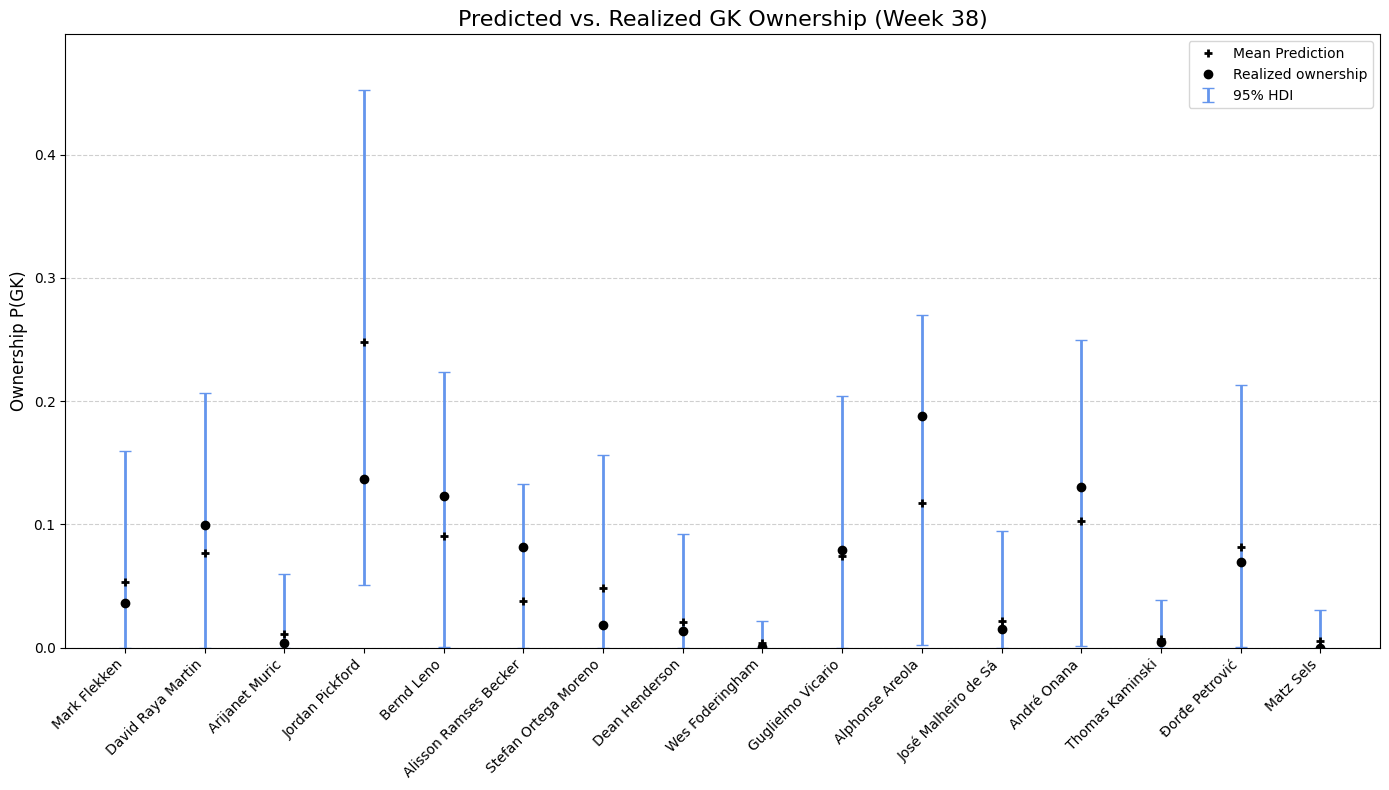

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_36.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_36,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_36,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_36,
    gk_probs_obs_36,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_36)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/521612348.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


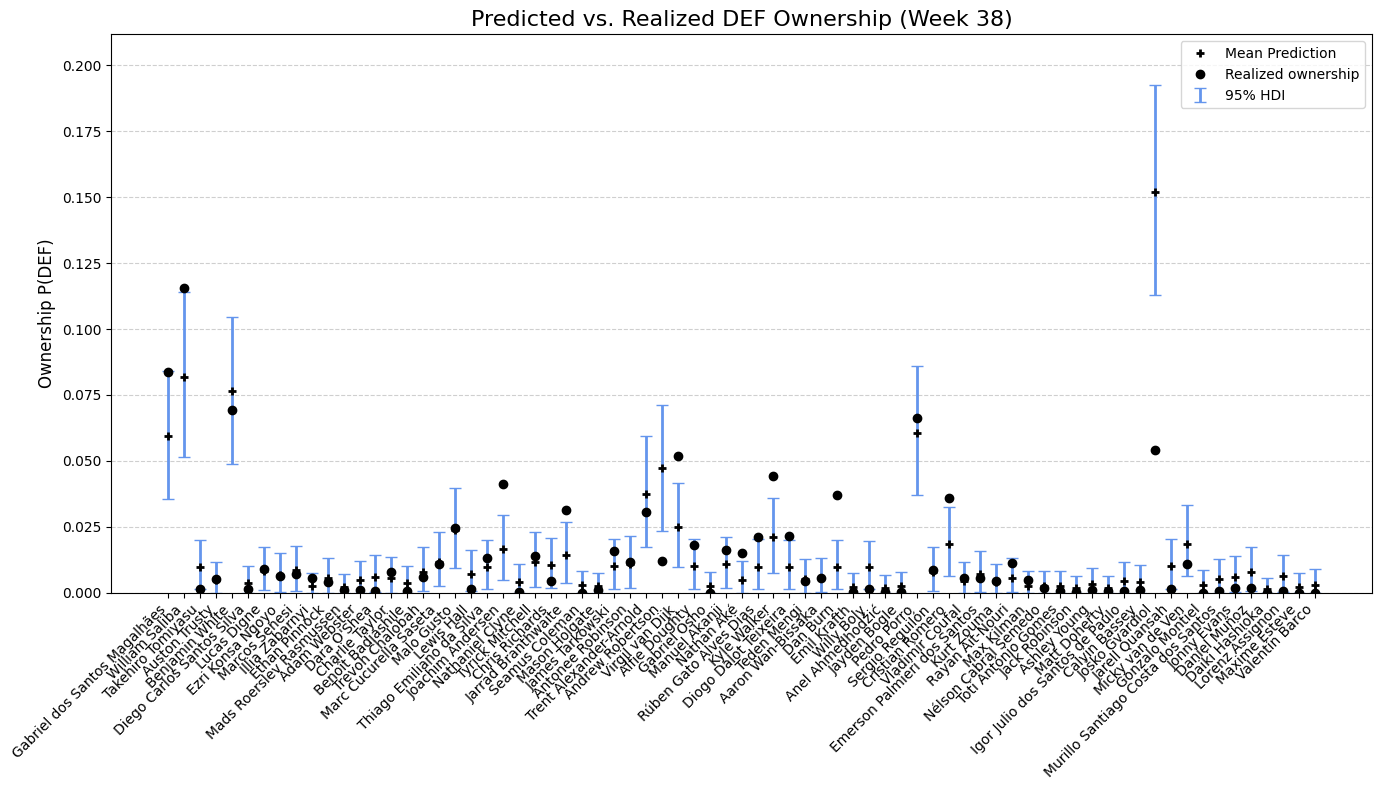

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_36.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_36,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_36,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_36,
    def_probs_obs_36,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_36)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/3999001716.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


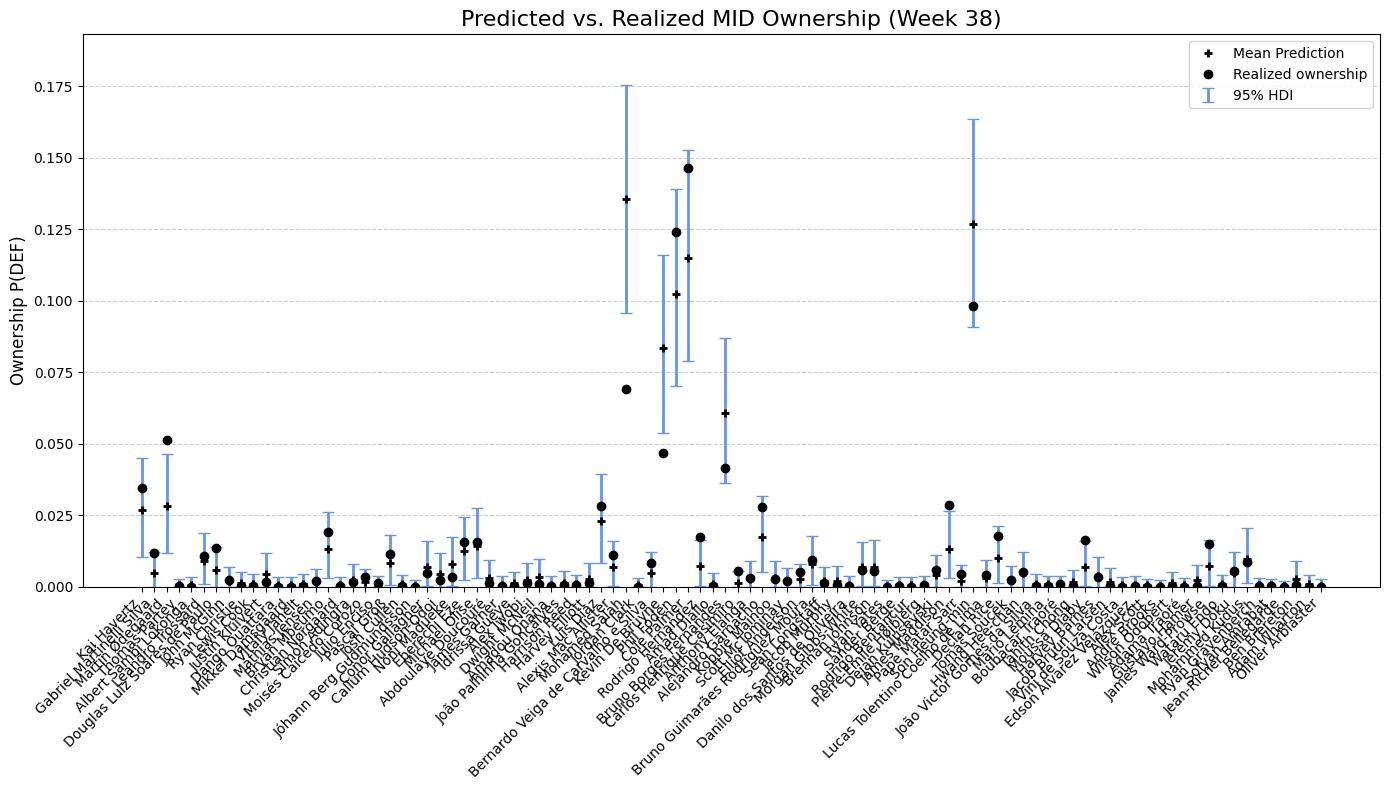

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_36.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_36,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_36,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_36,
    mid_probs_obs_36,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_36)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2541258746.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


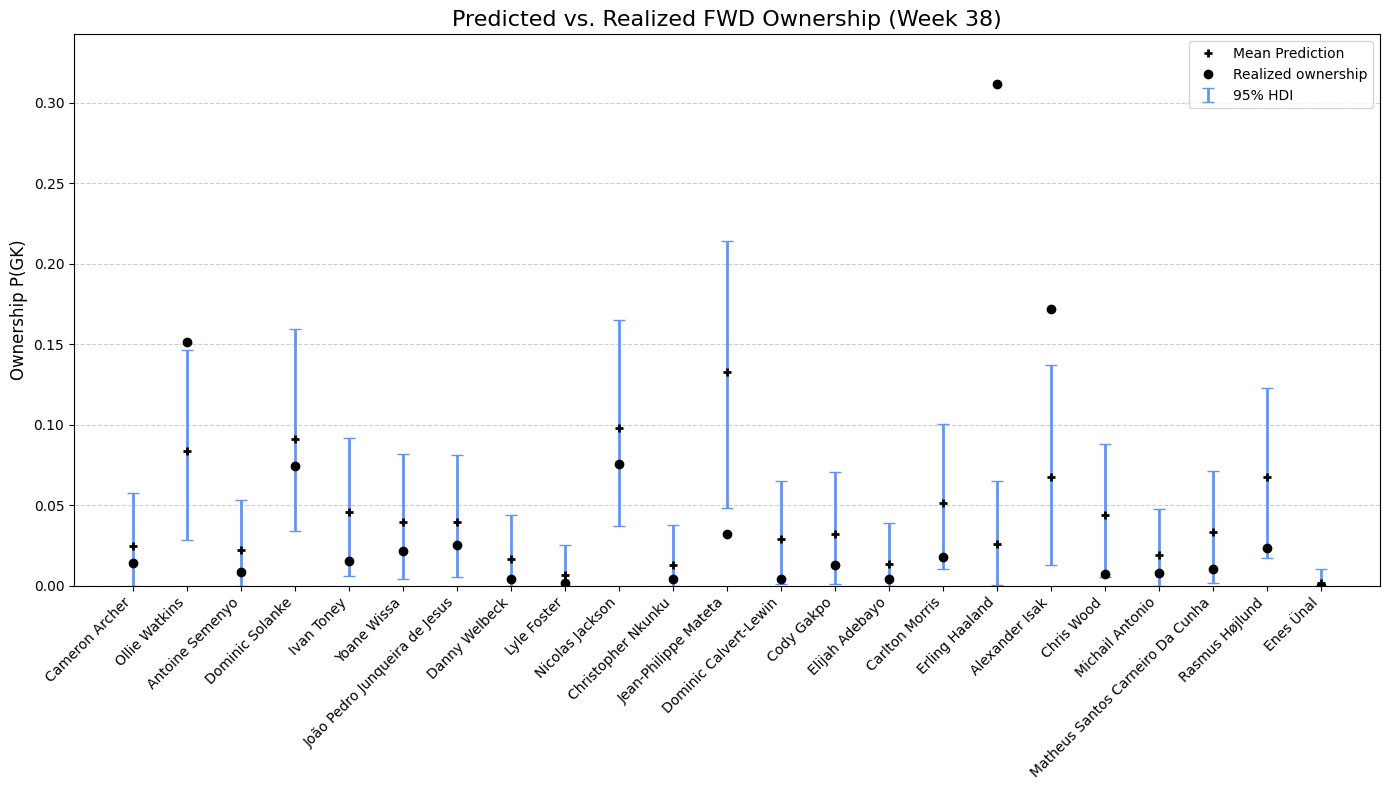

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_36.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_36,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_36,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_36,
    fwd_probs_obs_36,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_36)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios_36 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_36, X_def_36, X_mid_36, X_fwd_36],
    ids = ids_36,
    costs=players_preds_36['value'].tolist(),
    budget=84,
    teams=teams_36,
    xp_preds=xPts_36,
    p_vectors=p_vectors_36
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 20000 attempts...: 8
✅ Collected 0 valid teams after 30000 attempts...: 20
✅ Collected 0 valid teams after 40000 attempts...: 24
✅ Collected 0 valid teams after 50000 attempts...: 28
✅ Collected 0 valid teams after 60000 attempts...: 36
✅ Collected 0 valid teams after 70000 attempts...: 43
✅ Collected 0 valid teams after 80000 attempts...: 48
✅ Collected 0 valid teams after 90000 attempts...: 52
✅ Collected 0 valid teams after 100000 attempts...: 61
✅ Collected 0 valid teams after 110000 attempts...: 70
✅ Collected 0 valid teams after 120000 attempts...: 75
✅ Collected 0 valid teams after 130000 attempts...: 79
✅ Collected 0 valid teams after 140000 attempts...: 86
✅ Collected 0 valid teams after 150000 attempts...: 92
✅ Collected 0 valid teams after 160000 attempts...: 105
✅ Collected 0 valid teams after 170000 attempts..

In [ ]:
Wo_36 = []
for i in generated_portfolios_36:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_36['fpl_id'].index.tolist()])
    Wo_36.append(squad)

len(Wo_36)


500

In [ ]:

delta_sample_trace_36 = monte_carlo_simulation(Wo_36, mu_delta_36, cov_mat_36, sigma_delta_36)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_36 = az.summary(delta_sample_trace_36, var_names=["delta"], round_to=2)
summary_36


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_36 = delta_sample_trace_36.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_36, n_draws_36, n_players_36 = delta_raw_36.shape
delta_flattened_36 = delta_raw_36.reshape(n_chains_36 * n_draws_36, n_players_36)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_36 = np.dot(Wo_36, delta_flattened_36.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_36 = np.percentile(opponent_performances_36, 90, axis=0)

delta_samples_36 = delta_sample_trace_36.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_36 = np.percentile(Gr_samples_36, 90)  # shape (N_samples,)

mu_delta_36, cov_delta_36, mu_G_36, var_G_36, cov_delta_G_36, sigma_G_36 = generate_cov_delta(delta_flattened_36, Gr_samples_36)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_36, best_w_36, best_prob_36 = optimize_portfolio(add_fantasy_constraints, ids_36, prices_36, mu_delta_36, cov_delta_36, mu_G_36, var_G_36, cov_delta_G_36, lambdas, delta_samples_36, Gr_scalar_36, players_preds_36, 84)
print(f"Best λ: {best_lambda_36}, Best Probability of Outperforming: {best_prob_36}")

selected_36, player_names_36, total_points_36, team_cost_36, formation_36 = selected_info(best_w_36, fpl_teams_ids, players_preds_36, fg_managers_36)
print('fpl_ids: ', selected_36, '\nfpl_names: ', player_names_36, '\ntotal_points: ', total_points_36, '\nteam_cost: ', team_cost_36, '\nformation: ', formation_36)

players_preds_36[players_preds_36['fpl_id'].isin(selected_36)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_36[players_preds_36['fpl_id'].isin(selected_36)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_36 = players_preds_36[players_preds_36['fpl_id'].isin(selected_36)].copy()
# players_selected_36 = players_selected_36.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_36['xp_rank'] = players_selected_36['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_36['xp_rank'] == 1,  # Highest xp_preds
    players_selected_36['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_36['score'] = players_selected_36['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_36 = sum(players_selected_36['score'].values)
print(total_points_36, players_selected_36['xP'].values, '--------->', players_selected_36['xP_pred'].values)

players_selected_36[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_36 = fg_managers[fg_managers['gameweek'] == 36]
fg_managers_36[['points']]

position_36 = (fg_managers_36['points'] > total_points_36).sum() + 1

# 4. Display result
total_managers_36 = len(fg_managers_36)
percentile_36 = percentile_34 = 100 * (1 - (position_36 - 1) / total_managers_36)

print(total_points_36, total_managers_36)

print(f"Your predicted player’s total of {total_points_36} points would rank:")
print(f"→ Position: {position_36} out of {total_managers_36} managers")
print(f"→ Percentile: Top {percentile_36:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_36 = fg_managers_36.sort_values('points', ascending=False).reset_index(drop=True)

nearby_36 = fg_sorted_36.iloc[max(position_36-15, 0):position_36+2][['points','prize']]

player_prize_36 = fg_sorted_36.iloc[position_36 - 1]['prize']
if pd.isna(player_prize_36):
    player_prize_36 = "No prize"

print(f"→ Prize at position {position_36}: {player_prize_36}")
print("\nClosest scores around you:")
print(nearby_36)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# GW 37


## Generate Cov_Mat


In [ ]:
fg_managers_37  = fg_managers[fg_managers['gameweek'] == 37]
data_23_24_37 = data_23_24[data_23_24['event'] < 37]
players_preds_37 =  data_23_24[data_23_24['event'] == 37]

mu_delta_37, sigma_delta_37, cov_mat_37, valid_player_ids_37 = generate_cov_mat(players_preds_37, data_23_24_37)


Starting to optimize team selection...
(209, 343)
(4213, 343)
(208,) (208,) (208, 208)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_37 = data_23_24_37[data_23_24_37['fpl_id'].isin(valid_player_ids_37)].reset_index(drop=True)
players_preds_37 = players_preds_37[players_preds_37['fpl_id'].isin(valid_player_ids_37)].reset_index(drop=True)
data_37, prices_37, xPts_37, positions_37, teams_37, ids_37, X_37, names_37, probs_37 = clean_data(players_preds_37, valid_player_ids_37)

starting to clean data...
data successfully cleaned...


In [ ]:
X_gk_37 = X_37[0][gk_beta_feats]
X_def_37 = X_37[1][def_beta_feats]
X_mid_37 = X_37[2][mid_beta_feats]
X_fwd_37 = X_37[3][fwd_beta_feats]

alphas_37 = {
        'GK': np.exp(X_gk_37 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_37 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_37 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_37 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_37 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_37.items()}
p_vectors_37

{'GK': array([3.00208814e-02, 1.71939192e-01, 1.47058888e-05, 4.49238970e-01,
        3.26388875e-02, 2.10036576e-02, 1.09154367e-02, 3.01933277e-05,
        4.95578661e-14, 4.47398750e-02, 1.32397065e-01, 2.97637833e-05,
        6.49419689e-02, 1.31584225e-02, 2.83320948e-02, 5.98886065e-04]),
 'DEF': array([6.10437172e-02, 7.64903911e-02, 1.39219511e-02, 3.59394528e-03,
        9.07004761e-02, 8.08537646e-03, 5.91840244e-03, 7.27384624e-03,
        2.84847143e-03, 2.05138433e-03, 9.17303679e-03, 4.31166381e-04,
        7.35357179e-04, 1.12682052e-03, 4.38067750e-03, 3.08336115e-03,
        8.66477430e-03, 8.36724800e-03, 3.24672027e-02, 1.61723217e-02,
        4.08608582e-03, 9.33648567e-03, 2.29900132e-03, 3.35373666e-03,
        1.55686153e-02, 1.24428333e-02, 1.84022654e-03, 1.52225704e-03,
        1.35479286e-02, 1.27234778e-02, 3.35554438e-02, 3.50961609e-02,
        2.10929816e-02, 5.86194001e-03, 2.10834973e-04, 1.04134992e-02,
        9.33073945e-03, 1.25604889e-02, 2.8527235

## Plots


In [ ]:
gk_names_37 = names_37[0]
def_names_37 = names_37[1]
mid_names_37 = names_37[2]
fwd_names_37 = names_37[3]

gk_probs_obs_37 = probs_37[0]
def_probs_obs_37 = probs_37[1]
mid_probs_obs_37 = probs_37[2]
fwd_probs_obs_37 = probs_37[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2517278040.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


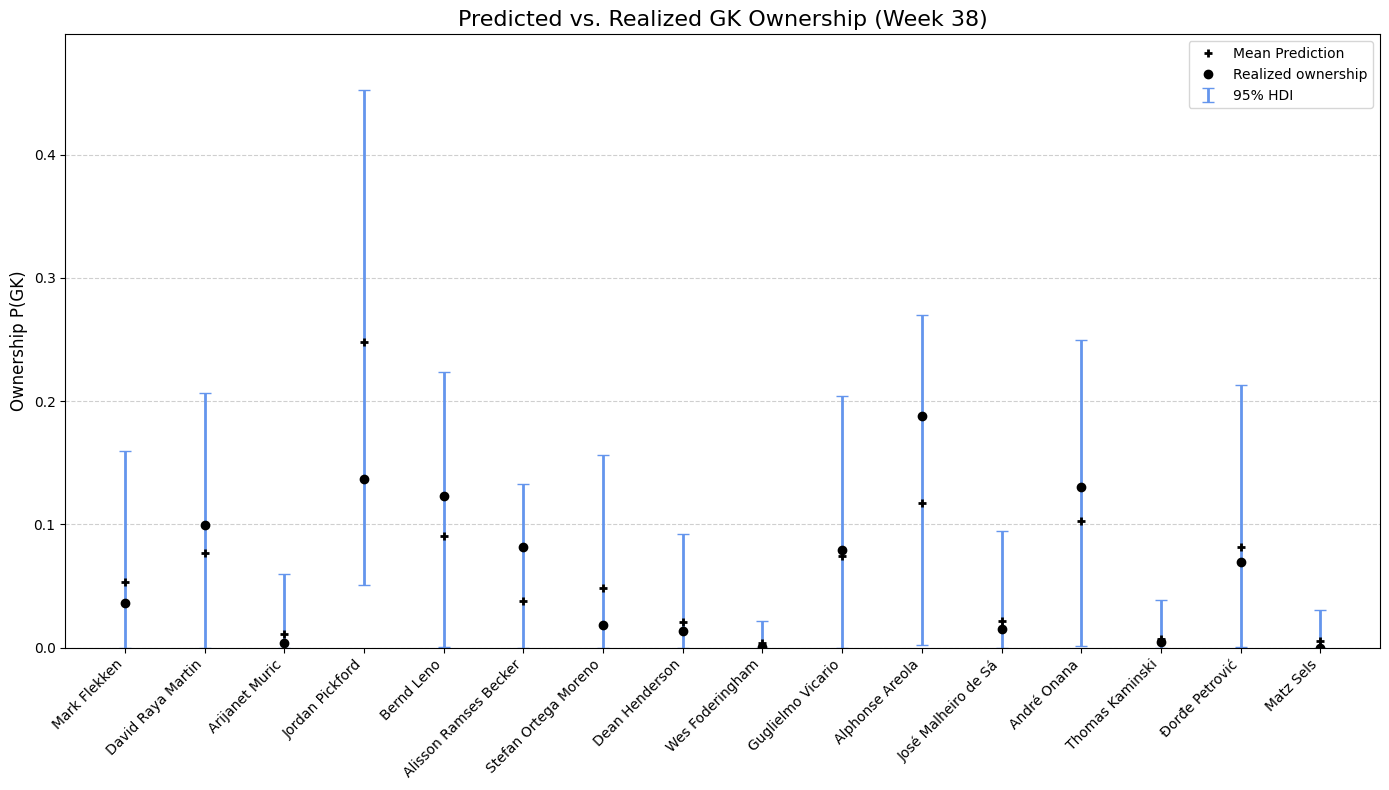

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_37.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_37,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_37,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_37,
    gk_probs_obs_37,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_37)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/521612348.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


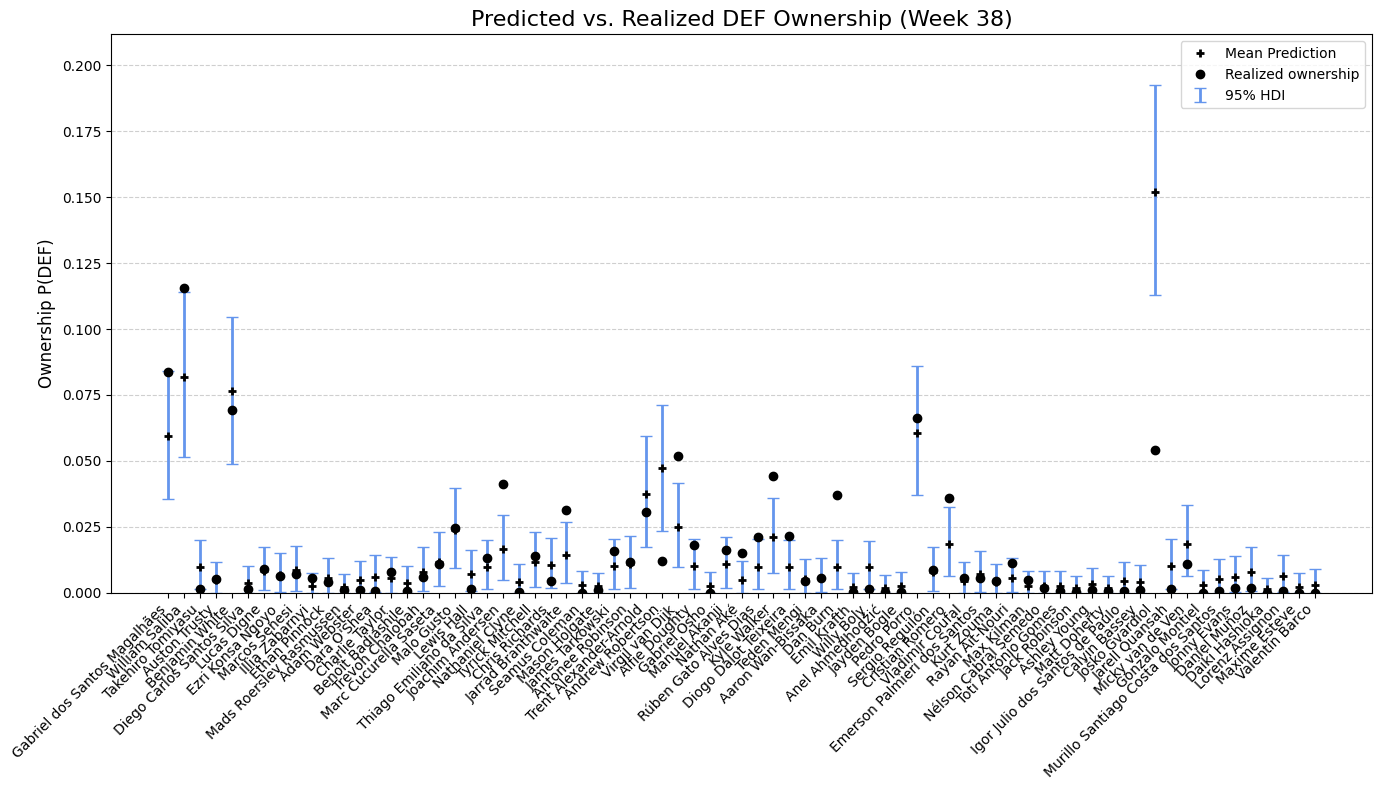

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_37.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_37,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_37,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_37,
    def_probs_obs_37,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_37)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/3999001716.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


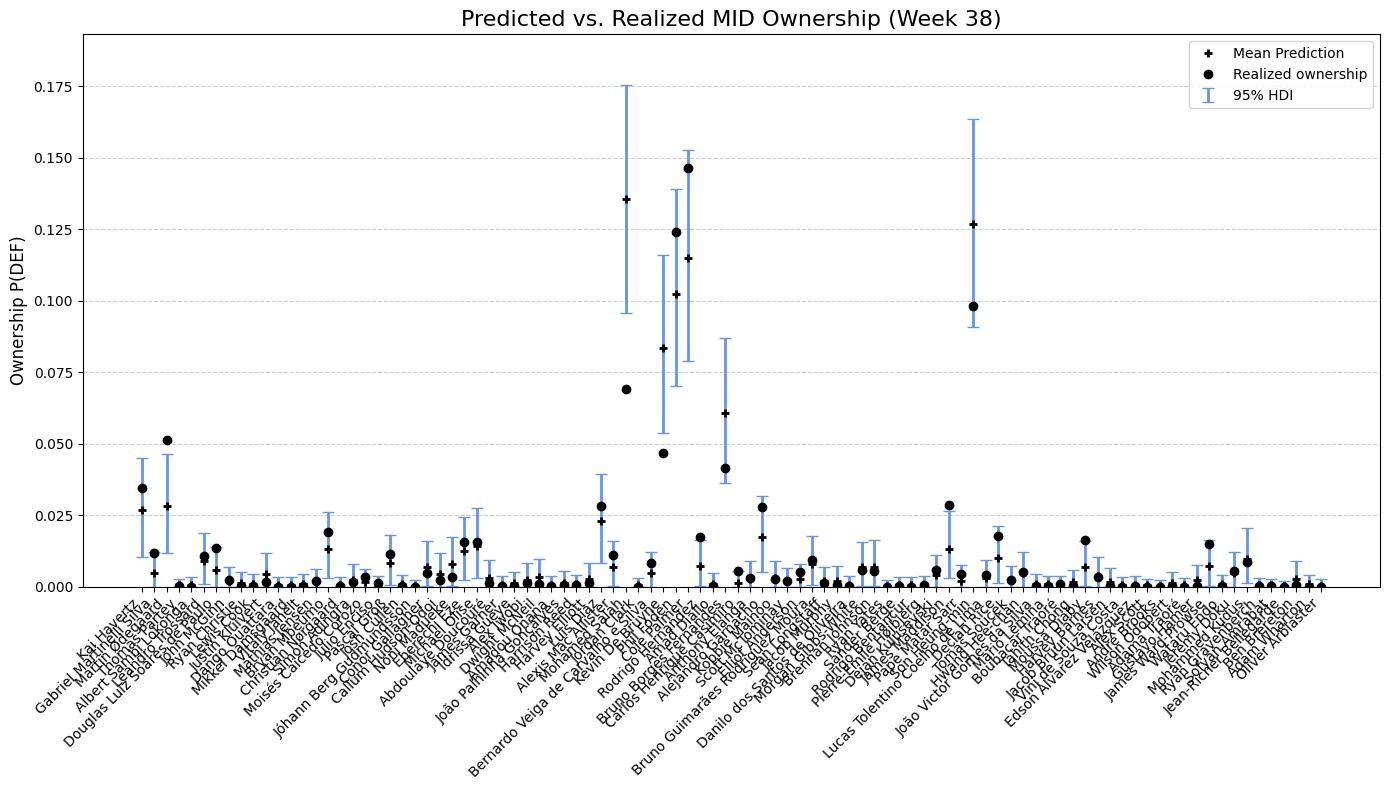

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_37.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_37,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_37,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_37,
    mid_probs_obs_37,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_37)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2541258746.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


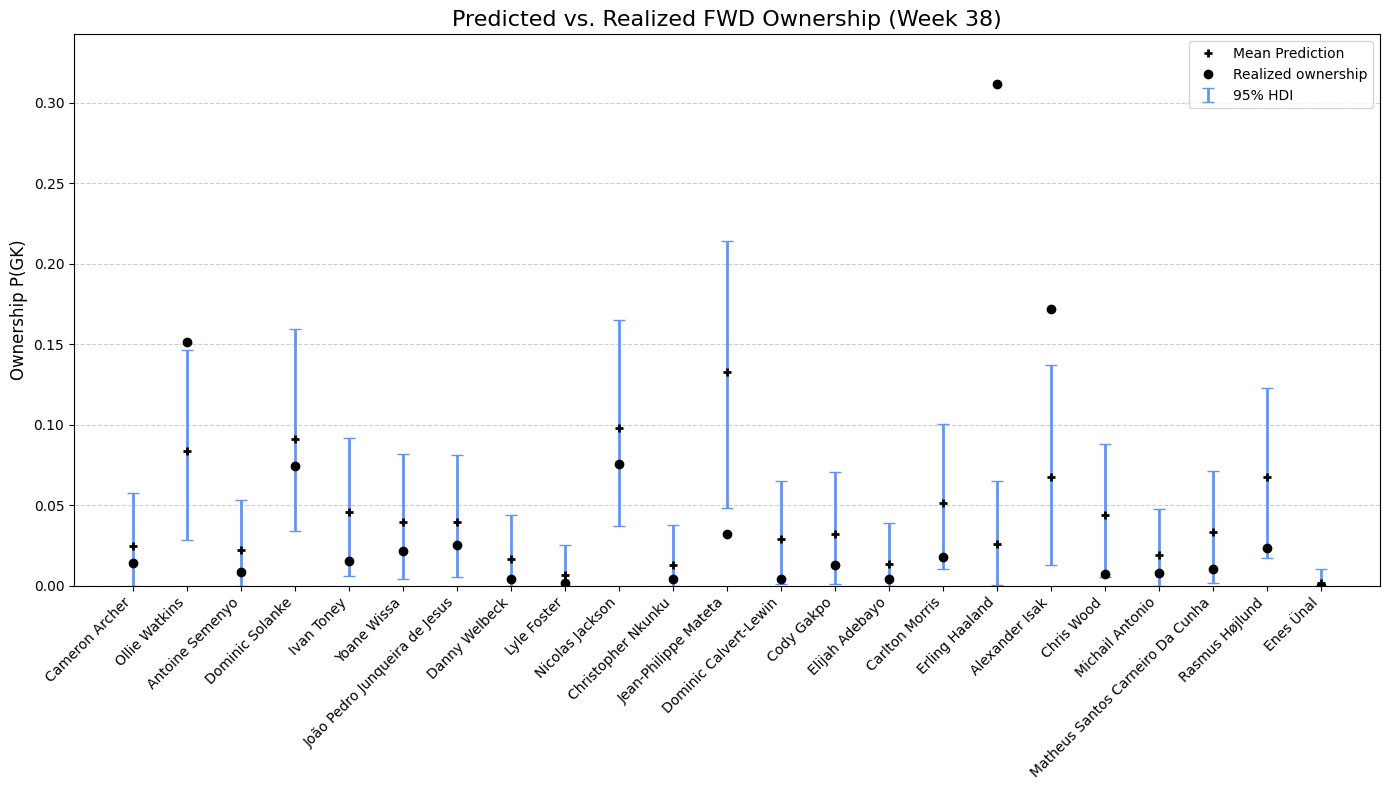

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_37.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_37,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_37,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_37,
    fwd_probs_obs_37,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_37)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios_37 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_37, X_def_37, X_mid_37, X_fwd_37],
    ids = ids_37,
    costs=players_preds_37['value'].tolist(),
    budget=84,
    teams=teams_37,
    xp_preds=xPts_37,
    p_vectors=p_vectors_37
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 20000 attempts...: 8
✅ Collected 0 valid teams after 30000 attempts...: 20
✅ Collected 0 valid teams after 40000 attempts...: 24
✅ Collected 0 valid teams after 50000 attempts...: 28
✅ Collected 0 valid teams after 60000 attempts...: 36
✅ Collected 0 valid teams after 70000 attempts...: 43
✅ Collected 0 valid teams after 80000 attempts...: 48
✅ Collected 0 valid teams after 90000 attempts...: 52
✅ Collected 0 valid teams after 100000 attempts...: 61
✅ Collected 0 valid teams after 110000 attempts...: 70
✅ Collected 0 valid teams after 120000 attempts...: 75
✅ Collected 0 valid teams after 130000 attempts...: 79
✅ Collected 0 valid teams after 140000 attempts...: 86
✅ Collected 0 valid teams after 150000 attempts...: 92
✅ Collected 0 valid teams after 160000 attempts...: 105
✅ Collected 0 valid teams after 170000 attempts..

In [ ]:
Wo_37 = []
for i in generated_portfolios_37:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_37['fpl_id'].index.tolist()])
    Wo_37.append(squad)

len(Wo_37)


500

In [ ]:

delta_sample_trace_37 = monte_carlo_simulation(Wo_37, mu_delta_37, cov_mat_37, sigma_delta_37)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_37 = az.summary(delta_sample_trace_37, var_names=["delta"], round_to=2)
summary_37


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_37 = delta_sample_trace_37.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_37, n_draws_37, n_players_37 = delta_raw_37.shape
delta_flattened_37 = delta_raw_37.reshape(n_chains_37 * n_draws_37, n_players_37)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_37 = np.dot(Wo_37, delta_flattened_37.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_37 = np.percentile(opponent_performances_37, 90, axis=0)

delta_samples_37 = delta_sample_trace_37.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_37 = np.percentile(Gr_samples_37, 90)  # shape (N_samples,)

mu_delta_37, cov_delta_37, mu_G_37, var_G_37, cov_delta_G_37, sigma_G_37 = generate_cov_delta(delta_flattened_37, Gr_samples_37)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_37, best_w_37, best_prob_37 = optimize_portfolio(add_fantasy_constraints, ids_37, prices_37, mu_delta_37, cov_delta_37, mu_G_37, var_G_37, cov_delta_G_37, lambdas, delta_samples_37, Gr_scalar_37, players_preds_37, 84)
print(f"Best λ: {best_lambda_37}, Best Probability of Outperforming: {best_prob_37}")

selected_37, player_names_37, total_points_37, team_cost_37, formation_37 = selected_info(best_w_37, fpl_teams_ids, players_preds_37, fg_managers_37)
print('fpl_ids: ', selected_37, '\nfpl_names: ', player_names_37, '\ntotal_points: ', total_points_37, '\nteam_cost: ', team_cost_37, '\nformation: ', formation_37)

players_preds_37[players_preds_37['fpl_id'].isin(selected_37)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_37[players_preds_37['fpl_id'].isin(selected_37)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_37 = players_preds_37[players_preds_37['fpl_id'].isin(selected_37)].copy()
# players_selected_37 = players_selected_37.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_37['xp_rank'] = players_selected_37['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_37['xp_rank'] == 1,  # Highest xp_preds
    players_selected_37['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_37['score'] = players_selected_37['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_37 = sum(players_selected_37['score'].values)
print(total_points_37, players_selected_37['xP'].values, '--------->', players_selected_37['xP_pred'].values)

players_selected_37[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_37 = fg_managers[fg_managers['gameweek'] == 37]
fg_managers_37[['points']]

position_37 = (fg_managers_37['points'] > total_points_37).sum() + 1

# 4. Display result
total_managers_37 = len(fg_managers_37)
percentile_37 = percentile_34 = 100 * (1 - (position_37 - 1) / total_managers_37)

print(total_points_37, total_managers_37)

print(f"Your predicted player’s total of {total_points_37} points would rank:")
print(f"→ Position: {position_37} out of {total_managers_37} managers")
print(f"→ Percentile: Top {percentile_37:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_37 = fg_managers_37.sort_values('points', ascending=False).reset_index(drop=True)

nearby_37 = fg_sorted_37.iloc[max(position_37-15, 0):position_37+2][['points','prize']]

player_prize_37 = fg_sorted_37.iloc[position_37 - 1]['prize']
if pd.isna(player_prize_37):
    player_prize_37 = "No prize"

print(f"→ Prize at position {position_37}: {player_prize_37}")
print("\nClosest scores around you:")
print(nearby_37)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# GW 38


## Generate Cov_Mat


In [ ]:
fg_managers_38  = fg_managers[fg_managers['gameweek'] == 38]
data_23_24_38 = data_23_24[data_23_24['event'] < 38]
players_preds_38 =  data_23_24[data_23_24['event'] == 38]

mu_delta_38, sigma_delta_38, cov_mat_38, valid_player_ids_38 = generate_cov_mat(players_preds_38, data_23_24_38)


Starting to optimize team selection...
(209, 343)
(4213, 343)
(208,) (208,) (208, 208)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_38 = data_23_24_38[data_23_24_38['fpl_id'].isin(valid_player_ids_38)].reset_index(drop=True)
players_preds_38 = players_preds_38[players_preds_38['fpl_id'].isin(valid_player_ids_38)].reset_index(drop=True)
data_38, prices_38, xPts_38, positions_38, teams_38, ids_38, X_38, names_38, probs_38 = clean_data(players_preds_38, valid_player_ids_38)

starting to clean data...
data successfully cleaned...


In [ ]:
X_gk_38 = X_38[0][gk_beta_feats]
X_def_38 = X_38[1][def_beta_feats]
X_mid_38 = X_38[2][mid_beta_feats]
X_fwd_38 = X_38[3][fwd_beta_feats]

alphas_38 = {
        'GK': np.exp(X_gk_38 @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def_38 @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid_38 @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd_38 @ beta_fwd.T).mean(axis=1)
    }


p_vectors_38 = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas_38.items()}
p_vectors_38

{'GK': array([3.00208814e-02, 1.71939192e-01, 1.47058888e-05, 4.49238970e-01,
        3.26388875e-02, 2.10036576e-02, 1.09154367e-02, 3.01933277e-05,
        4.95578661e-14, 4.47398750e-02, 1.32397065e-01, 2.97637833e-05,
        6.49419689e-02, 1.31584225e-02, 2.83320948e-02, 5.98886065e-04]),
 'DEF': array([6.10437172e-02, 7.64903911e-02, 1.39219511e-02, 3.59394528e-03,
        9.07004761e-02, 8.08537646e-03, 5.91840244e-03, 7.27384624e-03,
        2.84847143e-03, 2.05138433e-03, 9.17303679e-03, 4.31166381e-04,
        7.35357179e-04, 1.12682052e-03, 4.38067750e-03, 3.08336115e-03,
        8.66477430e-03, 8.36724800e-03, 3.24672027e-02, 1.61723217e-02,
        4.08608582e-03, 9.33648567e-03, 2.29900132e-03, 3.35373666e-03,
        1.55686153e-02, 1.24428333e-02, 1.84022654e-03, 1.52225704e-03,
        1.35479286e-02, 1.27234778e-02, 3.35554438e-02, 3.50961609e-02,
        2.10929816e-02, 5.86194001e-03, 2.10834973e-04, 1.04134992e-02,
        9.33073945e-03, 1.25604889e-02, 2.8527235

## Plots


In [ ]:
gk_names_38 = names_38[0]
def_names_38 = names_38[1]
mid_names_38 = names_38[2]
fwd_names_38 = names_38[3]

gk_probs_obs_38 = probs_38[0]
def_probs_obs_38 = probs_38[1]
mid_probs_obs_38 = probs_38[2]
fwd_probs_obs_38 = probs_38[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2517278040.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


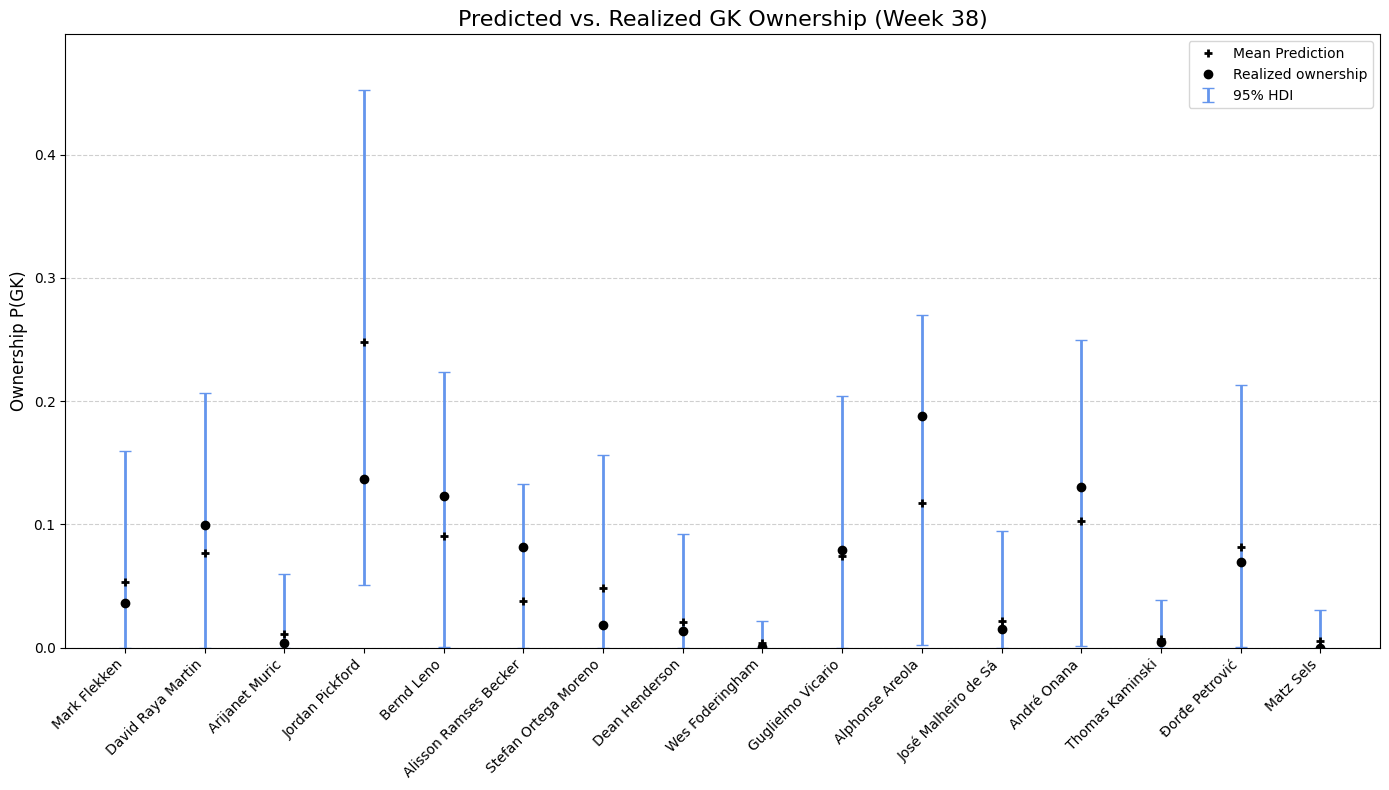

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk_38.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names_38,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names_38,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names_38,
    gk_probs_obs_38,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs_38)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/521612348.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


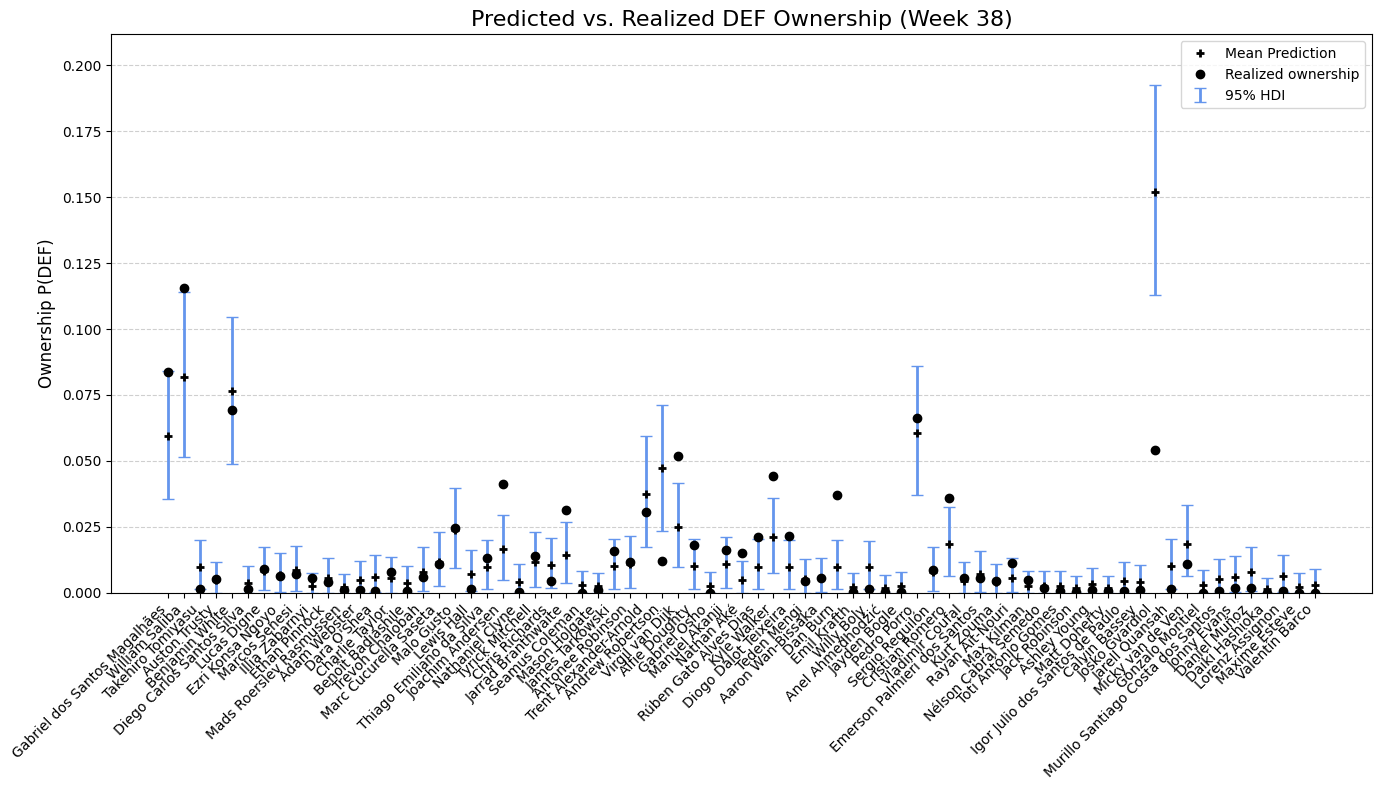

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def_38.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names_38,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names_38,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names_38,
    def_probs_obs_38,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs_38)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/3999001716.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


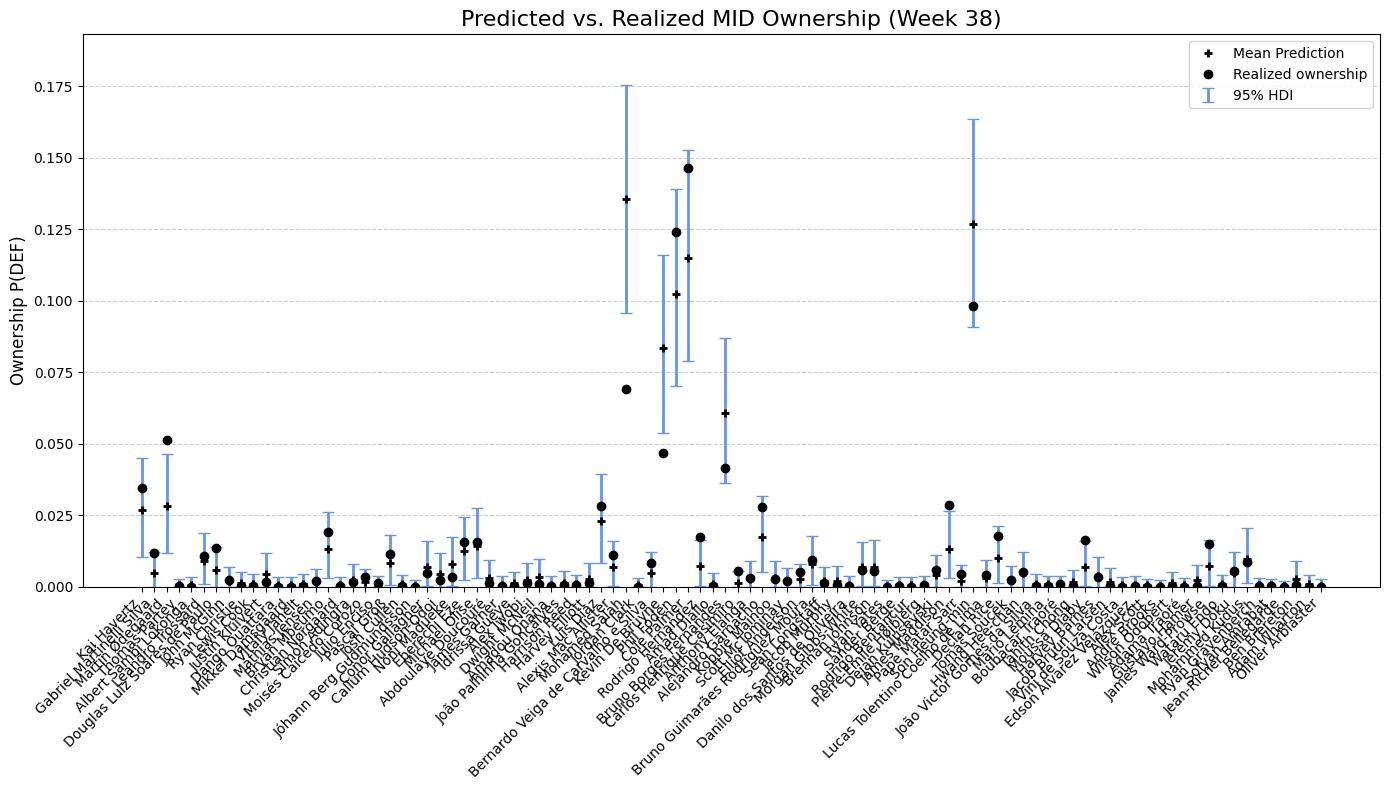

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid_38.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names_38,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names_38,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names_38,
    mid_probs_obs_38,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs_38)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_2558/2541258746.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


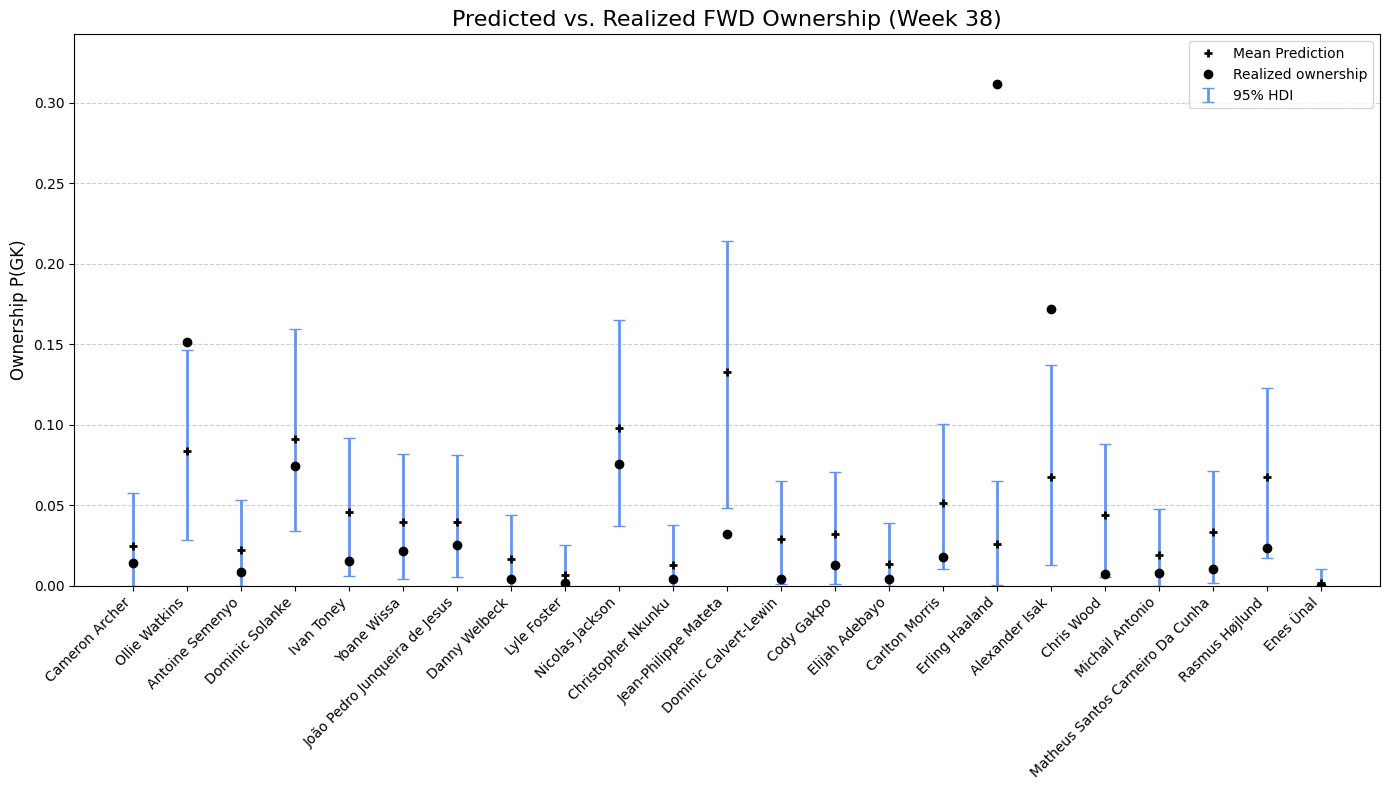

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd_38.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names_38,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names_38,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names_38,
    fwd_probs_obs_38,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(fwd_probs_obs_38)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios_38 = sample_opponent_portfolios(
    O=500,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices =  [X_gk_38, X_def_38, X_mid_38, X_fwd_38],
    ids = ids_38,
    costs=players_preds_38['value'].tolist(),
    budget=84,
    teams=teams_38,
    xp_preds=xPts_38,
    p_vectors=p_vectors_38
    )


Generating 500 opponent portfolios...
⚙️ Using 4 cores to generate 500 teams...
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 20000 attempts...: 8
✅ Collected 0 valid teams after 30000 attempts...: 20
✅ Collected 0 valid teams after 40000 attempts...: 24
✅ Collected 0 valid teams after 50000 attempts...: 28
✅ Collected 0 valid teams after 60000 attempts...: 36
✅ Collected 0 valid teams after 70000 attempts...: 43
✅ Collected 0 valid teams after 80000 attempts...: 48
✅ Collected 0 valid teams after 90000 attempts...: 52
✅ Collected 0 valid teams after 100000 attempts...: 61
✅ Collected 0 valid teams after 110000 attempts...: 70
✅ Collected 0 valid teams after 120000 attempts...: 75
✅ Collected 0 valid teams after 130000 attempts...: 79
✅ Collected 0 valid teams after 140000 attempts...: 86
✅ Collected 0 valid teams after 150000 attempts...: 92
✅ Collected 0 valid teams after 160000 attempts...: 105
✅ Collected 0 valid teams after 170000 attempts..

In [ ]:
Wo_38 = []
for i in generated_portfolios_38:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds_38['fpl_id'].index.tolist()])
    Wo_38.append(squad)

len(Wo_38)


500

In [ ]:

delta_sample_trace_38 = monte_carlo_simulation(Wo_38, mu_delta_38, cov_mat_38, sigma_delta_38)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary_38 = az.summary(delta_sample_trace_38, var_names=["delta"], round_to=2)
summary_38


⚙️ Running ADVI optimization...


Output()

Finished [100%]: Average Loss = 36,001


🎲 Drawing 2000 samples from the posterior approximation...


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.54,0.02,4.50,4.58,0.0,0.0,1842.05,1719.93,NaN
delta[1],4.58,0.02,4.54,4.62,0.0,0.0,1882.67,1852.60,NaN
delta[2],2.93,0.02,2.89,2.96,0.0,0.0,2067.25,1847.63,NaN
delta[3],4.90,0.02,4.86,4.94,0.0,0.0,2152.03,2045.19,NaN
delta[4],0.37,0.02,0.34,0.40,0.0,0.0,1921.93,1848.25,NaN
...,...,...,...,...,...,...,...,...,...
delta[203],0.21,0.02,0.18,0.24,0.0,0.0,1890.07,1967.33,NaN
delta[204],1.13,0.02,1.10,1.16,0.0,0.0,2026.85,2027.86,NaN
delta[205],0.83,0.02,0.80,0.86,0.0,0.0,1987.58,1921.86,NaN
delta[206],0.02,0.02,-0.01,0.06,0.0,0.0,2177.98,1818.49,NaN


In [ ]:
delta_raw_38 = delta_sample_trace_38.posterior['delta'].values

# 2. Reshape to (total_samples, players)
# total_samples = chains * draws
n_chains_38, n_draws_38, n_players_38 = delta_raw_38.shape
delta_flattened_38 = delta_raw_38.reshape(n_chains_38 * n_draws_38, n_players_38)

# 3. Perform the dot product
# Wo_ shape: (opponents, players)
# delta_flattened.T shape: (players, total_samples)
# Result shape: (opponents, total_samples)
opponent_performances_38 = np.dot(Wo_38, delta_flattened_38.T)

# 4. Calculate the 90th percentile threshold (G_r) for each universe sample
# axis=0 because we want the percentile across the 'opponents' for each universe
Gr_samples_38 = np.percentile(opponent_performances_38, 90, axis=0)

delta_samples_38 = delta_sample_trace_38.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
Gr_scalar_38 = np.percentile(Gr_samples_38, 90)  # shape (N_samples,)

mu_delta_38, cov_delta_38, mu_G_38, var_G_38, cov_delta_G_38, sigma_G_38 = generate_cov_delta(delta_flattened_38, Gr_samples_38)

(2000, 208) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda_38, best_w_38, best_prob_38 = optimize_portfolio(add_fantasy_constraints, ids_38, prices_38, mu_delta_38, cov_delta_38, mu_G_38, var_G_38, cov_delta_G_38, lambdas, delta_samples_38, Gr_scalar_38, players_preds_38, 84)
print(f"Best λ: {best_lambda_38}, Best Probability of Outperforming: {best_prob_38}")

selected_38, player_names_38, total_points_38, team_cost_38, formation_38 = selected_info(best_w_38, fpl_teams_ids, players_preds_38, fg_managers_38)
print('fpl_ids: ', selected_38, '\nfpl_names: ', player_names_38, '\ntotal_points: ', total_points_38, '\nteam_cost: ', team_cost_38, '\nformation: ', formation_38)

players_preds_38[players_preds_38['fpl_id'].isin(selected_38)][['Understat_Name', 'position', 'team', 'xP_pred', 'total_points']]

DEBUG: Found players - GK: 16, DEF: 73, MID: 96, FWD: 23
Checking feasibility...
['Arsenal', 'Arsenal', 'Arsenal', 'Aston Villa', 'Bournemouth', 'Everton', 'Liverpool', 'Manchester City', 'Manchester City', 'Manchester City', 'Tottenham Hotspur']
Best λ: 0.0, Best Probability of Outperforming: 1.0
Team cost: 82.5  :  [ 5.4  5.9  6.1  5.4  8.9  6.9  4.8  8.5 14.3  6.3 10. ]
[ 1.  2.  2.  1.  2.  1.  1. 15.  4.  9.  7.] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]
Your predicted player’s total of 45.0 points would rank:
→ Position: 236 out of 256 managers
→ Percentile: Top 7.81%

Closest scores around you:
   points prize
0    45.5   NaN
1    45.5   NaN
2    45.0   NaN
3    45.0   NaN
4    45.0   NaN
fpl_ids:  [5, 20, 29, 43, 60, 85, 263, 353, 355, 362, 516] 
fpl_names:  ['Gabriel dos Santos Magalhães', 'William Saliba', 'Benjamin White', 'Douglas Luiz Soares de Paulo', 'Ollie Watkins', 'Dominic Sol

,Understat_Name,position,team,xP_pred,total_points
0,Gabriel,DEF,Arsenal,5.287032,1.0
5,William Saliba,DEF,Arsenal,6.048938,2.0
10,Ben White,DEF,Arsenal,4.407086,2.0
14,Douglas Luiz,MID,Aston Villa,1.486535,1.0
17,Ollie Watkins,FWD,Aston Villa,3.287400,2.0
24,Dominic Solanke,FWD,Bournemouth,2.830506,1.0
78,Jordan Pickford,GK,Everton,3.740696,1.0
103,Phil Foden,MID,Manchester City,6.649853,15.0
104,Erling Haaland,FWD,Manchester City,8.879740,2.0
106,Cole Palmer,MID,Manchester City,7.614401,6.0


In [ ]:
players_preds_38[players_preds_38['fpl_id'].isin(selected_38)][['Understat_Name', 'position', 'value', 'team', 'total_points']]

,Understat_Name,position,value,team,total_points
3,Bukayo Saka,MID,8.9,Arsenal,2.0
4,William Saliba,DEF,5.9,Arsenal,9.0
8,Ben White,DEF,6.1,Arsenal,6.0
16,Ollie Watkins,FWD,8.9,Aston Villa,5.0
75,Jordan Pickford,GK,4.8,Everton,8.0
82,Trent Alexander-Arnold,DEF,8.4,Liverpool,1.0
84,Luis Díaz,MID,7.6,Liverpool,2.0
94,Julián Álvarez,FWD,6.4,Manchester City,5.0
96,Phil Foden,MID,8.5,Manchester City,9.0
99,Cole Palmer,MID,6.3,Manchester City,8.0


In [ ]:
# Get total points
players_selected_38 = players_preds_38[players_preds_38['fpl_id'].isin(selected_38)].copy()
# players_selected_38 = players_selected_38.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_38['xp_rank'] = players_selected_38['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_38['xp_rank'] == 1,  # Highest xp_preds
    players_selected_38['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_38['score'] = players_selected_38['xP'] * np.select(conditions, multipliers, default=1.0)
total_points_38 = sum(players_selected_38['score'].values)
print(total_points_38, players_selected_38['xP'].values, '--------->', players_selected_38['xP_pred'].values)

players_selected_38[[ 'team', 'position', 'xP_pred', 'xP', 'xp_rank', 'score']]

67.6 [5.  5.5 4.8 2.  3.3 2.8 4.5 8.8 8.2 6.  5.5] ---------> [5.28703211 6.04893769 4.40708551 1.48653526 3.28740016 2.83050593
 3.74069594 6.64985322 8.87973953 7.61440073 4.41558622]


,team,position,xP_pred,xP,xp_rank,score
0,Arsenal,DEF,5.287032,5.0,5,5.0
5,Arsenal,DEF,6.048938,5.5,4,5.5
10,Arsenal,DEF,4.407086,4.8,7,4.8
14,Aston Villa,MID,1.486535,2.0,11,2.0
17,Aston Villa,FWD,3.287400,3.3,9,3.3
24,Bournemouth,FWD,2.830506,2.8,10,2.8
78,Everton,GK,3.740696,4.5,8,4.5
103,Manchester City,MID,6.649853,8.8,3,8.8
104,Manchester City,FWD,8.879740,8.2,1,16.4
106,Manchester City,MID,7.614401,6.0,2,9.0


In [ ]:
fg_managers_38 = fg_managers[fg_managers['gameweek'] == 38]
fg_managers_38[['points']]

position_38 = (fg_managers_38['points'] > total_points_38).sum() + 1

# 4. Display result
total_managers_38 = len(fg_managers_38)
percentile_38 = percentile_34 = 100 * (1 - (position_38 - 1) / total_managers_38)

print(total_points_38, total_managers_38)

print(f"Your predicted player’s total of {total_points_38} points would rank:")
print(f"→ Position: {position_38} out of {total_managers_38} managers")
print(f"→ Percentile: Top {percentile_38:.2f}%")


# Optional: show nearby ranks for context
fg_sorted_38 = fg_managers_38.sort_values('points', ascending=False).reset_index(drop=True)

nearby_38 = fg_sorted_38.iloc[max(position_38-15, 0):position_38+2][['points','prize']]

player_prize_38 = fg_sorted_38.iloc[position_38 - 1]['prize']
if pd.isna(player_prize_38):
    player_prize_38 = "No prize"

print(f"→ Prize at position {position_38}: {player_prize_38}")
print("\nClosest scores around you:")
print(nearby_38)

67.6 256
Your predicted player’s total of 67.6 points would rank:
→ Position: 134 out of 256 managers
→ Percentile: Top 48.05%
→ Prize at position 134: No prize

Closest scores around you:
     points prize
119    70.0   NaN
120    70.0   NaN
121    70.0   NaN
122    70.0   NaN
123    69.5   NaN
124    69.0   NaN
125    69.0   NaN
126    69.0   NaN
127    68.5   NaN
128    68.5   NaN
129    68.5   NaN
130    68.0   NaN
131    68.0   NaN
132    68.0   NaN
133    67.5   NaN
134    67.5   NaN
135    67.0   NaN


# Results


In [ ]:
gameweeks = range(32, 39)

results = {
    'gameweek': list(gameweeks),
    'score': [globals()[f'total_points_{gw}'] for gw in gameweeks],
    'position': [globals()[f'position_{gw}'] for gw in gameweeks],
    'total_managers': [globals()[f'total_managers_{gw}'] for gw in gameweeks],
    'percentile': [globals()[f'percentile_{gw}'] for gw in gameweeks],
    'prize': [globals()[f'player_prize_{gw}'] for gw in gameweeks],
    'players': [globals().get(f'players_selected_{gw}', pd.DataFrame(columns=['name']))['name'].tolist() for gw in gameweeks]
}
pd.DataFrame(results)


,gameweek,score,position,total_managers,percentile,prize,players
0,31,94.05,1,217,100.000000,"R 3,890.25","[William Saliba, Benjamin White, Ezri Konsa Ng..."
1,32,86.25,8,234,97.008547,R 99.75,"[Martin Ødegaard, William Saliba, Benjamin Whi..."
2,33,88.95,22,246,91.463415,R 21.95,"[Kai Havertz, Benjamin White, David Raya Marti..."
3,34,111.40,108,203,87.500000,No prize,"[William Saliba, Benjamin White, Emiliano Mart..."
4,35,110.85,2,207,99.516908,"R 1,695.75","[Kai Havertz, Martin Ødegaard, Benjamin White,..."
5,36,101.30,39,229,83.406114,R 22.39,"[Kai Havertz, Bukayo Saka, Benjamin White, Oll..."
6,37,138.45,2,243,99.588477,"R 1,695.75","[Kai Havertz, Bukayo Saka, Nicolas Jackson, Ty..."
7,38,87.80,33,256,87.500000,R 20.32,"[Kai Havertz, Leandro Trossard, David Raya Mar..."
